# 🧠 **TechMind – Organización Inteligente del Conocimiento Técnico**

###**Descripción del proyecto**: https://talent.nocountry.tech/project

**Equipo G9-LATAM-Team 04-DataScientist**
- Alan Arce - Data Scientist (trendsinbiomedicine.arcealan@gmail.com)
- Liuber Escalona - Data Scientist (liuberth33@gmail.com)
- Jaime Pradenas - BI Analys (jpraden@gmail.com)

__________________________________________________
###**Resultados esperados**
**Notebook del equipo de Ciencia de Datos (Jupyter/Colab):**

● Exploración y limpieza de datos (EDA);

● Tratamiento de textos;

● Transformación de datos al formato adecuado para modelado;

● Entrenamiento y evaluación de modelos;

● Métricas de desempeño apropiadas para la solución propuesta;

● Serialización del modelo (joblib/pickle).



**TAREA TRELLO: SPRINT-S1_DS-01: Crear dataset de contenido técnico**

https://trello.com/c/vRAykzCf/51-sprint-s1ds-01-crear-dataset-de-contenido-t%C3%A9cnico


**IMPORTANTE:** Accerder a tarea en 'Trello', debe tener cuenta de usuario en 'Trelo', ya que el repositorio es (publico).

Por otra parte, almacenar archivos resultantes en su **Ruta DRIVE**, ya que al dejarlo en /content/sample_data/ como está en el Notebook, al desconectarse se elimina automáticamente.

________________________________________________________________

#####**RECOLECCION DE DATOS (NoSintacticos) - DATASET INICIAL (Origen Dev.to)**

 Dev.to es una comunidad gigante de desarrolladores. Su API es gratuita y no requiere autenticación compleja para lecturas básicas. Provee una API pública oficial estructurada para desarrolladores url = f"https://dev.to/api/articles?tag={tag}&per_page={PER_PAGE}&page={page}"

Se RECOPILARON DATOS desde la fuente publica exportando en archivo '**dataset_inicial_devto_hackaton_eng.csv**' delimitado por ';'
_______________________________________

**Usa GPU, si esta disponible (Runtime > Change runtime type >
GPU en Colab)** para acelerar el proceso. Cambiar entorno ejecución a **GPU**

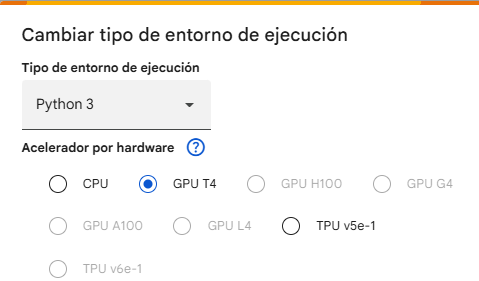


De no tener habilitado GPU, corre en CPU (mas lento, pero funciona igual).

*(Reemplaza los intentos anteriores con `deep_translator.GoogleTranslator`, que fallaban con "too many requests"
al saturar el endpoint no oficial de Google Translate con miles de articulos.)*






In [ ]:
#Disponibiliza drive personal
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


### Evaluando amplificar y mejorar RECOLECCION del DATASET REENTRENAMIENTO CON DATOS NUEVOS 02.08.2026

In [1]:
#**RECOLECCION DE DATOS (NoSintacticos) - DATASET INICIAL (Origen Dev.to) // Amplificada

import requests
import pandas as pd
import numpy as np # Importar numpy para consistencia

# Categorias: se importan desde el modulo compartido del repo (shared/categorias.py),
# una sola fuente de verdad -- incluye la ampliacion de tags de Data Engineering
# del reentrenamiento del 02.08.2026. Agregar una categoria nueva es agregar una
# linea ahi, no hace falta tocar este notebook.
!curl -sL -o shared_categorias.py "https://raw.githubusercontent.com/No-Country-simulation/g9-latam-team-04-esp/develop/shared/categorias.py"
from shared_categorias import CATEGORIAS as tags_map

# Definir palabras clave irrelevantes (en minúsculas para una comparación sin distinción entre mayúsculas y minúsculas)
irrelevant_keywords = [
    # --- lista original ---
    'meme',
    'opinion',
    'promotional',
    'news',
    'update',
    'guide to',
    #'tutorial',
    'how to',
    'free',
    'event',
    'webinar',
    'review',
    'announcement',
    'product',
    #'tool',
    'offer',
    'win',
    'giveaway',
    'newsletter',
    'subscribe',

    # --- spam de academias/cursos de capacitacion (visto en los propios datos: DevOps Training) ---
    'training institute',
    'training in',
    'bootcamp',
    'certification course',
    'coaching center',
    'gateway to success',
    'career journey',
    'unlock your potential',
    'insider insights',
    'success story',
    'complete guide 20',   # atrapa "complete guide 2024/2025/2026..."
    'your gateway',
    'revolutionize your',
    'reinvent your',
    'navigate your success',
    'ignite your career',
    'empower your career',

    # --- reclutamiento / empleo, no contenido tecnico ---
    'we are hiring',
    'hiring now',
    'job alert',
    'apply now',
    'job opening',

    # --- clickbait / listicle generico ---
    'top 10',
    'top 5',
    "you won't believe",
    'shocking',
    'must know',
    'best of 20',

    # --- engagement bait / redes sociales ---
    'like and share',
    'follow me',
    'comment below',
    'link in bio',
    'dm me',

    # --- posts meta/no tecnicos ---
    'happy birthday',
    'merry christmas',
    'welcome to my blog',
    'about me',
    'introduction post',
    'thank you for reading',

    # --- marketing/ventas ---
    'sponsored',
    'affiliate',
    'discount code',
    'coupon',
    'limited time',
    'buy now',
]

# Establecer una longitud mínima para el texto del artículo
MIN_TEXT_LENGTH = 50  # Por ejemplo, 50 caracteres

# Función para verificar si un artículo contiene palabras clave irrelevantes
def contains_irrelevant_keyword(title, text, keywords):
    title_lower = title.lower() if title else ''
    text_lower = text.lower() if text else ''
    for keyword in keywords:
        if keyword in title_lower or keyword in text_lower:
            return True
    return False

# Usa un diccionario para almacenar los artículos únicos recopilados por cada categoría
all_collected_articles_per_category = {cat: [] for cat in tags_map.keys()}
MAX_ARTICLES_PER_CATEGORY = 6000
PER_PAGE = 300 # Articles per page

for categoria, tags_for_category in tags_map.items():
    current_category_unique_articles = []
    # Para comprobar la unicidad de forma más eficiente dentro de la colección de categorías
    seen_article_identifiers_in_category = set()

    # Asegurar que tags_for_category sea siempre una lista para iterar
    if not isinstance(tags_for_category, list):
        tags_for_category = [tags_for_category]

    print(f"Collecting unique articles for category: {categoria} with tags: {tags_for_category}...")

    for tag in tags_for_category:
        page = 1
        print(f"  Fetching articles for tag: {tag}...")
        while len(current_category_unique_articles) < MAX_ARTICLES_PER_CATEGORY:
            url = f"https://dev.to/api/articles?tag={tag}&per_page={PER_PAGE}&page={page}"
            response = requests.get(url)

            if response.status_code == 200:
                data = response.json()
                if not data: # No hay más artículos disponibles en esta página/etiqueta
                    print(f"  No more articles found for tag '{tag}' after page {page-1}.")
                    break

                newly_added_count_this_page = 0
                for item in data:
                    title = item.get("title")
                    text = item.get("description")
                    article_url = item.get("url") # Extraemos la URL del artículo

                    # Create a unique identifier for the article to check against 'seen_article_identifiers_in_category'
                    article_identifier = (title, text)

                    if article_identifier not in seen_article_identifiers_in_category:
                        if len(current_category_unique_articles) < MAX_ARTICLES_PER_CATEGORY:
                            # Calcular la relevancia aquí
                            is_irrelevant_by_keyword = contains_irrelevant_keyword(title, text, irrelevant_keywords)
                            is_too_short = (len(text) < MIN_TEXT_LENGTH) if text else True # Si el texto es None, considerarlo demasiado corto

                            es_relevante = not (is_irrelevant_by_keyword or is_too_short)

                            current_category_unique_articles.append({
                                "titulo": title,
                                "texto": text,
                                "categoria": categoria,
                                "url": article_url, # Incluimos la URL en los datos del artículo
                                "es_relevante": es_relevante # Añadir la nueva columna aquí
                            })
                            seen_article_identifiers_in_category.add(article_identifier)
                            newly_added_count_this_page += 1
                        else:
                            # Reached max unique articles for this category, break from inner loop
                            break

                if newly_added_count_this_page == 0 and len(data) > 0:
                    # If we processed a full page but added no new unique articles (e.g. all were duplicates from previous pages or within this page)
                    # This indicates we've likely exhausted unique articles for this category
                    print(f"  No new unique articles found for tag '{tag}' on page {page}. Stopping for this tag.")
                    break

                page += 1
            else:
                print(f"  Error al obtener artículos para el tag '{tag}' (page: {page}): {response.status_code}")
                break # Break out of page loop on error

    all_collected_articles_per_category[categoria] = current_category_unique_articles
    print(f"Finished collecting unique articles for {categoria}. Total collected for this category: {len(current_category_unique_articles)}")

# Consolidate all unique articles (unique within their category) into a single list
articulos_reales = []
for category_list in all_collected_articles_per_category.values():
    articulos_reales.extend(category_list)

print(f"Total articles collected (unique within their categories) across all categories: {len(articulos_reales)}")

  Fetching articles for tag: backend...
Finished collecting unique articles for Backend. Total collected for this category: 6000
  Fetching articles for tag: cloud...
Finished collecting unique articles for Cloud. Total collected for this category: 6000
  Fetching articles for tag: engineering...
  No more articles found for tag 'engineering' after page 7.
  Fetching articles for tag: pipeline...
  No more articles found for tag 'pipeline' after page 1.
  Fetching articles for tag: etl...
  No more articles found for tag 'etl' after page 2.
  Fetching articles for tag: python...
  Fetching articles for tag: bigdata...
  Fetching articles for tag: apachespark...
  Fetching articles for tag: snowflake...
  Fetching articles for tag: onpremise...
  Fetching articles for tag: airflow...
  Fetching articles for tag: kafka...
  Fetching articles for tag: dbt...
  Fetching articles for tag: warehouse...
  Fetching articles for tag: snowflake...
Finished collecting unique articles for Data Eng

In [2]:
df_real = pd.DataFrame(articulos_reales).drop_duplicates(subset=['titulo', 'texto', 'categoria'])
print(f"Total recolectado: {len(df_real)} artículos")


Total recolectado: 42000 artículos


In [3]:
display(df_real.head(10))

,titulo,texto,categoria,url,es_relevante
0,Solon Server Threads: Zero-Config Auto-Tuning ...,Solon Server Threads: Zero-Config Auto-Tuning ...,Backend,https://dev.to/solonjava/solon-server-threads-...,True
1,Why My Cache Has No TTL,"Last time, I wrote about the dilemma of feedin...",Backend,https://dev.to/shunya_shida/why-my-cache-has-n...,True
2,JWT Authentication: A Backend Engineer's Menta...,Introduction Imagine you arrive at a hotel. ...,Backend,https://dev.to/juma_evans_34e389ef539266/jwt-a...,True
3,Building Against Real APIs Is Nothing Like Rea...,"A few months ago, I started spending a lot mor...",Backend,https://dev.to/jan_inteldo/building-against-re...,True
4,Building Resilient Retry Logic in Node.js: Exp...,Every Node.js developer has written this at so...,Backend,https://dev.to/mukesh_13/building-resilient-re...,True
5,How DNS Works,Every device on the internet is identified by ...,Backend,https://dev.to/theemmanuel/how-dns-works-25j6,True
6,🤝 Looking for Backend Contributors,I built the frontend UI for a survey/reward pl...,Backend,https://dev.to/rakesh_chowdhury_1a4a5f2c/looki...,True
7,Attack Surface of Hand-Rolled Auth: Consolidat...,The exposure Our FastAPI service enforced au...,Backend,https://dev.to/gaberialsofie/attack-surface-of...,True
8,Postgres Advisory Locks for Distributed Cron: ...,The problem: your cron job runs twice (or five...,Backend,https://dev.to/mukesh_13/postgres-advisory-loc...,True
9,An Error Inside HTTP 200 Poisoned My Cache: Wh...,An upstream that reports rate limiting as HTTP...,Backend,https://dev.to/hexisteme/an-error-inside-http-...,True


In [4]:
print(df_real['es_relevante'].value_counts())

es_relevante
True     30641
False    11359
Name: count, dtype: int64


In [5]:
print('Distribución de "es_relevante" por "categoria":')
display(df_real.groupby('categoria')['es_relevante'].value_counts().unstack(fill_value=0))

Distribución de "es_relevante" por "categoria":


es_relevante,False,True
categoria,,
Backend,1617,4383
Cloud,1611,4389
Data Engineering,1838,4162
Data Science,1102,4898
Database,1755,4245
DevOps,1932,4068
Frontend,1504,4496


In [6]:
# Filtrar solo los artículos relevantes
df_relevantes = df_real[df_real['es_relevante'] == True]
print(df_relevantes['categoria'].value_counts())

categoria
Data Science        4898
Frontend            4496
Cloud               4389
Backend             4383
Database            4245
Data Engineering    4162
DevOps              4068
Name: count, dtype: int64


In [7]:
df_final_relevantes = pd.DataFrame(df_relevantes).drop_duplicates(subset=['titulo', 'texto', 'categoria'])
print(f"Total recolectado: {len(df_relevantes)} artículos")

Total recolectado: 30641 artículos


In [8]:
df_final_relevantes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30641 entries, 0 to 41998
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   titulo        30641 non-null  object
 1   texto         30641 non-null  object
 2   categoria     30641 non-null  object
 3   url           30641 non-null  object
 4   es_relevante  30641 non-null  bool  
dtypes: bool(1), object(4)
memory usage: 1.2+ MB


### Guardar el DataFrame Final con casos relevantes por categoria

Procederemos a guardar este DataFrame `df_final_relevantes` en un archivo CSV. Este archivo contendrá artículos RECOPILADOS, todos ellos marcados como relevantes según los criterios definidos, listos para su uso posterior.

______________________________________________


In [9]:
# ver estructura dataframe de df_final_relevantes
df_final_relevantes.columns


Index(['titulo', 'texto', 'categoria', 'url', 'es_relevante'], dtype='object')

In [10]:
dataset_final_devto = df_final_relevantes[['titulo', 'texto', 'categoria', 'url']]
display(dataset_final_devto.head())

,titulo,texto,categoria,url
0,Solon Server Threads: Zero-Config Auto-Tuning ...,Solon Server Threads: Zero-Config Auto-Tuning ...,Backend,https://dev.to/solonjava/solon-server-threads-...
1,Why My Cache Has No TTL,"Last time, I wrote about the dilemma of feedin...",Backend,https://dev.to/shunya_shida/why-my-cache-has-n...
2,JWT Authentication: A Backend Engineer's Menta...,Introduction Imagine you arrive at a hotel. ...,Backend,https://dev.to/juma_evans_34e389ef539266/jwt-a...
3,Building Against Real APIs Is Nothing Like Rea...,"A few months ago, I started spending a lot mor...",Backend,https://dev.to/jan_inteldo/building-against-re...
4,Building Resilient Retry Logic in Node.js: Exp...,Every Node.js developer has written this at so...,Backend,https://dev.to/mukesh_13/building-resilient-re...


##EXPORTANDO Archivo RECOLECCION DATOS origen Dev.to en:

 '/content/drive/MyDrive/Adataset_hackathon/dataset_inicial_devto_hackaton_eng.csv' y '/content/sample_data/dataset_inicial_devto_hackaton_eng.csv'

In [11]:
dataset_final_devto = pd.DataFrame(dataset_final_devto).drop_duplicates(subset=['titulo', 'texto', 'categoria'])
print(f"Total recolectado: {len(dataset_final_devto)} artículos")

Total recolectado: 30641 artículos


In [12]:
#Guardando En drive personal del proyecto (Desactivar si lo estima)
#dataset_final_devto.to_csv('/content/drive/MyDrive/Adataset_hackathon/dataset_inicial_devto_hackaton_eng.csv', sep = ';', index=False)
#print("DataFrame final guardado en drive file: 'dataset_inicial_devto_hackaton_eng'")


In [13]:
#Guardando archivo resultante en sample_data y data
dataset_final_devto.to_csv('/content/sample_data/dataset_inicial_devto_hackaton_eng.csv', sep = ';', index=False)
print("DataFrame final guardado en sample_data  'dataset_inicial_devto_hackaton_eng'")


DataFrame final guardado en sample_data  'dataset_inicial_devto_hackaton_eng'


#**Agregando titulos_esp, texto_esp - Traducidos al Español**

Traduccion con modelo local **Helsinki-NLP/opus-mt-en-es** (MarianMT, via `transformers`), corriendo offline sin
depender de una API externa con limite de peticiones.

**Usa GPU, si esta disponible (Runtime > Change runtime type >
GPU en Colab)** para acelerar el proceso. Cambiar entorno ejecución a **GPU**

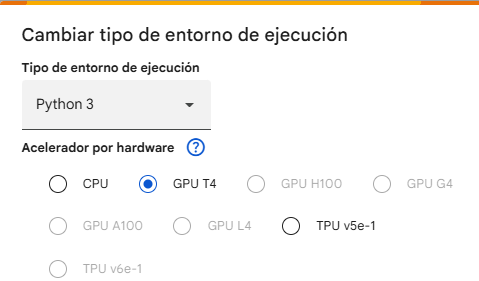


De no tener habilitado GPU, corre en CPU (mas lento, pero funciona igual).

*(Reemplaza los intentos anteriores con `deep_translator.GoogleTranslator`, que fallaban con "too many requests"
al saturar el endpoint no oficial de Google Translate con miles de articulos.)*

In [14]:
!pip install -q transformers sentencepiece

In [15]:
import os
import pandas as pd
import torch
from transformers import MarianMTModel, MarianTokenizer
from tqdm.auto import tqdm

# Cargar dataset base (generado en la seccion de RECOLECCION DE DATOS)
#ruta_entrada = "/content/drive/MyDrive/Adataset_hackathon/dataset_inicial_devto_hackaton_eng.csv"
ruta_entrada = "/content/sample_data/dataset_inicial_devto_hackaton_eng.csv"
df = pd.read_csv(ruta_entrada, sep=';')
print(f"Dataset cargado: {len(df)} articulos")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

model_name = "Helsinki-NLP/opus-mt-en-es"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name).to(device)


def traducir_es(textos, batch_size=64, max_length=512):
    """Traduce una lista de textos al espanol usando MarianMT, en lotes."""
    traducidos = []
    for i in tqdm(range(0, len(textos), batch_size), desc="Traduciendo"):
        lote = [str(t) if pd.notna(t) and str(t).strip() != "" else " " for t in textos[i:i + batch_size]]
        inputs = tokenizer(lote, return_tensors="pt", padding=True, truncation=True, max_length=max_length).to(device)
        with torch.no_grad():
            salida = model.generate(**inputs, max_length=max_length)
        traducidos.extend(tokenizer.batch_decode(salida, skip_special_tokens=True))
    return traducidos


print("Traduciendo titulos...")
df['titulo_esp'] = traducir_es(df['titulo'].tolist())

print("Traduciendo textos...")
df['texto_esp'] = traducir_es(df['texto'].tolist())

print("\nTraduccion completada. Ejemplo:")
display(df[['titulo', 'titulo_esp', 'texto', 'texto_esp']].head(3))

Dataset cargado: 30641 articulos
Usando dispositivo: cuda


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.59M [00:00<?, ?B/s]

...

Traduciendo:   0%|          | 0/479 [00:00<?, ?it/s]

Traduciendo textos...


Traduciendo:   0%|          | 0/479 [00:00<?, ?it/s]


Traduccion completada. Ejemplo:


,titulo,titulo_esp,texto,texto_esp
0,Solon Server Threads: Zero-Config Auto-Tuning ...,Solon Server Threads: Cero-Config Auto-Tuning ...,Solon Server Threads: Zero-Config Auto-Tuning ...,Solon Server Threads: Cero-Config Auto-Tuning ...
1,Why My Cache Has No TTL,Por qué mi caché no tiene TTL,"Last time, I wrote about the dilemma of feedin...","La última vez, escribí sobre el dilema de alim..."
2,JWT Authentication: A Backend Engineer's Menta...,Autenticación de JWT: Modelo mental de un inge...,Introduction Imagine you arrive at a hotel. ...,Introducción Imagínese que llega a un hotel. E...


## Guardar el dataset con las columnas traducidas

(Drive + sample_data, mismo formato que espera la celda de carga de la siguiente seccion)

In [16]:
# Guardar el dataset con las columnas traducidas (Drive + sample_data, mismo formato que
# espera la celda de carga de la siguiente seccion)
os.makedirs("/content/drive/MyDrive/Adataset_hackathon", exist_ok=True)
df.to_csv("/content/drive/MyDrive/Adataset_hackathon/dataset_inicial_devto_hackaton_eng_esp.csv", sep=';', index=False, encoding="utf-8-sig")
df.to_csv("/content/sample_data/dataset_inicial_devto_hackaton_eng_esp.csv", sep=';', index=False, encoding="utf-8-sig")
print("Archivo guardado en Drive y en sample_data: dataset_inicial_devto_hackaton_eng_esp.csv")

Archivo guardado en Drive y en sample_data: dataset_inicial_devto_hackaton_eng_esp.csv


##**Cargando el archivo Formato Extendido Ingles/Español**

In [17]:
# Cargar el dataset TRADUCIDO - Generado
import pandas as pd

#df = pd.read_csv("/content/drive/MyDrive/Adataset_hackathon/dataset_inicial_devto_hackaton_eng_esp.csv", sep=';')
df = pd.read_csv("/content/sample_data/dataset_inicial_devto_hackaton_eng_esp.csv", sep=';')
display(df.head())

,titulo,texto,categoria,url,titulo_esp,texto_esp
0,Solon Server Threads: Zero-Config Auto-Tuning ...,Solon Server Threads: Zero-Config Auto-Tuning ...,Backend,https://dev.to/solonjava/solon-server-threads-...,Solon Server Threads: Cero-Config Auto-Tuning ...,Solon Server Threads: Cero-Config Auto-Tuning ...
1,Why My Cache Has No TTL,"Last time, I wrote about the dilemma of feedin...",Backend,https://dev.to/shunya_shida/why-my-cache-has-n...,Por qué mi caché no tiene TTL,"La última vez, escribí sobre el dilema de alim..."
2,JWT Authentication: A Backend Engineer's Menta...,Introduction Imagine you arrive at a hotel. ...,Backend,https://dev.to/juma_evans_34e389ef539266/jwt-a...,Autenticación de JWT: Modelo mental de un inge...,Introducción Imagínese que llega a un hotel. E...
3,Building Against Real APIs Is Nothing Like Rea...,"A few months ago, I started spending a lot mor...",Backend,https://dev.to/jan_inteldo/building-against-re...,Construir contra las API reales no es nada com...,"Hace unos meses, empecé a pasar mucho más tiem..."
4,Building Resilient Retry Logic in Node.js: Exp...,Every Node.js developer has written this at so...,Backend,https://dev.to/mukesh_13/building-resilient-re...,Construcción de la lógica de reinicio resilien...,Cada desarrollador de Node.js ha escrito esto ...


In [18]:
dataset_final_devto_traducido = pd.DataFrame(df).drop_duplicates(subset=['titulo', 'texto', 'categoria'])
print(f"Total recolectado: {len(dataset_final_devto_traducido)} artículos")

Total recolectado: 30641 artículos


**Agregando palabras claves para 'keywords_titulo', 'keywords_texto' INGLES //, 'keywords_titulo_esp', 'keywords_texto_esp' ESPAÑOL**

In [19]:
#intalando recursos librerias requeridas
!pip install rake_nltk

In [ ]:
import nltk
from rake_nltk import Rake
import string

# Descargar punkt si no esta disponible (necesario para que Rake tokenice)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Inicializar Rake con las stopwords curadas del equipo (shared/stop_words.py:
# ~750 palabras EN / ~950 ES), en vez de las nativas de NLTK (~198 EN / ~313 ES).
# Se valido que mejora la calidad de las keywords extraidas (filtra mejor relleno
# generico como "know"/"use"/"sabe") -- ver comparacion en el resumen del equipo.
!curl -sL -o shared_stop_words.py "https://raw.githubusercontent.com/No-Country-simulation/g9-latam-team-04-esp/develop/shared/stop_words.py"
from shared_stop_words import STOP_WORDS_EN, STOP_WORDS_ES

stop_words_es = set(w.lower() for w in STOP_WORDS_ES)
stop_words_en = set(w.lower() for w in STOP_WORDS_EN)

# Custom punctuation to include '¿' and '’'
custom_punctuation = string.punctuation + "’¿¡"

def extract_keywords_from_text(text, lang='english'):
    if not isinstance(text, str) or text.strip() == "":
        return []

    # Convertir a minúsculas
    text = text.lower()
    # Eliminar signos de puntuación, incluyendo '¿' y '¡'
    text = text.translate(str.maketrans("", "",  custom_punctuation))

    # Usar las stopwords adecuadas según el idioma
    current_stopwords = stop_words_es if lang == 'spanish' else stop_words_en

    r = Rake(stopwords=current_stopwords)
    r.extract_keywords_from_text(text)

    ranked_phrases = r.get_ranked_phrases()

    # Prioridad 1: Palabras clave de una sola palabra con longitud >= 4
    keywords_p1 = [phrase for phrase in ranked_phrases if len(phrase.split()) == 1 and len(phrase) >= 4]
    if keywords_p1:
        return keywords_p1

    # Prioridad 2: Frases de dos palabras con longitud >= 4
    keywords_p2 = [phrase for phrase in ranked_phrases if len(phrase.split()) == 2 and len(phrase) >= 4]
    if keywords_p2:
        return keywords_p2

    # Prioridad 3: Palabras clave de una sola palabra con longitud >= 1
    keywords_p3 = [phrase for phrase in ranked_phrases if len(phrase.split()) == 1 and len(phrase) >= 1]
    if keywords_p3:
        return keywords_p3

    # Prioridad 4: Frases de dos palabras con longitud >= 1
    keywords_p4 = [phrase for phrase in ranked_phrases if len(phrase.split()) == 2 and len(phrase) >= 1]
    if keywords_p4:
        return keywords_p4

    # Último recurso: Si Rake encontró algo, devuelve la primera frase sin importar el tipo/longitud
    if ranked_phrases:
        return [ranked_phrases[0]]

    # Si ranked_phrases está completamente vacío (muy raro para texto no vacío), devuelve una lista vacía
    return []

# Extraer palabras clave para 'titulo' (asumiendo inglés por defecto si no se especifica)
print("Extrayendo palabras clave de 'titulo'...")
df['keywords_titulo'] = df['titulo'].apply(lambda x: extract_keywords_from_text(x, lang='english'))

# Extraer palabras clave para 'texto' (asumiendo inglés por defecto si no se especifica)
print("Extrayendo palabras clave de 'texto'...")
df['keywords_texto'] = df['texto'].apply(lambda x: extract_keywords_from_text(x, lang='english'))

# Extraer palabras clave para 'titulo_esp'
print("Extrayendo palabras clave de 'titulo_esp'...")
df['keywords_titulo_esp'] = df['titulo_esp'].apply(lambda x: extract_keywords_from_text(x, lang='spanish'))

# Extraer palabras clave para 'texto_esp'
print("Extrayendo palabras clave de 'texto_esp'...")
df['keywords_texto_esp'] = df['texto_esp'].apply(lambda x: extract_keywords_from_text(x, lang='spanish'))

print("\nEjemplo de palabras clave extraídas:")
print("Titulo original:", df['titulo'].iloc[0])
print("Keywords titulo:", df['keywords_titulo'].iloc[0])
print("\nTexto original:", df['texto'].iloc[0])
print("Keywords texto:", df['keywords_texto'].iloc[0])
print("\nTitulo español:", df['titulo_esp'].iloc[0])
print("Keywords titulo esp:", df['keywords_titulo_esp'].iloc[0])
print("\nTexto español:", df['texto_esp'].iloc[0])
print("Keywords texto esp:", df['keywords_texto_esp'].iloc[0])


In [21]:
df.head(10)

,titulo,texto,categoria,url,titulo_esp,texto_esp,keywords_titulo,keywords_texto,keywords_titulo_esp,keywords_texto_esp
0,Solon Server Threads: Zero-Config Auto-Tuning ...,Solon Server Threads: Zero-Config Auto-Tuning ...,Backend,https://dev.to/solonjava/solon-server-threads-...,Solon Server Threads: Cero-Config Auto-Tuning ...,Solon Server Threads: Cero-Config Auto-Tuning ...,[cpu cores — iobound corethreads maxthreads],[solon server threads zeroconfig autotuning],[núcleos],[núcleos]
1,Why My Cache Has No TTL,"Last time, I wrote about the dilemma of feedin...",Backend,https://dev.to/shunya_shida/why-my-cache-has-n...,Por qué mi caché no tiene TTL,"La última vez, escribí sobre el dilema de alim...",[cache],"[wrote, dilemma]",[caché],"[través, dilema]"
2,JWT Authentication: A Backend Engineer's Menta...,Introduction Imagine you arrive at a hotel. ...,Backend,https://dev.to/juma_evans_34e389ef539266/jwt-a...,Autenticación de JWT: Modelo mental de un inge...,Introducción Imagínese que llega a un hotel. E...,[jwt authentication],"[show, reception, prove, hotel, arrive]",[autenticación],"[prueba, llega, identificación, hotel]"
3,Building Against Real APIs Is Nothing Like Rea...,"A few months ago, I started spending a lot mor...",Backend,https://dev.to/jan_inteldo/building-against-re...,Construir contra las API reales no es nada com...,"Hace unos meses, empecé a pasar mucho más tiem...","[docs, building]",[first],"[leer, documentos, construir]","[principio, pasar, hace]"
4,Building Resilient Retry Logic in Node.js: Exp...,Every Node.js developer has written this at so...,Backend,https://dev.to/mukesh_13/building-resilient-re...,Construcción de la lógica de reinicio resilien...,Cada desarrollador de Node.js ha escrito esto ...,[nodejs exponential backoff jitter],[written],"[lógica, construcción]","[nodejs, escrito]"
5,How DNS Works,Every device on the internet is identified by ...,Backend,https://dev.to/theemmanuel/how-dns-works-25j6,Cómo funciona el DNS,Cada dispositivo en Internet es identificado p...,[dns works],"[internet, identified, group]",[cómo funciona],"[internet, identificado, grupo]"
6,🤝 Looking for Backend Contributors,I built the frontend UI for a survey/reward pl...,Backend,https://dev.to/rakesh_chowdhury_1a4a5f2c/looki...,Buscando colaboradores de backend,Construí la interfaz de interfaz de usuario pa...,"[🤝 looking, backend contributors]",[built],[backend],"[usuario, plataforma, interfaz, interfaz, desa..."
7,Attack Surface of Hand-Rolled Auth: Consolidat...,The exposure Our FastAPI service enforced au...,Backend,https://dev.to/gaberialsofie/attack-surface-of...,Superficie de ataque de la Auth de mano: Conso...,La exposición Nuestro servicio FastAPI hizo cu...,[attack surface],[exposure],"[través, superficie, auth, ataque]","[forma, exposición, autorización]"
8,Postgres Advisory Locks for Distributed Cron: ...,The problem: your cron job runs twice (or five...,Backend,https://dev.to/mukesh_13/postgres-advisory-loc...,Cerraduras de asesoramiento Postgres para Cron...,El problema: tu trabajo de cron funciona dos v...,[redis dependency],[problem],[cerraduras],"[trabajo, problema]"
9,An Error Inside HTTP 200 Poisoned My Cache: Wh...,An upstream that reports rate limiting as HTTP...,Backend,https://dev.to/hexisteme/an-error-inside-http-...,Un error dentro de HTTP 200 envenenado mi cach...,Un curso previo que reporta la tasa de limitac...,"[responseok, cache]","[verdict, upstream, success]","[éxito, responderok, control, caché]","[éxito, veredicto, veredicto, token, tasa, rev..."


### Post-procesamiento: Eliminar listas de palabras clave vacías (Refinamiento)

Dado que aún existen listas de palabras clave vacías en algunas columnas después de la extracción, este paso garantiza que no queden entradas vacías, reemplazándolas con `['desconocido']` si la función `extract_keywords_from_text` no encontró ninguna palabra clave.

In [22]:
print("Verificando y rellenando listas de palabras clave vacías...")
keyword_cols_to_check = ['keywords_titulo', 'keywords_texto', 'keywords_titulo_esp', 'keywords_texto_esp']

for col in keyword_cols_to_check:
    initial_empty_count = df[col].apply(lambda x: len(x) == 0).sum()
    if initial_empty_count > 0:
        df[col] = df[col].apply(lambda x: ['desconocido'] if len(x) == 0 else x)
        final_empty_count = df[col].apply(lambda x: len(x) == 0).sum()
        print(f"Columna '{col}': {initial_empty_count} listas vacías encontradas y rellenadas. Ahora 0 listas vacías.")
    else:
        print(f"Columna '{col}': No se encontraron listas vacías.")

print("\nVerificación final de listas de palabras clave vacías:")
for col in keyword_cols_to_check:
    empty_lists = df[col].apply(lambda x: len(x) == 0).sum()
    if empty_lists > 0:
        print(f"Columna '{col}': ¡Aún quedan {empty_lists} filas con listas de palabras clave vacías!")
    else:
        print(f"Columna '{col}': Todas las listas de palabras clave están rellenas.")

print("\nEjemplo de palabras clave extraídas después del post-procesamiento:")
print("Titulo original:", df['titulo'].iloc[0])
print("Keywords titulo:", df['keywords_titulo'].iloc[0])
print("\nTexto original:", df['texto'].iloc[0])
print("Keywords texto:", df['keywords_texto'].iloc[0])
print("\nTitulo español:", df['titulo_esp'].iloc[0])
print("Keywords titulo esp:", df['keywords_titulo_esp'].iloc[0])
print("\nTexto español:", df['texto_esp'].iloc[0])
print("Keywords texto esp:", df['keywords_texto_esp'].iloc[0])

Verificando y rellenando listas de palabras clave vacías...
Columna 'keywords_titulo': 1 listas vacías encontradas y rellenadas. Ahora 0 listas vacías.
Columna 'keywords_texto': No se encontraron listas vacías.
Columna 'keywords_titulo_esp': 30 listas vacías encontradas y rellenadas. Ahora 0 listas vacías.
Columna 'keywords_texto_esp': 42 listas vacías encontradas y rellenadas. Ahora 0 listas vacías.

Verificación final de listas de palabras clave vacías:
Columna 'keywords_titulo': Todas las listas de palabras clave están rellenas.
Columna 'keywords_texto': Todas las listas de palabras clave están rellenas.
Columna 'keywords_titulo_esp': Todas las listas de palabras clave están rellenas.
Columna 'keywords_texto_esp': Todas las listas de palabras clave están rellenas.

Ejemplo de palabras clave extraídas después del post-procesamiento:
Titulo original: Solon Server Threads: Zero-Config Auto-Tuning by CPU Cores — ioBound, coreThreads, maxThreads
Keywords titulo: ['cpu cores — iobound cor

**REFINAMIENTO : Verificación y Limpieza DataSet FINAL - TRADUCIDOS**

In [23]:
print("### Data Cleaning ###")

# 1. Verificar valores nulos
print("\nValores nulos por columna antes de la limpieza:")
print(df.isnull().sum())

# Llenar valores nulos en columnas de texto con cadena vacía y en columnas de keywords con lista vacía
text_cols = ['titulo', 'texto', 'titulo_esp', 'texto_esp']
keyword_cols = ['keywords_titulo', 'keywords_texto', 'keywords_titulo_esp', 'keywords_texto_esp']

for col in text_cols:
    df[col] = df[col].fillna('')

for col in keyword_cols:
    # Para las columnas de keywords, los valores nulos pueden ser None, los rellenamos con lista vacía
    df[col] = df[col].apply(lambda x: [] if x is None else x)

print("\nValores nulos por columna después de rellenar:")
print(df.isnull().sum())

### Data Cleaning ###

Valores nulos por columna antes de la limpieza:
titulo                  0
texto                   0
categoria               0
url                     0
titulo_esp             18
texto_esp               3
keywords_titulo         0
keywords_texto          0
keywords_titulo_esp     0
keywords_texto_esp      0
dtype: int64

Valores nulos por columna después de rellenar:
titulo                 0
texto                  0
categoria              0
url                    0
titulo_esp             0
texto_esp              0
keywords_titulo        0
keywords_texto         0
keywords_titulo_esp    0
keywords_texto_esp     0
dtype: int64


In [24]:
# 2. Verificar y eliminar duplicados
initial_rows = len(df)
print(f"\nNúmero inicial de filas: {initial_rows}")

# Excluir las columnas de listas al buscar duplicados
df.drop_duplicates(subset=[col for col in df.columns if col not in keyword_cols], inplace=True)

cleaned_rows = len(df)
print(f"Número de filas después de eliminar duplicados: {cleaned_rows}")

if initial_rows > cleaned_rows:
    print(f"Se eliminaron {initial_rows - cleaned_rows} filas duplicadas.")
else:
    print("No se encontraron filas duplicadas.")



Número inicial de filas: 30641
Número de filas después de eliminar duplicados: 30641
No se encontraron filas duplicadas.


In [25]:
# 3. Verificar si hay listas vacías en las columnas de palabras clave (después de rellenar nulos)
for col in keyword_cols:
    empty_lists = df[col].apply(lambda x: len(x) == 0).sum()
    if empty_lists > 0:
        print(f"Columna '{col}': {empty_lists} filas con listas de palabras clave vacías.")

# Información final del DataFrame limpio
print("\nInformación del DataFrame después de la limpieza:")
df.info()
print("\nPrimeras 5 filas del DataFrame limpio:")
display(df.head())


Información del DataFrame después de la limpieza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   titulo               30641 non-null  object
 1   texto                30641 non-null  object
 2   categoria            30641 non-null  object
 3   url                  30641 non-null  object
 4   titulo_esp           30641 non-null  object
 5   texto_esp            30641 non-null  object
 6   keywords_titulo      30641 non-null  object
 7   keywords_texto       30641 non-null  object
 8   keywords_titulo_esp  30641 non-null  object
 9   keywords_texto_esp   30641 non-null  object
dtypes: object(10)
memory usage: 2.3+ MB

Primeras 5 filas del DataFrame limpio:


,titulo,texto,categoria,url,titulo_esp,texto_esp,keywords_titulo,keywords_texto,keywords_titulo_esp,keywords_texto_esp
0,Solon Server Threads: Zero-Config Auto-Tuning ...,Solon Server Threads: Zero-Config Auto-Tuning ...,Backend,https://dev.to/solonjava/solon-server-threads-...,Solon Server Threads: Cero-Config Auto-Tuning ...,Solon Server Threads: Cero-Config Auto-Tuning ...,[cpu cores — iobound corethreads maxthreads],[solon server threads zeroconfig autotuning],[núcleos],[núcleos]
1,Why My Cache Has No TTL,"Last time, I wrote about the dilemma of feedin...",Backend,https://dev.to/shunya_shida/why-my-cache-has-n...,Por qué mi caché no tiene TTL,"La última vez, escribí sobre el dilema de alim...",[cache],"[wrote, dilemma]",[caché],"[través, dilema]"
2,JWT Authentication: A Backend Engineer's Menta...,Introduction Imagine you arrive at a hotel. ...,Backend,https://dev.to/juma_evans_34e389ef539266/jwt-a...,Autenticación de JWT: Modelo mental de un inge...,Introducción Imagínese que llega a un hotel. E...,[jwt authentication],"[show, reception, prove, hotel, arrive]",[autenticación],"[prueba, llega, identificación, hotel]"
3,Building Against Real APIs Is Nothing Like Rea...,"A few months ago, I started spending a lot mor...",Backend,https://dev.to/jan_inteldo/building-against-re...,Construir contra las API reales no es nada com...,"Hace unos meses, empecé a pasar mucho más tiem...","[docs, building]",[first],"[leer, documentos, construir]","[principio, pasar, hace]"
4,Building Resilient Retry Logic in Node.js: Exp...,Every Node.js developer has written this at so...,Backend,https://dev.to/mukesh_13/building-resilient-re...,Construcción de la lógica de reinicio resilien...,Cada desarrollador de Node.js ha escrito esto ...,[nodejs exponential backoff jitter],[written],"[lógica, construcción]","[nodejs, escrito]"


**Distribución por categorias de datos RECOPILADOS - DATASET_BASE (Visualización)**

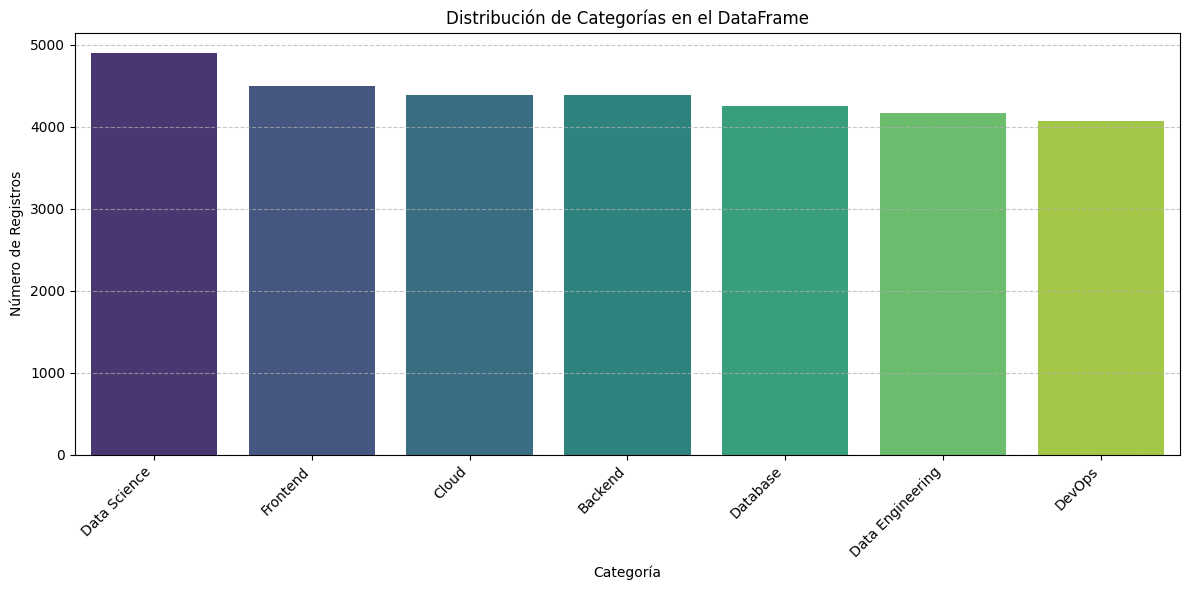

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar la ocurrencia de cada categoría
category_counts = df['categoria'].value_counts().reset_index()
category_counts.columns = ['categoria', 'count']

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x='categoria', y='count', data=category_counts, palette='viridis', hue='categoria', legend=False)
plt.title('Distribución de Categorías en el DataFrame')
plt.xlabel('Categoría')
plt.ylabel('Número de Registros')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Visualización de Nube Palabras claves - General**

In [27]:
#Intalando recurso requeirido
!pip install wordcloud

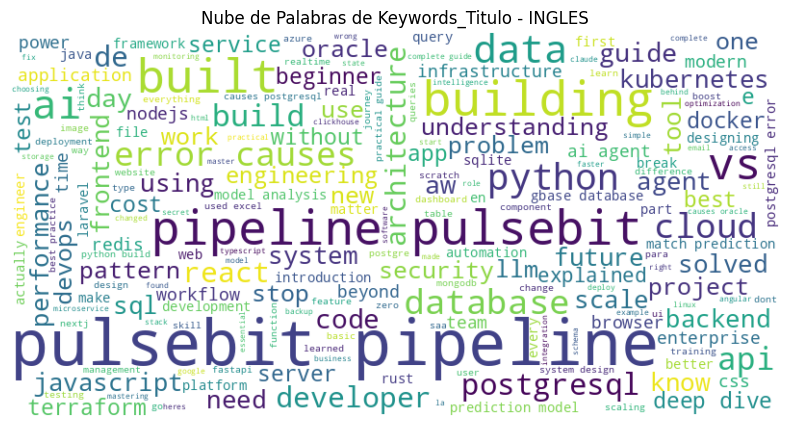

In [28]:
#'keywords_titulo' - INGLES
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Unir todas las palabras clave de la columna 'keywords_titulo' en una sola cadena de texto
# Primero, asegurarnos de que sean listas de strings y luego unirlas.
all_keywords_titulo = ' '.join([' '.join(map(str, k)) for k in df['keywords_titulo'] if k])

# Generar la nube de palabras
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_keywords_titulo)

# Mostrar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de Keywords_Titulo - INGLES')
plt.show()

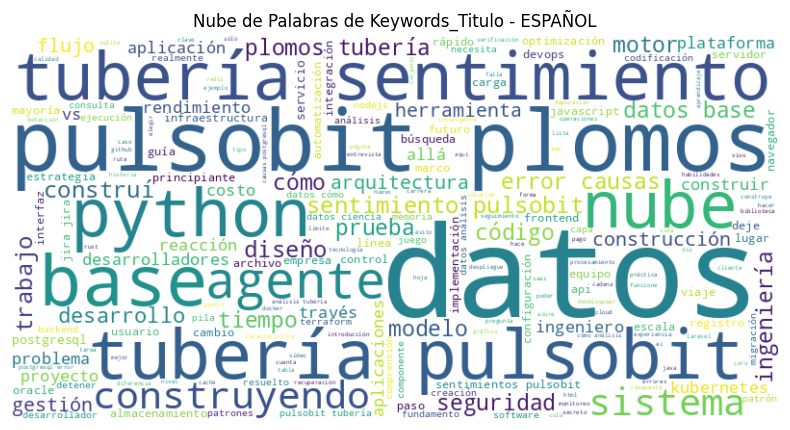

In [29]:
#keywords_titulo_esp - ESPAÑOL
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Unir todas las palabras clave de la columna 'keywords_titulo_esp' en una sola cadena de texto
# Primero, asegurarnos de que sean listas de strings y luego unirlas.
all_keywords_titulo_esp = ' '.join([' '.join(map(str, k)) for k in df['keywords_titulo_esp'] if k])

# Generar la nube de palabras
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_keywords_titulo_esp)

# Mostrar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de Keywords_Titulo - ESPAÑOL')
plt.show()

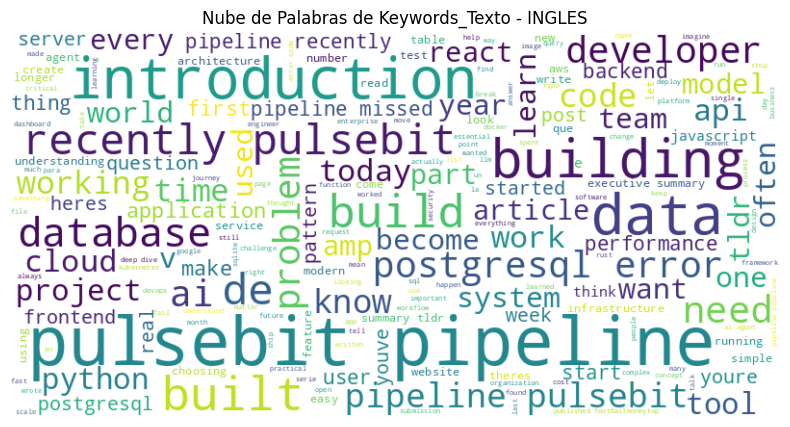

In [30]:
# Nube de Palabras para 'keywords_texto' - INGLES
# Unir todas las palabras clave de la columna 'keywords_texto' en una sola cadena de texto
all_keywords_texto = ' '.join([' '.join(map(str, k)) for k in df['keywords_texto'] if k])

# Generar la nube de palabras
wordcloud_texto = WordCloud(width=800, height=400, background_color='white').generate(all_keywords_texto)

# Mostrar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_texto, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de Keywords_Texto - INGLES')
plt.show()

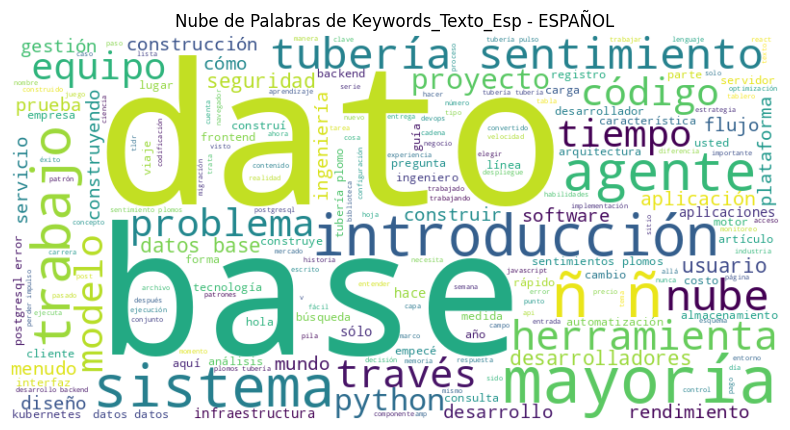

In [31]:
# Nube de Palabras para 'keywords_texto_esp' - ESPAÑOL
# Unir todas las palabras clave de la columna 'keywords_texto_esp' en una sola cadena de texto
all_keywords_texto_esp_new = ' '.join([' '.join(map(str, k)) for k in df['keywords_texto_esp'] if k])

# Generar la nube de palabras
wordcloud_titulo_esp = WordCloud(width=800, height=400, background_color='white').generate(all_keywords_texto_esp_new)

# Mostrar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_titulo_esp, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de Keywords_Texto_Esp - ESPAÑOL')
plt.show()

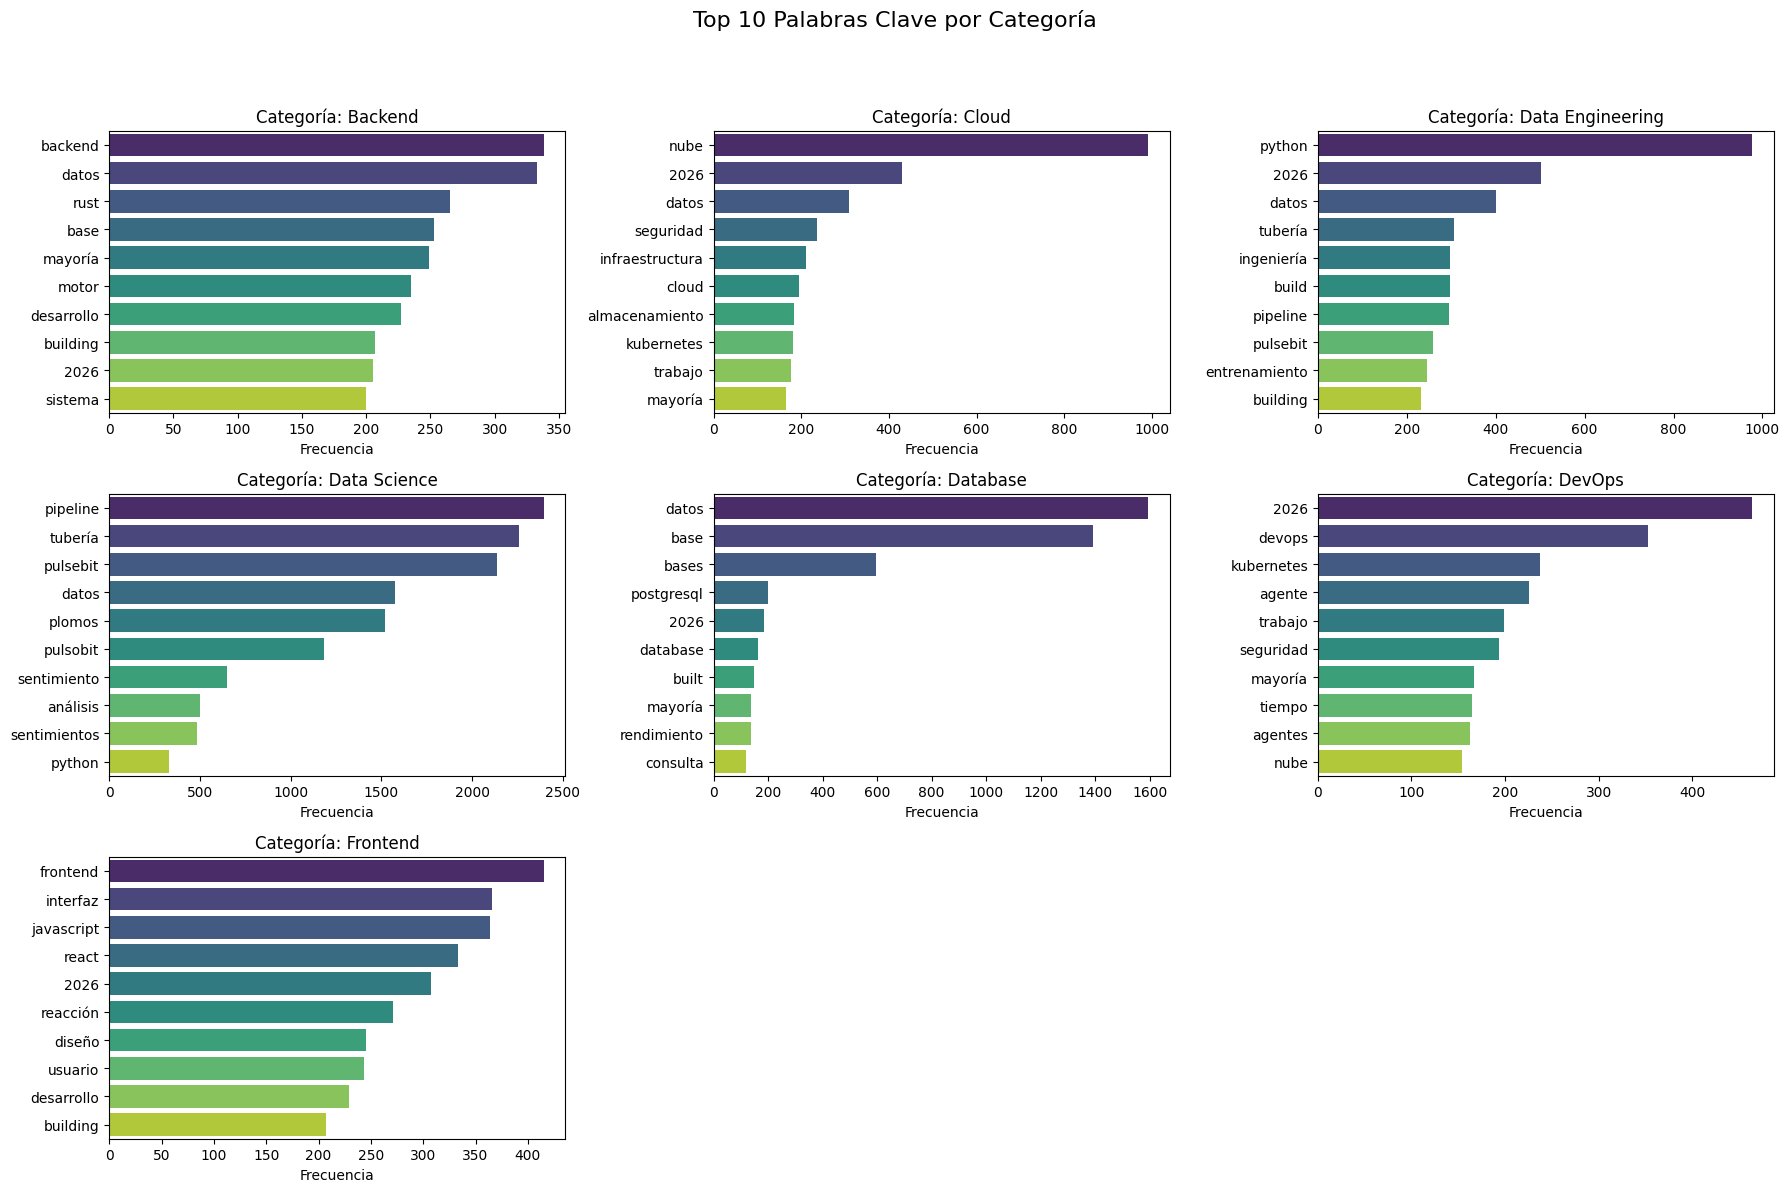

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Preparar un diccionario para almacenar todas las palabras clave combinadas por categoría
# Incluiremos keywords de título y texto, tanto en inglés como en español
all_category_keywords = {
    'Backend': [], 'Cloud': [], 'Data Engineering': [],
    'Data Science': [], 'Database': [], 'DevOps': [], 'Frontend': []
}

# Iterar sobre el DataFrame para combinar las palabras clave por categoría
for index, row in df.iterrows():
    category = row['categoria']

    # Añadir palabras clave de título (inglés)
    if row['keywords_titulo']:
        all_category_keywords[category].extend(row['keywords_titulo'])
    # Añadir palabras clave de texto (inglés)
    if row['keywords_texto']:
        all_category_keywords[category].extend(row['keywords_texto'])
    # Añadir palabras clave de título (español)
    if row['keywords_titulo_esp']:
        all_category_keywords[category].extend(row['keywords_titulo_esp'])
    # Añadir palabras clave de texto (español)
    if row['keywords_texto_esp']:
        all_category_keywords[category].extend(row['keywords_texto_esp'])

# Crear un DataFrame para los datos del gráfico
plot_data = []
for category, keywords_list in all_category_keywords.items():
    # Contar la frecuencia de cada palabra clave
    keyword_counts = Counter(keywords_list)

    # Obtener las 10 palabras clave más comunes
    for keyword, count in keyword_counts.most_common(10):
        plot_data.append({
            'Categoría': category,
            'Palabra Clave': keyword,
            'Frecuencia': count
        })

df_plot = pd.DataFrame(plot_data)

# Generar el gráfico de barras comparativo
fig = plt.figure(figsize=(18, 12)) # Ajustar el tamaño total de la figura
plt.suptitle('Top 10 Palabras Clave por Categoría', fontsize=16, y=1.02) # Título general

# Determinar el número de filas y columnas para los subplots
n_categories = len(all_category_keywords.keys()) # Se corrigió aquí
n_cols = 3 # Por ejemplo, 3 columnas
n_rows = (n_categories + n_cols - 1) // n_cols # Calcular el número de filas necesario

for i, category in enumerate(all_category_keywords.keys()): # Se corrigió aquí
    plt.subplot(n_rows, n_cols, i + 1)
    subset = df_plot[df_plot['Categoría'] == category].sort_values(by='Frecuencia', ascending=False)
    sns.barplot(x='Frecuencia', y='Palabra Clave', data=subset, palette='viridis', hue='Palabra Clave', legend=False)
    plt.title(f'Categoría: {category}')
    plt.xlabel('Frecuencia')
    plt.ylabel('') # Eliminar la etiqueta del eje Y para evitar redundancia
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajustar diseño para evitar solapamientos y dejar espacio para el título general

plt.show()

In [33]:
print("Frecuencia de las nuevas palabras clave individuales por categoría:")
display(df_plot.head(10))

Frecuencia de las nuevas palabras clave individuales por categoría:


,Categoría,Palabra Clave,Frecuencia
0,Backend,backend,338
1,Backend,datos,333
2,Backend,rust,265
3,Backend,base,253
4,Backend,mayoría,249
5,Backend,motor,235
6,Backend,desarrollo,227
7,Backend,building,207
8,Backend,2026,205
9,Backend,sistema,200


### Análisis de Correlación: Palabras Clave Distintivas por Categoría (TF-IDF)

Para identificar las palabras clave que son más "representativas" o "correlacionan" fuertemente con cada categoría, utilizaremos la métrica **TF-IDF (Term Frequency-Inverse Document Frequency)**.

**¿Qué es TF-IDF?**

TF-IDF es una medida estadística que evalúa la importancia de una palabra para un documento en una colección o corpus. Cuanto mayor es el valor de TF-IDF, más importante es la palabra para el documento o categoría.

*   **Term Frequency (TF)**: Mide con qué frecuencia aparece una palabra en una categoría. Una TF alta indica que la palabra es importante dentro de esa categoría.

*   **Inverse Document Frequency (IDF)**: Mide la importancia general de una palabra. Si una palabra aparece en muchos documentos (categorías), su IDF será bajo, lo que significa que no es muy distintiva. Si aparece en pocos documentos, su IDF será alto, indicando que es más específica.

Al multiplicar TF por IDF, obtenemos una puntuación que favorece las palabras que son frecuentes en una categoría específica pero raras en el resto de las categorías, haciéndolas distintivas.

Palabras clave más distintivas (por TF-IDF) por categoría:

--- Categoría: Backend ---
backend       0.315559
datos         0.208148
api           0.189336
2026          0.180233
rust          0.179626
building      0.176592
base          0.155352
mayoría       0.151711
motor         0.150498
desarrollo    0.143215
Name: Backend, dtype: float64

--- Categoría: Cloud ---
nube          0.474984
cloud         0.365515
2026          0.258366
aws           0.206414
datos         0.147505
ai            0.136372
terraform     0.129015
kubernetes    0.128023
seguridad     0.113644
azure         0.112716
Name: Cloud, dtype: float64

--- Categoría: Data Engineering ---
python        0.604909
2026          0.270495
pulsebit      0.237626
datos         0.190366
pipeline      0.163964
plomos        0.149787
build         0.144511
tubería       0.143122
ingeniería    0.142195
pulsobit      0.125694
Name: Data Engineering, dtype: float64

--- Categoría: Data Science ---
pulsebit        0.604950
plomo

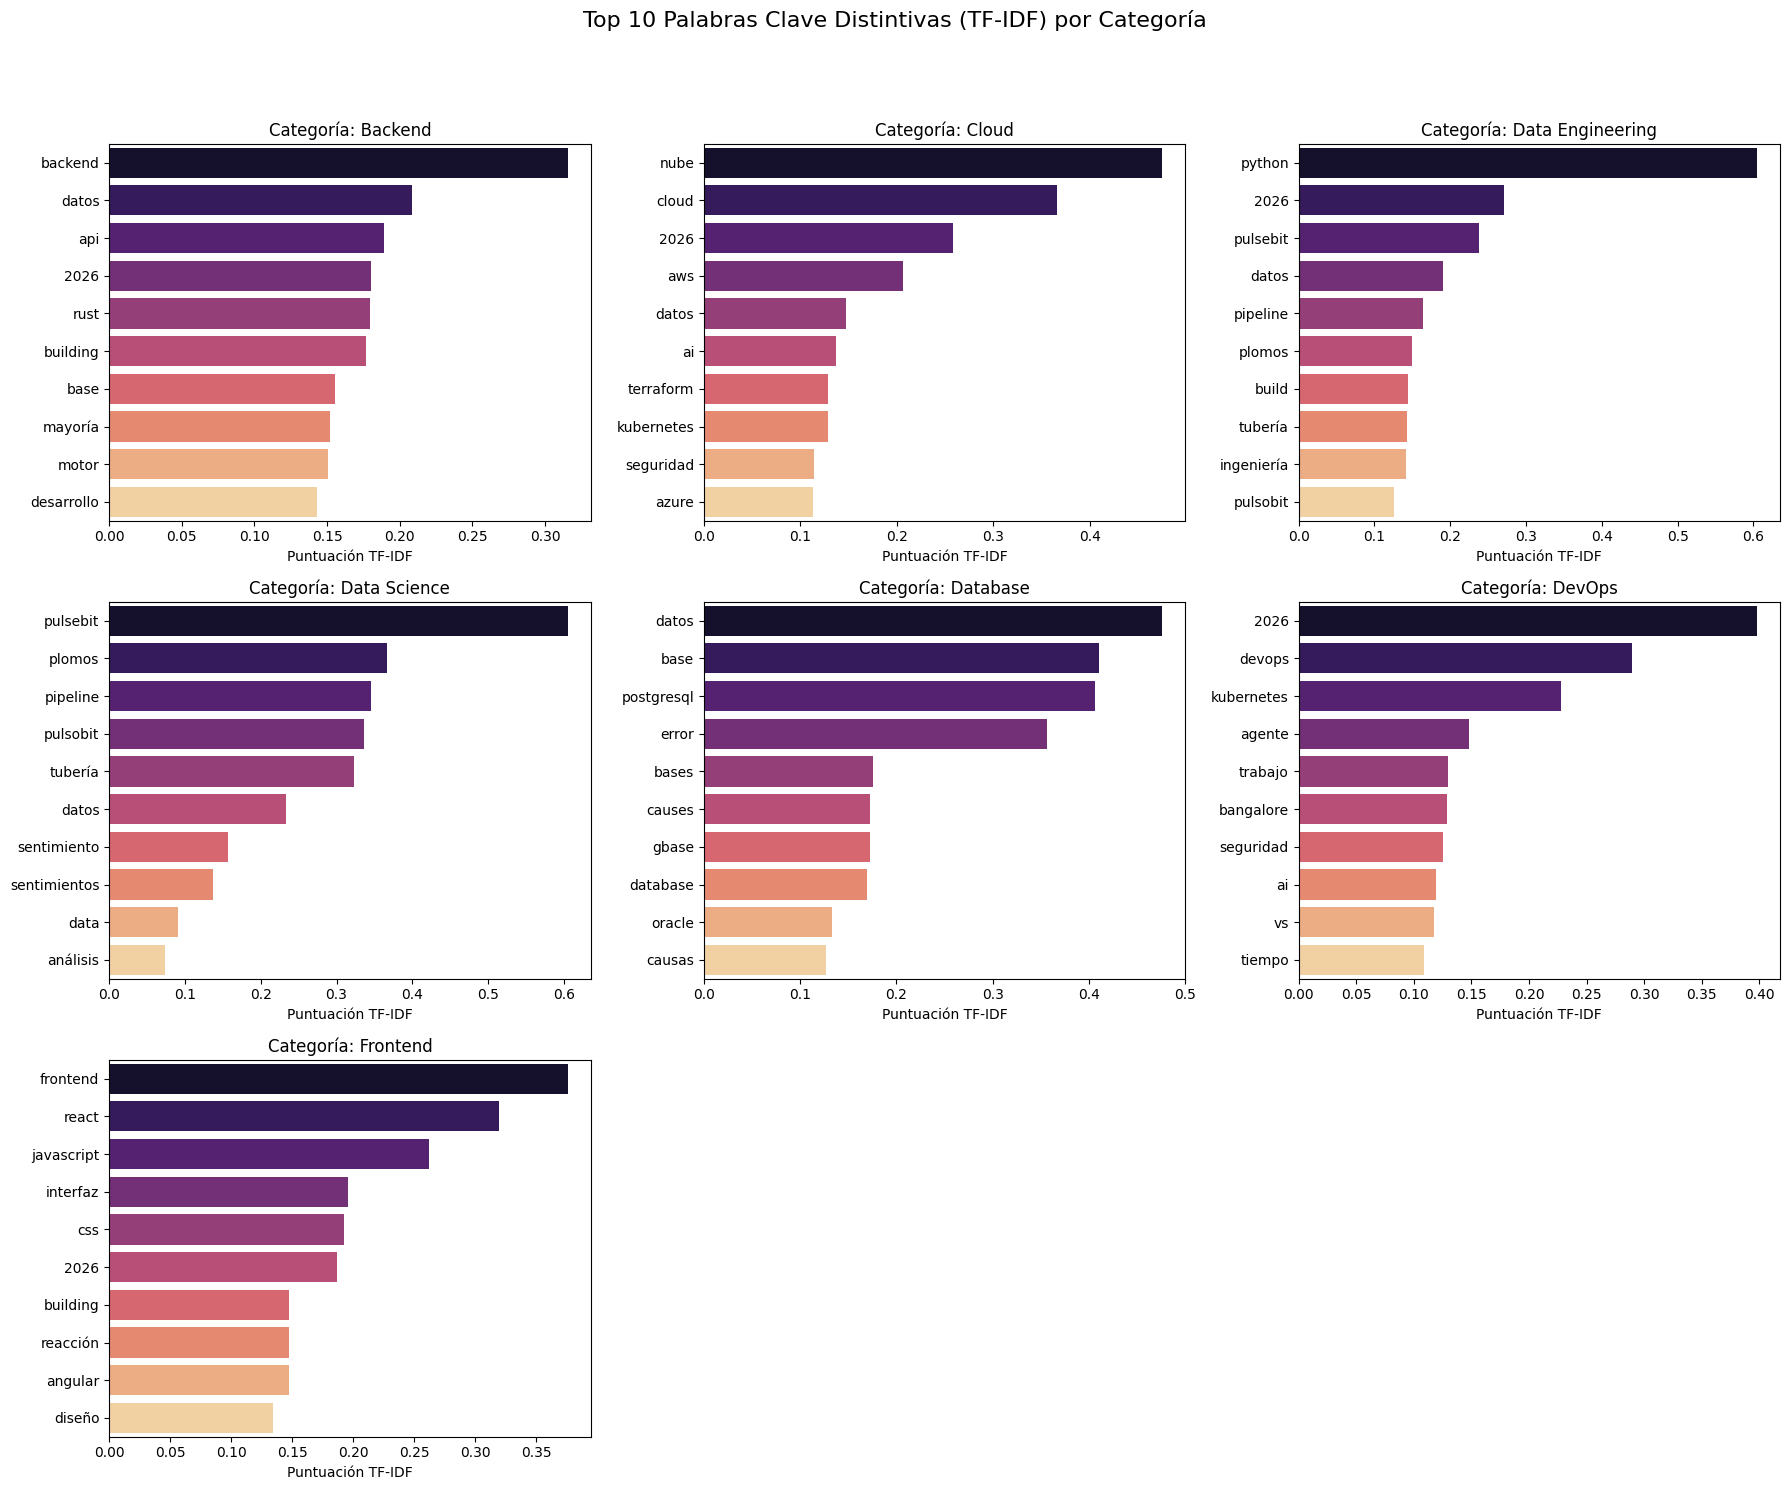

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Preparar documentos para TF-IDF: las palabras clave de cada categoría como una única cadena de texto
category_docs = {}
for category, keywords_list in all_category_keywords.items():
    category_docs[category] = ' '.join(keywords_list)

# Convertir a una lista de documentos en el orden de las categorías
categories_ordered = list(category_docs.keys())
documents = [category_docs[cat] for cat in categories_ordered]

# Calcular TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)

# Obtener nombres de las características (palabras clave)
feature_names = vectorizer.get_feature_names_out()

# Crear un DataFrame para las puntuaciones TF-IDF
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names, index=categories_ordered)

# Identificar y mostrar las palabras clave más distintivas por categoría
print("Palabras clave más distintivas (por TF-IDF) por categoría:")
top_keywords_by_category_tfidf = {}
plot_data_tfidf = []

for category in categories_ordered:
    # Ordenar las palabras clave por su puntuación TF-IDF para la categoría actual
    top_keywords_for_category = tfidf_df.loc[category].sort_values(ascending=False).head(10)
    top_keywords_by_category_tfidf[category] = top_keywords_for_category

    print(f"\n--- Categoría: {category} ---")
    print(top_keywords_for_category)

    for keyword, score in top_keywords_for_category.items():
        plot_data_tfidf.append({
            'Categoría': category,
            'Palabra Clave': keyword,
            'Puntuación TF-IDF': score
        })

df_plot_tfidf = pd.DataFrame(plot_data_tfidf)

# Visualizar las palabras clave más distintivas por categoría en gráficos de barras

n_categories = len(categories_ordered)
n_cols = 3 # Número de columnas para los subplots
n_rows = (n_categories + n_cols - 1) // n_cols # Calcular el número de filas necesario

fig = plt.figure(figsize=(18, n_rows * 5)) # Ajustar el tamaño total de la figura
plt.suptitle('Top 10 Palabras Clave Distintivas (TF-IDF) por Categoría', fontsize=16, y=1.02) # Título general

for i, category in enumerate(categories_ordered):
    plt.subplot(n_rows, n_cols, i + 1)
    subset = df_plot_tfidf[df_plot_tfidf['Categoría'] == category].sort_values(by='Puntuación TF-IDF', ascending=False)
    sns.barplot(x='Puntuación TF-IDF', y='Palabra Clave', data=subset, palette='magma', hue='Palabra Clave', legend=False)
    plt.title(f'Categoría: {category}')
    plt.xlabel('Puntuación TF-IDF')
    plt.ylabel('')
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajustar diseño para evitar solapamientos

plt.show()

### Comparación: Frecuencia vs. TF-IDF para Palabras Clave por Categoría

A continuación, visualizaremos la diferencia entre las palabras clave más frecuentes y las más distintivas (según TF-IDF) para cada categoría. Esto ayudará a entender cómo TF-IDF prioriza palabras que son relevantes para una categoría específica, en lugar de solo las que aparecen con mayor recurrencia en general.

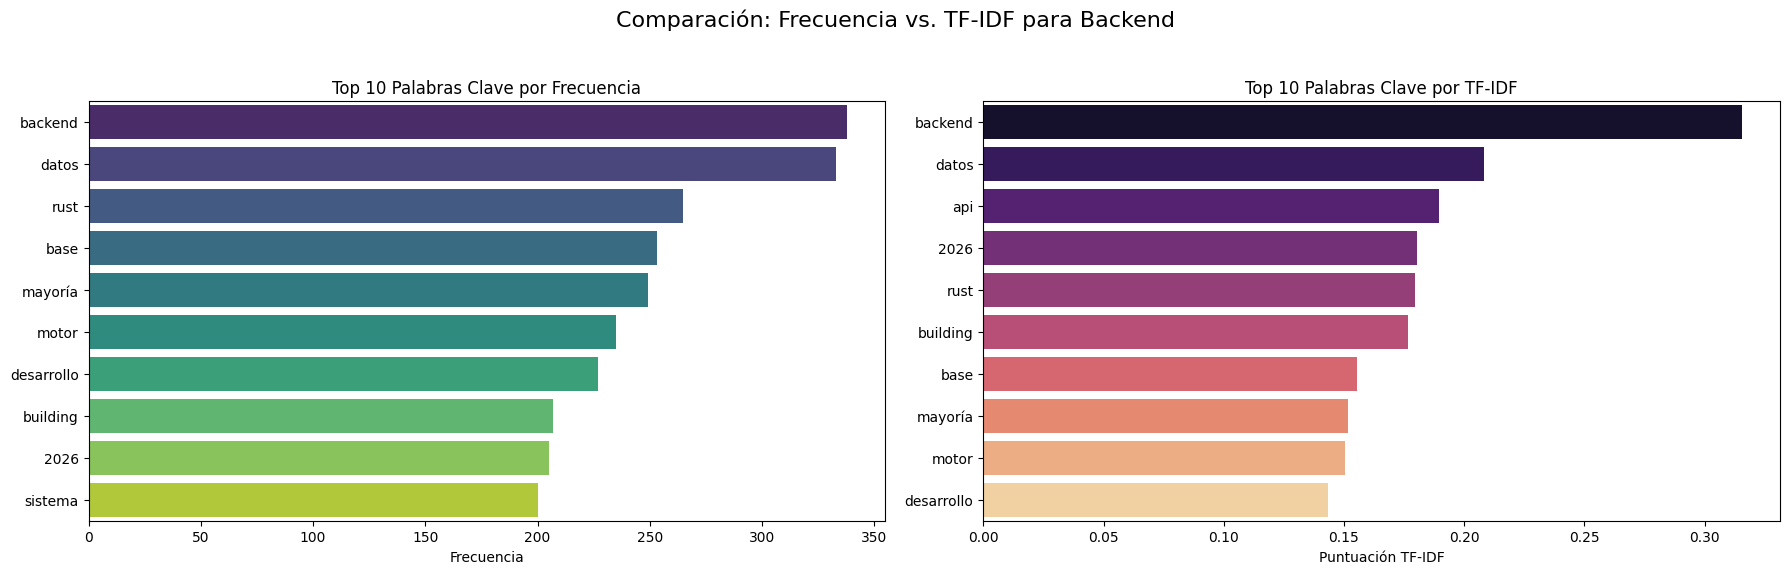

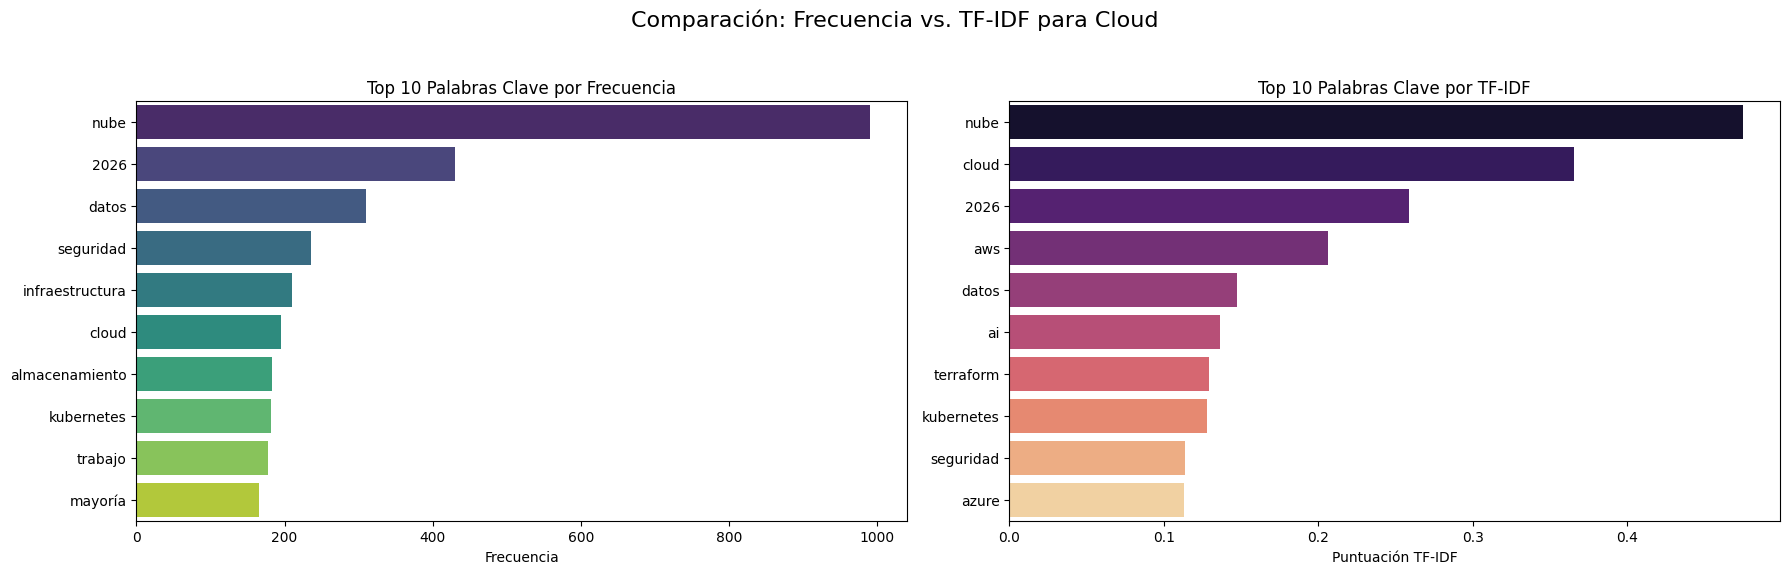

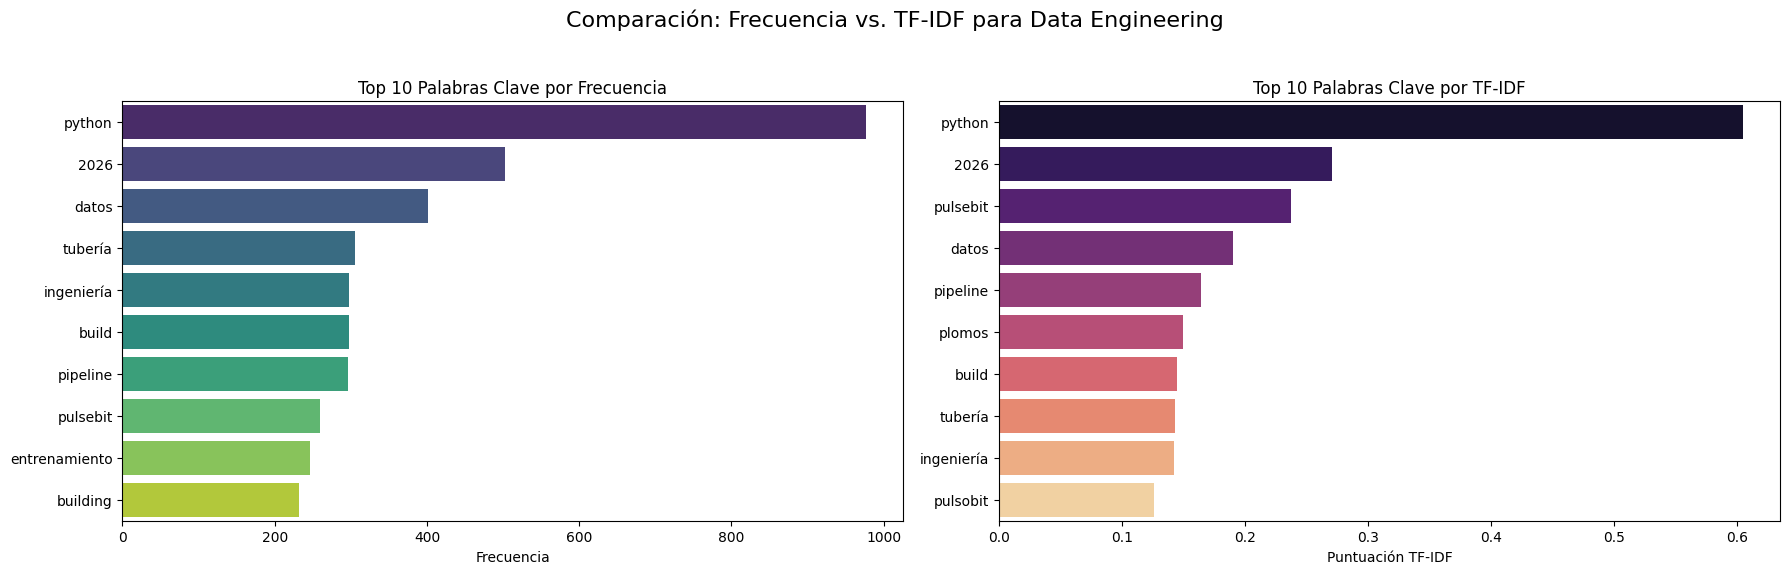

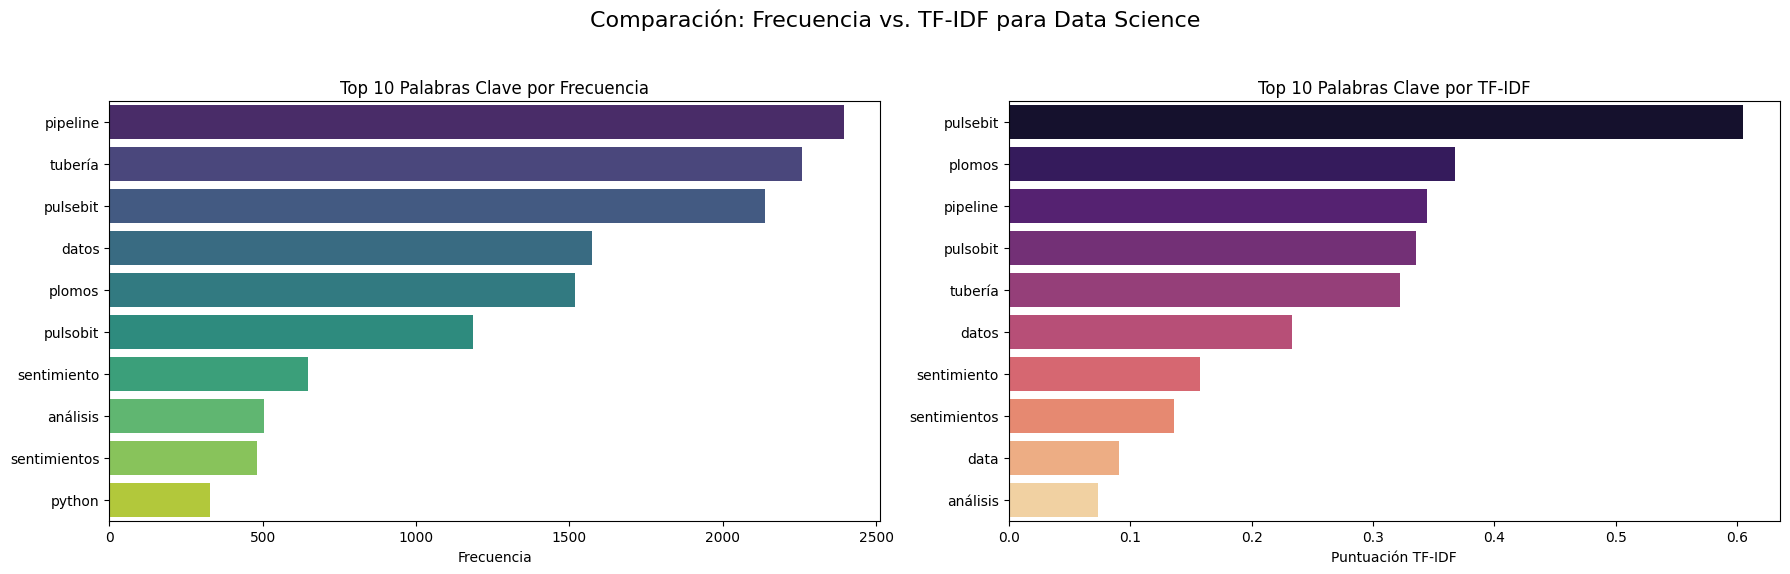

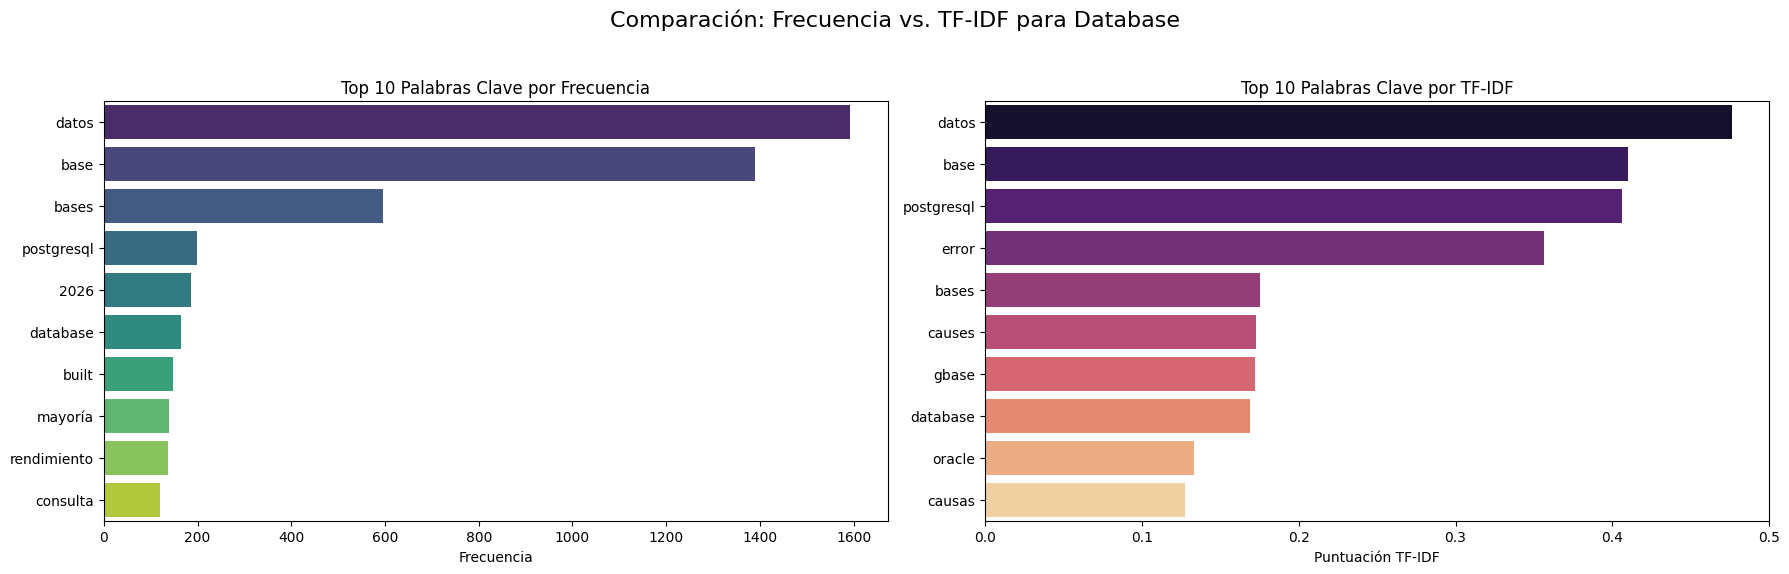

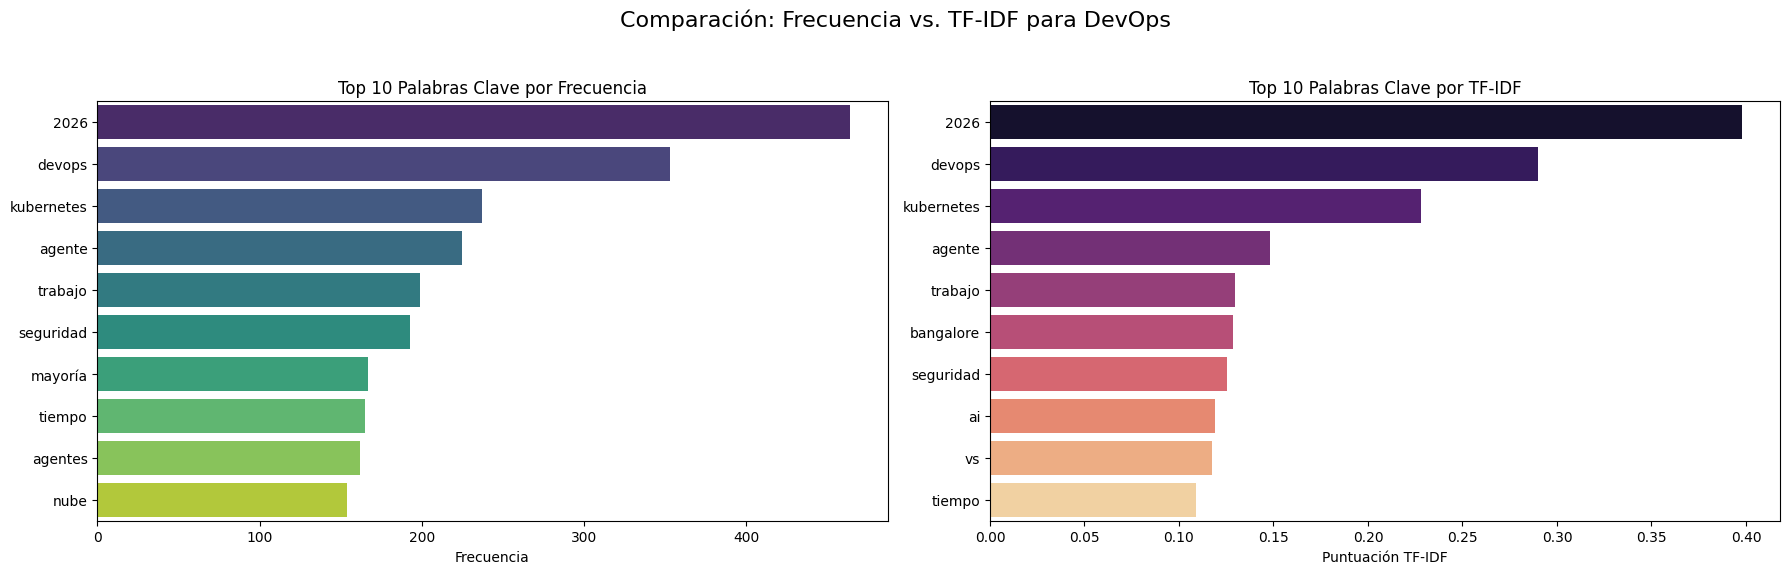

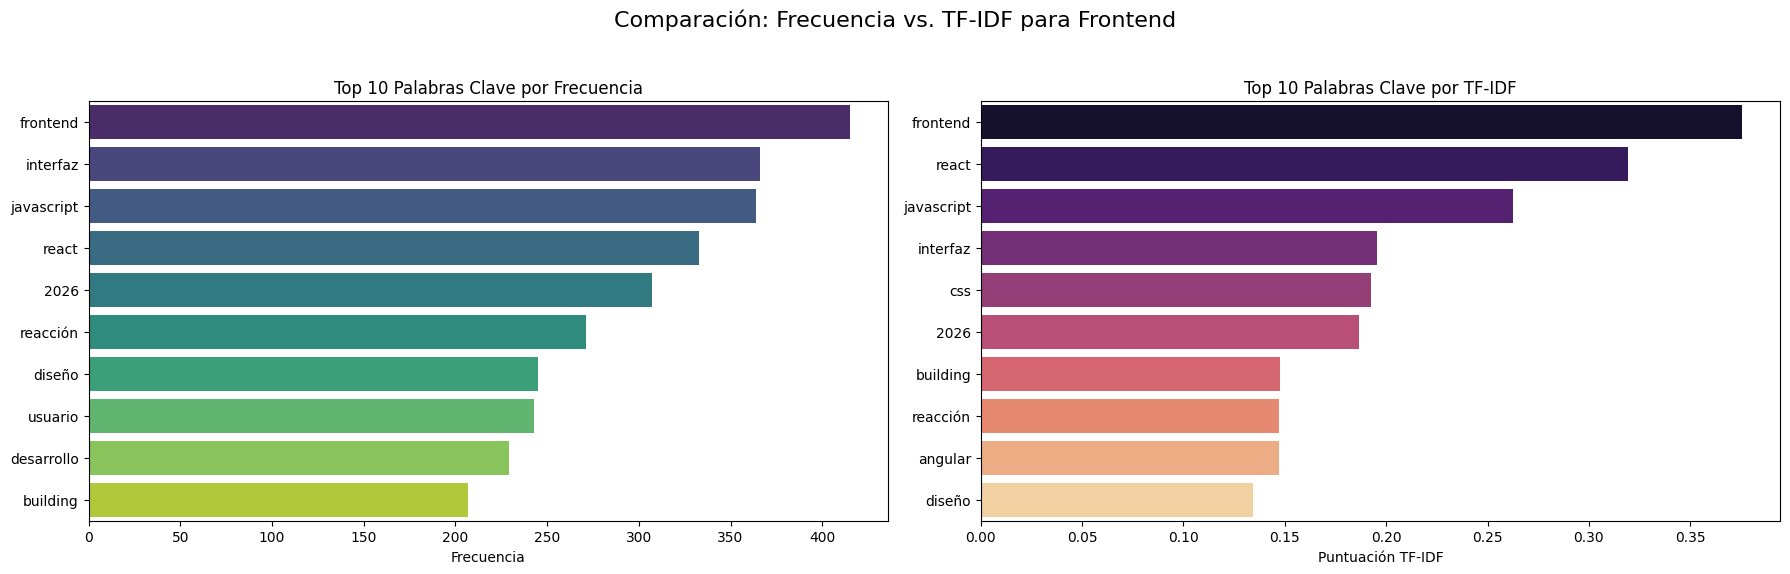

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

categories_list = df_plot['Categoría'].unique()

for category in categories_list:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # Un par de subplots por categoría
    fig.suptitle(f'Comparación: Frecuencia vs. TF-IDF para {category}', fontsize=16)

    # Gráfico de Frecuencia
    subset_freq = df_plot[df_plot['Categoría'] == category].sort_values(by='Frecuencia', ascending=False)
    sns.barplot(ax=axes[0], x='Frecuencia', y='Palabra Clave', data=subset_freq, palette='viridis', hue='Palabra Clave', legend=False)
    axes[0].set_title('Top 10 Palabras Clave por Frecuencia')
    axes[0].set_xlabel('Frecuencia')
    axes[0].set_ylabel('')

    # Gráfico de TF-IDF
    subset_tfidf = df_plot_tfidf[df_plot_tfidf['Categoría'] == category].sort_values(by='Puntuación TF-IDF', ascending=False)
    sns.barplot(ax=axes[1], x='Puntuación TF-IDF', y='Palabra Clave', data=subset_tfidf, palette='magma', hue='Palabra Clave', legend=False)
    axes[1].set_title('Top 10 Palabras Clave por TF-IDF')
    axes[1].set_xlabel('Puntuación TF-IDF')
    axes[1].set_ylabel('')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar diseño para el título general
    plt.show()

### Tabla Resumen: Comparación de Frecuencia vs. TF-IDF por Categoría

La siguiente tabla presenta las palabras clave más relevantes, comparando su frecuencia de aparición con su puntuación TF-IDF. Esto permite identificar tanto las palabras clave comunes como las más distintivas para cada categoría.

In [36]:
import pandas as pd

# Unir los DataFrames de frecuencia y TF-IDF
df_summary = pd.merge(
    df_plot,
    df_plot_tfidf,
    on=['Categoría', 'Palabra Clave'],
    how='outer'  # Usar outer join para incluir todas las palabras clave de ambos rankings
)

# Renombrar columnas para mayor claridad
df_summary.rename(columns={
    'Frecuencia': 'Frecuencia_Palabra_Clave',
    'Puntuación TF-IDF': 'TFIDF_Puntuación'
}, inplace=True)

# Rellenar valores NaN con 0 (en caso de que una palabra clave aparezca en un ranking pero no en el otro)
df_summary.fillna(0, inplace=True)

# Ordenar para una mejor visualización
df_summary = df_summary.sort_values(by=['Categoría', 'Frecuencia_Palabra_Clave', 'TFIDF_Puntuación'], ascending=[True, False, False])

display(df_summary.head(20))

,Categoría,Palabra Clave,Frecuencia_Palabra_Clave,TFIDF_Puntuación
2,Backend,backend,338.0,0.315559
5,Backend,datos,333.0,0.208148
9,Backend,rust,265.0,0.179626
3,Backend,base,253.0,0.155352
7,Backend,mayoría,249.0,0.151711
8,Backend,motor,235.0,0.150498
6,Backend,desarrollo,227.0,0.143215
4,Backend,building,207.0,0.176592
0,Backend,2026,205.0,0.180233
10,Backend,sistema,200.0,0.000000


**EXPORTANDO DATASET FINAL - FULL Formato EXTENDIDO**

In [37]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   titulo               30641 non-null  object
 1   texto                30641 non-null  object
 2   categoria            30641 non-null  object
 3   url                  30641 non-null  object
 4   titulo_esp           30641 non-null  object
 5   texto_esp            30641 non-null  object
 6   keywords_titulo      30641 non-null  object
 7   keywords_texto       30641 non-null  object
 8   keywords_titulo_esp  30641 non-null  object
 9   keywords_texto_esp   30641 non-null  object
dtypes: object(10)
memory usage: 2.3+ MB


In [38]:
import os

# Exportar dataset full traducido, limpio y con palabras claves

os.makedirs("/content/drive/MyDrive/Adataset_hackathon/", exist_ok=True)
os.makedirs("/content/sample_data/", exist_ok=True)
os.makedirs("/content/data/", exist_ok=True)

df.to_csv("/content/drive/MyDrive/Adataset_hackathon/dataset_inicial_devto_hackaton_eng_esp_final.csv", sep = ';', index=False, encoding="utf-8-sig")
df.to_csv("/content/sample_data/dataset_inicial_devto_hackaton_eng_esp_final.csv", sep = ';', index=False, encoding="utf-8-sig")
df.to_csv("/content/data/dataset_inicial_devto_hackaton_eng_esp_final.csv", sep = ';', index=False, encoding="utf-8-sig")
#df.to_json("data/dataset_devto_englesespanol.json", orient="records", force_ascii=False, indent=2)

**EXPORTANDO DATASET FINAL - TRADUCIDOS INGLES/ESPAÑOL**

####Para Limpieza y Análisis de Exploración (EDA)

Archivos de resultados esperados
- dataset_devto_pure_labels_clean_es.csv
- dataset_devto_pure_labels_clean_en.csv



In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   titulo               30641 non-null  object
 1   texto                30641 non-null  object
 2   categoria            30641 non-null  object
 3   url                  30641 non-null  object
 4   titulo_esp           30641 non-null  object
 5   texto_esp            30641 non-null  object
 6   keywords_titulo      30641 non-null  object
 7   keywords_texto       30641 non-null  object
 8   keywords_titulo_esp  30641 non-null  object
 9   keywords_texto_esp   30641 non-null  object
dtypes: object(10)
memory usage: 2.3+ MB


## Generando archivos de resultado: dataset_devto_pure_labels_clean_es.csv

**Formato Extendido**

**titulo:** viene del atributo titulo_esp del contenido técnico en Español.

**texto:** viene del  atributo texto_esp de la descripción, resumen o extracto técnico en español.

**categoria:** categorías (Backend, Frontend, Data Engineering, Cloud, DevOps, Database).

**url:** URL de origen fuente del contenido

**keywords_titulo**: Palabras claves que vienen del  atributo keywords_titulo_esp

**keywords_texto:** Palabras claves  que vienen del  atributo keywords_titulo_esp


#Generando para limpieza y exploración análisis EDA (Español)
 "/content/drive/MyDrive/Adataset_hackathon/dataset_devto_pure_labels_clean_es.csv"

In [40]:
# Crear un nuevo DataFrame con las columnas deseadas y sus nuevos nombres - ESPAÑOL
df_esp = df[['titulo_esp', 'texto_esp', 'categoria', 'url', 'keywords_titulo_esp','keywords_texto_esp' ]].copy()
df_esp.rename(columns={'titulo_esp': 'titulo', 'texto_esp': 'texto', 'keywords_titulo_esp':'keywords_titulo', 'keywords_texto_esp':'keywords_texto' }, inplace=True)
df_esp


,titulo,texto,categoria,url,keywords_titulo,keywords_texto
0,Solon Server Threads: Cero-Config Auto-Tuning ...,Solon Server Threads: Cero-Config Auto-Tuning ...,Backend,https://dev.to/solonjava/solon-server-threads-...,[núcleos],[núcleos]
1,Por qué mi caché no tiene TTL,"La última vez, escribí sobre el dilema de alim...",Backend,https://dev.to/shunya_shida/why-my-cache-has-n...,[caché],"[través, dilema]"
2,Autenticación de JWT: Modelo mental de un inge...,Introducción Imagínese que llega a un hotel. E...,Backend,https://dev.to/juma_evans_34e389ef539266/jwt-a...,[autenticación],"[prueba, llega, identificación, hotel]"
3,Construir contra las API reales no es nada com...,"Hace unos meses, empecé a pasar mucho más tiem...",Backend,https://dev.to/jan_inteldo/building-against-re...,"[leer, documentos, construir]","[principio, pasar, hace]"
4,Construcción de la lógica de reinicio resilien...,Cada desarrollador de Node.js ha escrito esto ...,Backend,https://dev.to/mukesh_13/building-resilient-re...,"[lógica, construcción]","[nodejs, escrito]"
...,...,...,...,...,...,...
30636,"Vue3: Como estimar componentes (global, alcanc...",Léalo en inglés Nesses últimos anos usando Vue...,Frontend,https://dev.to/sucodelarangela/vue3-como-estil...,"[vue3, módulos]",[léalo]
30637,Más allá de la DOM Virtual: Potencia concurren...,El DOM Virtual de React fue una vez la piedra ...,Frontend,https://dev.to/nshnt/beyond-the-virtual-dom-re...,"[usuario, representación, react, interfaz, int...","[react, lanzamiento]"
30638,Comprendiendo el patrón de observación en reac...,Si has estado construyendo aplicaciones de Rea...,Frontend,https://dev.to/alisamir/understanding-observer...,"[reacción, patrón, observación, comprendiendo]","[tiempo, react, probable]"
30639,Inyectar variables globales sass de next.confi...,Añadir variable global al compilador sass with...,Frontend,https://dev.to/vavilov2212/inject-sass-global-...,[nextconfigjs variables env sass],[nextjs]


In [41]:
# Exportar el DataFrame a un archivo CSV - ESPAÑOL
os.makedirs("data", exist_ok=True)
df_esp.to_csv("/content/drive/MyDrive/Adataset_hackathon/dataset_devto_pure_labels_clean_es.csv", sep = ';', index=False, encoding="utf-8-sig")
df_esp.to_csv("/content/sample_data/dataset_devto_pure_labels_clean_es.csv", sep = ';', index=False, encoding="utf-8-sig")
df_esp.to_csv("/content/data/dataset_devto_pure_labels_clean_es.csv", sep = ';', index=False, encoding="utf-8-sig")

print("DataFrame exportado archivo 'CSV' creado y guardado en /content/sample_data/")
print("Primeras 5 filas del DataFrame exportado:")
display(df_esp.head())

DataFrame exportado archivo 'CSV' creado y guardado en /content/sample_data/
Primeras 5 filas del DataFrame exportado:


,titulo,texto,categoria,url,keywords_titulo,keywords_texto
0,Solon Server Threads: Cero-Config Auto-Tuning ...,Solon Server Threads: Cero-Config Auto-Tuning ...,Backend,https://dev.to/solonjava/solon-server-threads-...,[núcleos],[núcleos]
1,Por qué mi caché no tiene TTL,"La última vez, escribí sobre el dilema de alim...",Backend,https://dev.to/shunya_shida/why-my-cache-has-n...,[caché],"[través, dilema]"
2,Autenticación de JWT: Modelo mental de un inge...,Introducción Imagínese que llega a un hotel. E...,Backend,https://dev.to/juma_evans_34e389ef539266/jwt-a...,[autenticación],"[prueba, llega, identificación, hotel]"
3,Construir contra las API reales no es nada com...,"Hace unos meses, empecé a pasar mucho más tiem...",Backend,https://dev.to/jan_inteldo/building-against-re...,"[leer, documentos, construir]","[principio, pasar, hace]"
4,Construcción de la lógica de reinicio resilien...,Cada desarrollador de Node.js ha escrito esto ...,Backend,https://dev.to/mukesh_13/building-resilient-re...,"[lógica, construcción]","[nodejs, escrito]"


## Generando archivos de resultado: dataset_devto_pure_labels_clean_en.csv

**Formato Extendido**

**titulo:** viene del atributo titulo del contenido técnico en Inglés.

**texto:** viene del  atributo texto de la descripción, resumen o extracto técnico en Inglés

**categoria:** categorías (Backend, Frontend, Data Engineering, Cloud, DevOps, Database).

**url:** URL de origen fuente del contenido

**keywords_titulo**: Palabras claves que vienen del  atributo keywords_titulo en inglés

**keywords_texto:** Palabras claves  que vienen del  atributo keywords_texto en inglés

#Generando para limpieza y exploración análisis EDA (Ingles)
 "/content/drive/MyDrive/Adataset_hackathon/dataset_devto_pure_labels_clean_en.csv"

In [42]:
# Crear un nuevo DataFrame con las columnas deseadas y sus nuevos nombres - INGLES
df_eng = df[['titulo', 'texto', 'categoria', 'url', 'keywords_titulo','keywords_texto' ]].copy()
df_eng

,titulo,texto,categoria,url,keywords_titulo,keywords_texto
0,Solon Server Threads: Zero-Config Auto-Tuning ...,Solon Server Threads: Zero-Config Auto-Tuning ...,Backend,https://dev.to/solonjava/solon-server-threads-...,[cpu cores — iobound corethreads maxthreads],[solon server threads zeroconfig autotuning]
1,Why My Cache Has No TTL,"Last time, I wrote about the dilemma of feedin...",Backend,https://dev.to/shunya_shida/why-my-cache-has-n...,[cache],"[wrote, dilemma]"
2,JWT Authentication: A Backend Engineer's Menta...,Introduction Imagine you arrive at a hotel. ...,Backend,https://dev.to/juma_evans_34e389ef539266/jwt-a...,[jwt authentication],"[show, reception, prove, hotel, arrive]"
3,Building Against Real APIs Is Nothing Like Rea...,"A few months ago, I started spending a lot mor...",Backend,https://dev.to/jan_inteldo/building-against-re...,"[docs, building]",[first]
4,Building Resilient Retry Logic in Node.js: Exp...,Every Node.js developer has written this at so...,Backend,https://dev.to/mukesh_13/building-resilient-re...,[nodejs exponential backoff jitter],[written]
...,...,...,...,...,...,...
30636,"Vue3: Como estilizar componentes (global, scop...",Read it in English Nesses últimos anos usando...,Frontend,https://dev.to/sucodelarangela/vue3-como-estil...,[vue3 como estilizar componentes global scoped...,[read]
30637,Beyond the Virtual DOM: React’s Concurrent Pow...,React's Virtual DOM was once the cornerstone o...,Frontend,https://dev.to/nshnt/beyond-the-virtual-dom-re...,[beyond],"[release, cornerstone]"
30638,Understanding Observer Pattern in React: A Com...,If you've been building React applications for...,Frontend,https://dev.to/alisamir/understanding-observer...,[react],[youve]
30639,Inject sass global variables from next.config....,Add global variable to sass compiler with-n...,Frontend,https://dev.to/vavilov2212/inject-sass-global-...,[nextconfigjs sass env variables],[sass compiler withnextsass]


In [43]:
# Exportar el DataFrame a un archivo CSV - INGLES
os.makedirs("data", exist_ok=True)
df_eng.to_csv("/content/drive/MyDrive/Adataset_hackathon/dataset_devto_pure_labels_clean_en.csv", sep = ';', index=False, encoding="utf-8-sig")
df_eng.to_csv("/content/sample_data/dataset_devto_pure_labels_clean_en.csv", sep = ';', index=False, encoding="utf-8-sig")
df_eng.to_csv("/content/data/dataset_devto_pure_labels_clean_en.csv", sep = ';', index=False, encoding="utf-8-sig")

print("DataFrame exportado archivo 'CSV' creado y guardado en /content/sample_data/")
print("Primeras 5 filas del DataFrame exportado:")
display(df_eng.head())

DataFrame exportado archivo 'CSV' creado y guardado en /content/sample_data/
Primeras 5 filas del DataFrame exportado:


,titulo,texto,categoria,url,keywords_titulo,keywords_texto
0,Solon Server Threads: Zero-Config Auto-Tuning ...,Solon Server Threads: Zero-Config Auto-Tuning ...,Backend,https://dev.to/solonjava/solon-server-threads-...,[cpu cores — iobound corethreads maxthreads],[solon server threads zeroconfig autotuning]
1,Why My Cache Has No TTL,"Last time, I wrote about the dilemma of feedin...",Backend,https://dev.to/shunya_shida/why-my-cache-has-n...,[cache],"[wrote, dilemma]"
2,JWT Authentication: A Backend Engineer's Menta...,Introduction Imagine you arrive at a hotel. ...,Backend,https://dev.to/juma_evans_34e389ef539266/jwt-a...,[jwt authentication],"[show, reception, prove, hotel, arrive]"
3,Building Against Real APIs Is Nothing Like Rea...,"A few months ago, I started spending a lot mor...",Backend,https://dev.to/jan_inteldo/building-against-re...,"[docs, building]",[first]
4,Building Resilient Retry Logic in Node.js: Exp...,Every Node.js developer has written this at so...,Backend,https://dev.to/mukesh_13/building-resilient-re...,[nodejs exponential backoff jitter],[written]


#Generando dataset.csv - Especial para prototipo (INICIAL)

In [44]:
# Crear un nuevo DataFrame con las columnas deseadas y sus nuevos nombres ESPAÑOL
df_esp_prototipo = df[['titulo_esp', 'texto_esp', 'categoria']].copy()
df_esp_prototipo.rename(columns={'titulo_esp': 'titulo', 'texto_esp': 'texto'}, inplace=True)

df_eng_prototipo = df[['titulo', 'texto', 'categoria']].copy()


# Exportar el DataFrame a un archivo CSV ESPAÑOL
os.makedirs("data", exist_ok=True)
df_esp_prototipo.to_csv("/content/drive/MyDrive/Adataset_hackathon/dataset_esp.csv", sep = ';', index=False, encoding="utf-8-sig")
df_esp_prototipo.to_csv("/content/sample_data/dataset_esp.csv", sep = ';', index=False, encoding="utf-8-sig")

print("Archivo 'dataset_esp.csv' creado y guardado en drive personal y /content/sample_data/")
print("Primeras 5 filas del DataFrame exportado:")
display(df_esp_prototipo.head())

# Exportar el DataFrame a un archivo CSV INGLES
os.makedirs("data", exist_ok=True)
df_eng_prototipo.to_csv("/content/drive/MyDrive/Adataset_hackathon/dataset_eng.csv", sep = ';', index=False, encoding="utf-8-sig")
df_eng_prototipo.to_csv("/content/sample_data/dataset_eng.csv", sep = ';', index=False, encoding="utf-8-sig")
df_eng_prototipo.to_csv("/content/data/dataset_eng.csv", sep = ';', index=False, encoding="utf-8-sig")

print("Archivo 'dataset_eng.csv' creado y guardado en drive personal y /content/sample_data/")
print("Primeras 5 filas del DataFrame exportado:")
display(df_eng_prototipo.head())

# Concatenamos verticalmente para tener todas las entradas en inglés y luego todas las entradas en español
df_dataset = pd.concat([df_eng_prototipo, df_esp_prototipo], ignore_index=True)

# Exportar el DataFrame combinado a un archivo CSV
os.makedirs("data", exist_ok=True)
combined_output_path_drive = "/content/drive/MyDrive/Adataset_hackathon/dataset.csv"
combined_output_path_sample = "/content/sample_data/dataset.csv"
combined_output_path_data = "/content/sample_data/dataset.csv"

df_dataset.to_csv(combined_output_path_drive, sep=';', index=False, encoding="utf-8-sig")
df_dataset.to_csv(combined_output_path_sample, sep=';', index=False, encoding="utf-8-sig")

print(f"Archivo 'dataset.csv' creado y guardado en: {combined_output_path_drive} y {combined_output_path_sample}")
print("Primeras 5 filas del DataFrame combinado:")
df_dataset



Archivo 'dataset_esp.csv' creado y guardado en drive personal y /content/sample_data/
Primeras 5 filas del DataFrame exportado:


,titulo,texto,categoria
0,Solon Server Threads: Cero-Config Auto-Tuning ...,Solon Server Threads: Cero-Config Auto-Tuning ...,Backend
1,Por qué mi caché no tiene TTL,"La última vez, escribí sobre el dilema de alim...",Backend
2,Autenticación de JWT: Modelo mental de un inge...,Introducción Imagínese que llega a un hotel. E...,Backend
3,Construir contra las API reales no es nada com...,"Hace unos meses, empecé a pasar mucho más tiem...",Backend
4,Construcción de la lógica de reinicio resilien...,Cada desarrollador de Node.js ha escrito esto ...,Backend


Archivo 'dataset_eng.csv' creado y guardado en drive personal y /content/sample_data/
Primeras 5 filas del DataFrame exportado:


,titulo,texto,categoria
0,Solon Server Threads: Zero-Config Auto-Tuning ...,Solon Server Threads: Zero-Config Auto-Tuning ...,Backend
1,Why My Cache Has No TTL,"Last time, I wrote about the dilemma of feedin...",Backend
2,JWT Authentication: A Backend Engineer's Menta...,Introduction Imagine you arrive at a hotel. ...,Backend
3,Building Against Real APIs Is Nothing Like Rea...,"A few months ago, I started spending a lot mor...",Backend
4,Building Resilient Retry Logic in Node.js: Exp...,Every Node.js developer has written this at so...,Backend


Archivo 'dataset.csv' creado y guardado en: /content/drive/MyDrive/Adataset_hackathon/dataset.csv y /content/sample_data/dataset.csv
Primeras 5 filas del DataFrame combinado:


,titulo,texto,categoria
0,Solon Server Threads: Zero-Config Auto-Tuning ...,Solon Server Threads: Zero-Config Auto-Tuning ...,Backend
1,Why My Cache Has No TTL,"Last time, I wrote about the dilemma of feedin...",Backend
2,JWT Authentication: A Backend Engineer's Menta...,Introduction Imagine you arrive at a hotel. ...,Backend
3,Building Against Real APIs Is Nothing Like Rea...,"A few months ago, I started spending a lot mor...",Backend
4,Building Resilient Retry Logic in Node.js: Exp...,Every Node.js developer has written this at so...,Backend
...,...,...,...
61277,"Vue3: Como estimar componentes (global, alcanc...",Léalo en inglés Nesses últimos anos usando Vue...,Frontend
61278,Más allá de la DOM Virtual: Potencia concurren...,El DOM Virtual de React fue una vez la piedra ...,Frontend
61279,Comprendiendo el patrón de observación en reac...,Si has estado construyendo aplicaciones de Rea...,Frontend
61280,Inyectar variables globales sass de next.confi...,Añadir variable global al compilador sass with...,Frontend



_____________________________________________________________________________

**###TAREA TRELLO: SPRINT-S1_DS-02: Exploración y limpieza de datos (EDA)**

https://trello.com/c/Sec9dVu9/60-sprint-s1ds-02-exploraci%C3%B3n-y-limpieza-de-datos-eda


**Equipo G9-LATAM-Team 04-DataScientist**
- Alan Arce - Data Scientist (trendsinbiomedicine.arcealan@gmail.com)
- Liuber Escalona - Data Scientist (liuberth33@gmail.com)
- Jaime Pradenas - BI Analys (jpraden@gmail.com)

_____________________________________________________________

### Importando archivo de resultado recolección de datos (formato extendido)

# 🧹 Limpieza de Datos
**Objetivo:** Procesar y estandarizar los datasets finales del proyecto (`dataset_devto_pure_labels_clean_en.csv` /
`dataset_devto_pure_labels_clean_es.csv`) para dejarlos listos para NLP.

**Como correr este notebook para los 2 idiomas:** el notebook procesa **un idioma por corrida**. Corre todo el
notebook (`Run All`) con `IDIOMA = "en"`, y al final vas a tener `dataset_limpio_en.csv`. Despues cambia la celda de
configuracion a `IDIOMA = "es"` y corre todo el notebook otra vez (`Run All`) para generar `dataset_limpio_es.csv`.
No hace falta cargar los dos archivos al mismo tiempo ni mezclarlos: son dos pasadas independientes del mismo
pipeline, una por idioma.

### ✅ Tareas cubiertas en este Notebook:
- [x] Seleccionar idioma a procesar (EN o ES) y cargar el dataset correspondiente
- [x] Mostrar distribución de categorías (value_counts)
- [x] Detectar valores nulos o vacíos
- [x] Función de limpieza: lowercase, sin acentos, sin puntuación, sin números
- [x] Guardar texto limpio en nueva columna
- [x] Combinar titulo + texto para enriquecer representación
- [x] Instalación de librerías y configuración del entorno (100% compatible con Google Colab).
- [x] Carga de datos (separador `,`, UTF-8 con BOM).
- [x] Exploración inicial, matriz de nulos y verificación de tipos.
- [x] Limpieza estructural: Eliminación de duplicados, registros vacíos implícitos (solo espacios) y manejo de valores faltantes.
- [x] Limpieza avanzada de texto: Eliminación de etiquetas HTML (Adición), caracteres especiales, normalización de espacios.
- [x] Validación estructurada de URLs mediante Regex.
- [x] Feature Engineering: Estadísticas de longitud y filtro de anomalías (textos muy cortos) (Adición).
- [x] Gráficos de distribución (variables continuas y categóricas).
- [x] Exportación automática a `CSV` y `Parquet`, con sufijo de idioma en el nombre de archivo.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### 1. Instalación de Dependencias
Aseguramos que Google Colab o el entorno local tengan todas las librerías necesarias.


In [45]:
# Instalación automática de librerías faltantes
!pip install -q missingno unidecode pyarrow fastparquet beautifulsoup4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 52.6 MB/s eta 0:00:00


### 2. Importación de Librerías y Configuración
Organizamos las importaciones y configuramos las opciones de visualización de `pandas` y gráficos.


In [46]:
# Importaciones organizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import re
import warnings
from unidecode import unidecode
from bs4 import BeautifulSoup

# Configuración de pandas para mejor visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Configuración de gráficos
plt.style.use('ggplot')
warnings.filterwarnings('ignore')

print("✅ Librerías importadas y entorno configurado.")


✅ Librerías importadas y entorno configurado.


### 2.1 Seleccion de idioma

Este notebook procesa un idioma a la vez. Cambia `IDIOMA` a `"en"` o `"es"` y ejecuta todo el notebook (`Run All`)
para generar el `dataset_limpio_<idioma>.csv` correspondiente. Para tener ambos idiomas, se corre el notebook dos
veces (una por cada valor de `IDIOMA`), no se cargan los dos archivos juntos.

In [60]:
# Selecciona el idioma a procesar: "en" (ingles) o "es" (espanol)
IDIOMA = "es"  # cambiar a "es" para procesar la version en espanol

archivos_entrada = {
    "en": "dataset_devto_pure_labels_clean_en.csv",
    "es": "dataset_devto_pure_labels_clean_es.csv",
}
assert IDIOMA in archivos_entrada, "IDIOMA debe ser 'en' o 'es'"

print(f"✅ Idioma seleccionado: {IDIOMA.upper()}")
print(f"Archivo de entrada: {archivos_entrada[IDIOMA]}")


✅ Idioma seleccionado: ES
Archivo de entrada: dataset_devto_pure_labels_clean_es.csv


### 3. Carga del Dataset
Cargamos el archivo CSV respetando la codificación y el separador indicados.

In [61]:
import os

# Carga del CSV (busca primero en ../data/, si no existe intenta /content/ para Google Colab)
nombre_archivo = archivos_entrada[IDIOMA]

os.makedirs("data", exist_ok=True)

#df = pd.read_csv("/content/drive/MyDrive/Adataset_hackathon/dataset_devto_pure_labels_clean_en.csv", sep=';', encoding='utf-8-sig')

try:
    file_path = f"/content/sample_data/{nombre_archivo}"
    df = pd.read_csv(file_path, sep=';',encoding='utf-8-sig')
except FileNotFoundError:
    file_path = f"/content/data/{nombre_archivo}"
    df = pd.read_csv(file_path, sep=';', encoding='utf-8-sig')
except FileNotFoundError:
    file_path = f"/content/drive/MyDrive/Adataset_hackathon/{nombre_archivo}"
    df = pd.read_csv(file_path, sep=';', encoding='utf-8-sig')

print(f"✅ Dataset cargado exitosamente desde: {file_path}")
print(f"📊 Dimensiones iniciales: {df.shape[0]} filas y {df.shape[1]} columnas.")
#df.head()


✅ Dataset cargado exitosamente desde: /content/sample_data/dataset_devto_pure_labels_clean_es.csv
📊 Dimensiones iniciales: 30641 filas y 6 columnas.


### 4. Exploración Inicial de los Datos
Revisamos las primeras filas, la estructura de tipos de datos y las estadísticas generales.


In [62]:
# Visualización inicial
display(df.head(3))

# Información del dataset (tipos de datos y nulos preliminares)
print("\n--- ℹ️ Información del Dataset ---")
df.info()



,titulo,texto,categoria,url,keywords_titulo,keywords_texto
0,"Solon Server Threads: Cero-Config Auto-Tuning por núcleos de CPU — ioBound, coreThreads, maxThreads","Solon Server Threads: Cero-Config Auto-Tuning por núcleos de CPU — ioBound, coreThreads,...",Backend,https://dev.to/solonjava/solon-server-threads-zero-config-auto-tuning-by-cpu-cores-iobound-corethreads-maxthreads-153a,['núcleos'],['núcleos']
1,Por qué mi caché no tiene TTL,"La última vez, escribí sobre el dilema de alimentar especificaciones dispersas a través de múltiples repositorios de IA...",Backend,https://dev.to/shunya_shida/why-my-cache-has-no-ttl-oo7,['caché'],"['través', 'dilema']"
2,Autenticación de JWT: Modelo mental de un ingeniero motor,"Introducción Imagínese que llega a un hotel. En la recepción, muestra su identificación y prueba...",Backend,https://dev.to/juma_evans_34e389ef539266/jwt-authentication-a-backend-engineers-mental-model-4a1m,['autenticación'],"['prueba', 'llega', 'identificación', 'hotel']"



--- ℹ️ Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   titulo           30623 non-null  object
 1   texto            30638 non-null  object
 2   categoria        30641 non-null  object
 3   url              30641 non-null  object
 4   keywords_titulo  30641 non-null  object
 5   keywords_texto   30641 non-null  object
dtypes: object(6)
memory usage: 1.4+ MB


In [63]:
# Estadísticas descriptivas para columnas numéricas y categóricas
print("\n--- 📈 Estadísticas Descriptivas ---")
display(df.describe(include='all'))


--- 📈 Estadísticas Descriptivas ---


,titulo,texto,categoria,url,keywords_titulo,keywords_texto
count,30623,30638,30641,30641,30641,30641
unique,28460,28664,7,29094,23528,25353
top,Cómo se utiliza Excel en el análisis de datos del mundo real,Lo que ha cambiado hoy en día tareas (analíticos): actualizar instantáneas de marketing de...,Data Science,https://dev.to/ptp2308/mastering-aws-iam-roles-with-python-boto3-2817,"['tubería', 'pulsobit', 'plomos']",['tubería']
freq,50,31,4898,3,480,187


### 5. Análisis y Tratamiento de Nulos y Duplicados
Visualizaremos los valores faltantes, eliminaremos duplicados absolutos y limpiaremos registros que están compuestos únicamente por espacios.

🗑️ Se eliminaron 0 filas duplicadas absolutas.

--- 🔍 Conteo de Valores Nulos ---


,0
titulo,18
texto,3
categoria,0
url,0
keywords_titulo,0
keywords_texto,0


<Figure size 1000x600 with 0 Axes>

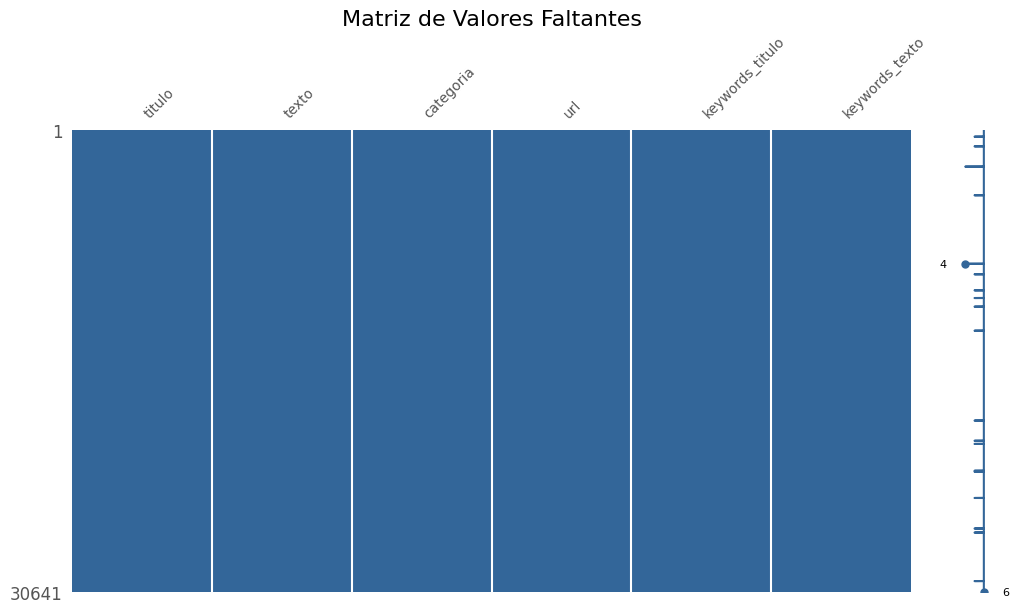

✅ Registros restantes tras limpiar nulos críticos: 30622


In [64]:
# 5.1 Eliminación de duplicados
duplicados_iniciales = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"🗑️ Se eliminaron {duplicados_iniciales} filas duplicadas absolutas.")

# 5.2 Limpieza de espacios en blanco y registros vacíos
# Reemplazamos strings que solo contienen espacios por NaN
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

# 5.3 Conteo de valores nulos
print("\n--- 🔍 Conteo de Valores Nulos ---")
display(df.isnull().sum())

# 5.4 Visualización de nulos (Matriz de missingno)
plt.figure(figsize=(10, 6))
msno.matrix(df, figsize=(12, 6), fontsize=10, color=(0.2, 0.4, 0.6))
plt.title('Matriz de Valores Faltantes', fontsize=16)
plt.show()

# 5.5 Eliminación de registros vacíos críticos
# Si no hay texto o título, el registro no sirve para NLP
df.dropna(subset=['titulo', 'texto'], inplace=True)
print(f"✅ Registros restantes tras limpiar nulos críticos: {df.shape[0]}")


### 6. Limpieza y Normalización de Texto
Limpiamos las columnas de texto, eliminamos HTML oculto (adición de robustez), normalizamos espacios y quitamos caracteres extraños.


In [65]:
def limpiar_texto(texto):
    if pd.isna(texto):
        return texto
    texto = str(texto)
    # Adición: Limpiar etiquetas HTML residuales
    texto = BeautifulSoup(texto, "html.parser").get_text(separator=" ")
    # Limpiar saltos de línea y tabulaciones
    texto = re.sub(r'[\n\t\r]', ' ', texto)
    # Eliminar caracteres especiales repetitivos o no alfanuméricos (mantenemos puntuación básica)
    texto = re.sub(r'[^a-zA-Z0-9\s.,!?¿¡áéíóúÁÉÍÓÚñÑ-]', ' ', texto)
    # Normalizar múltiples espacios
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# El dataset final (EN o ES) solo trae 'titulo' y 'texto' como columnas de texto libre
columnas_texto = ['titulo', 'texto']

print("🧹 Limpiando columnas de texto...")
for col in columnas_texto:
    if col in df.columns:
        df[col] = df[col].apply(limpiar_texto)
        print(f" - Columna '{col}' procesada.")


🧹 Limpiando columnas de texto...
 - Columna 'titulo' procesada.
 - Columna 'texto' procesada.


### 7. Validación de URLs y Verificación de Categorías
Validamos que las URLs tengan un formato correcto y estandarizamos la categoría para evitar duplicidades por mayúsculas/espacios.


In [66]:
# 7.1 Validación de URLs con Regex
# Expresión regular robusta para URLs
url_pattern = re.compile(r'^(https?:\/\/)?([\da-z\.-]+)\.([a-z\.]{2,6})([\/\w \.-]*)*\/?$')

if 'url' in df.columns:
    df['url_valida'] = df['url'].apply(lambda x: bool(url_pattern.match(str(x).strip())) if pd.notnull(x) else False)
    invalidas = (~df['url_valida']).sum()
    print(f"🔗 URLs evaluadas. Se detectaron {invalidas} URLs con formato inválido o nulas.")

# 7.2 Verificación de Categorías
if 'categoria' in df.columns:
    # Estandarizar a minúsculas y quitar espacios
    df['categoria'] = df['categoria'].astype(str).str.lower().str.strip()

    print("\n🏷️ Distribución de Categorías:")
    display(df['categoria'].value_counts())


🔗 URLs evaluadas. Se detectaron 0 URLs con formato inválido o nulas.

🏷️ Distribución de Categorías:


,count
categoria,
data science,4895
frontend,4493
cloud,4389
backend,4379
database,4244
data engineering,4157
devops,4065


### 8. Limpieza de Keywords

Los datasets finales (`dataset_devto_pure_labels_clean_en/es.csv`) no traen columnas de keywords — esta sección se
deja por compatibilidad con el resto del pipeline del equipo (si en el futuro se agregan columnas `keywords_*`, se
limpian automáticamente aquí; si no existen, el paso simplemente no hace nada).

In [67]:
def limpiar_keywords(kw):
    if pd.isna(kw):
        return ""
    kw = str(kw).lower()
    # Eliminar corchetes y comillas
    kw = re.sub(r'[\[\]\'\"]', '', kw)
    # Separar por comas, limpiar espacios y rearmar
    palabras = [word.strip() for word in kw.split(',')]
    # Retornar separadas por coma, omitiendo las vacías
    return ", ".join(filter(None, palabras))

columnas_kw = ['keywords_titulo', 'keywords_texto', 'keywords_titulo_esp', 'keywords_texto_esp']

print("🔑 Limpiando columnas de keywords...")
for col in columnas_kw:
    if col in df.columns:
        df[col] = df[col].apply(limpiar_keywords)
        print(f" - Columna '{col}' procesada.")


🔑 Limpiando columnas de keywords...
 - Columna 'keywords_titulo' procesada.
 - Columna 'keywords_texto' procesada.


### 9. Feature Engineering (Adiciones extra de limpieza)
Calculamos las longitudes del texto. Esto nos sirve para visualizar y también para filtrar **registros anómalos** (textos extremadamente cortos que no aportan al NLP).


In [68]:
# Calcular longitudes
df['longitud_titulo'] = df['titulo'].str.len().fillna(0)
df['longitud_texto'] = df['texto'].str.len().fillna(0)

# Detección de anomalías: Textos muy cortos (< 30 caracteres)
umbral_corto = 30
anomalos = df[df['longitud_texto'] < umbral_corto]
print(f"⚠️ Textos extremadamente cortos detectados (menores a {umbral_corto} caracteres): {len(anomalos)}")

# Filtramos esos textos anómalos para tener un corpus limpio
df = df[df['longitud_texto'] >= umbral_corto]
print(f"✅ Dataset tras filtrar anomalías: {df.shape[0]} registros.")


⚠️ Textos extremadamente cortos detectados (menores a 30 caracteres): 170
✅ Dataset tras filtrar anomalías: 30452 registros.


### 10. Gráficos de Distribución
Visualizamos cómo quedaron nuestras distribuciones tras la limpieza.


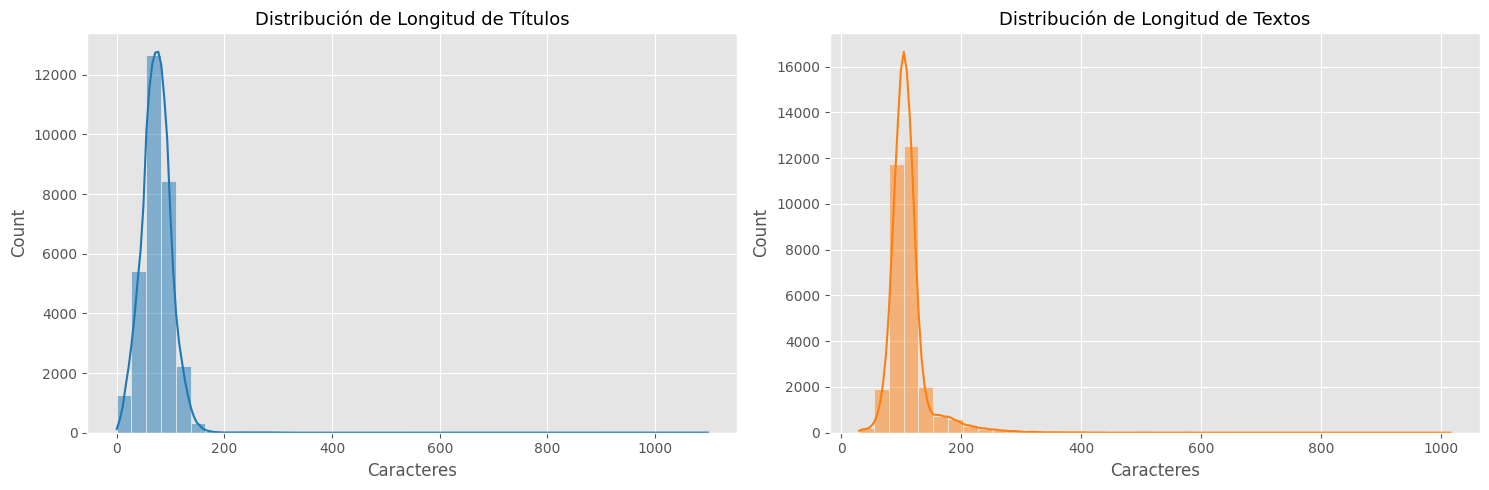

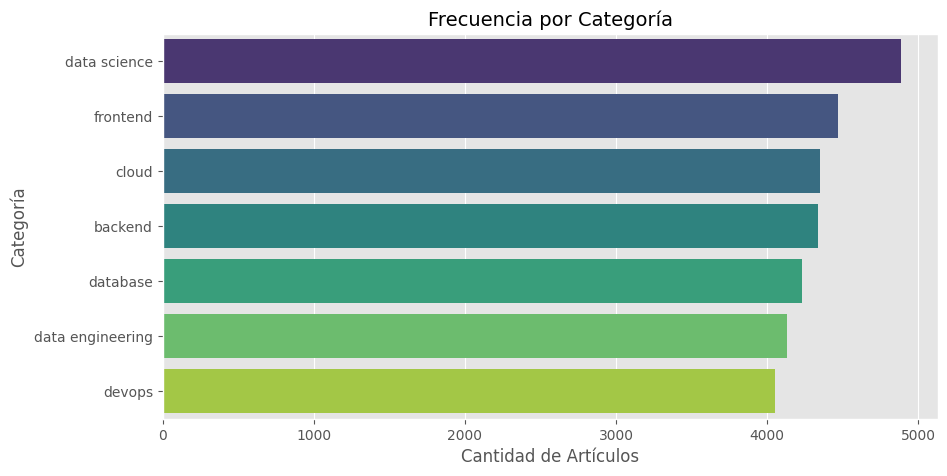

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma de Títulos
sns.histplot(df['longitud_titulo'], bins=40, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribución de Longitud de Títulos', fontsize=13)
axes[0].set_xlabel('Caracteres')

# Histograma de Textos
sns.histplot(df['longitud_texto'], bins=40, kde=True, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Distribución de Longitud de Textos', fontsize=13)
axes[1].set_xlabel('Caracteres')

plt.tight_layout()
plt.show()

# Gráfico de Categorías
if 'categoria' in df.columns:
    plt.figure(figsize=(10, 5))
    conteo = df['categoria'].value_counts()
    sns.barplot(y=conteo.index, x=conteo.values, palette='viridis')
    plt.title('Frecuencia por Categoría', fontsize=14)
    plt.xlabel('Cantidad de Artículos')
    plt.ylabel('Categoría')
    plt.show()


### 11. Exportación de Datos
El dataset está limpio, libre de valores basura, normalizado y listo para modelado (NLP). Exportamos a `CSV` y `Parquet` (este último es más eficiente en lectura/escritura y respeta estrictamente los tipos de datos).

In [70]:
df.columns

Index(['titulo', 'texto', 'categoria', 'url', 'keywords_titulo',
       'keywords_texto', 'url_valida', 'longitud_titulo', 'longitud_texto'],
      dtype='object')

In [71]:
df

,titulo,texto,categoria,url,keywords_titulo,keywords_texto,url_valida,longitud_titulo,longitud_texto
0,"Solon Server Threads Cero-Config Auto-Tuning por núcleos de CPU ioBound, coreThreads, maxThreads","Solon Server Threads Cero-Config Auto-Tuning por núcleos de CPU ioBound, coreThreads,...",backend,https://dev.to/solonjava/solon-server-threads-zero-config-auto-tuning-by-cpu-cores-iobound-corethreads-maxthreads-153a,núcleos,núcleos,True,96,88
1,Por qué mi caché no tiene TTL,"La última vez, escribí sobre el dilema de alimentar especificaciones dispersas a través de múltiples repositorios de IA...",backend,https://dev.to/shunya_shida/why-my-cache-has-no-ttl-oo7,caché,"través, dilema",True,29,122
2,Autenticación de JWT Modelo mental de un ingeniero motor,"Introducción Imagínese que llega a un hotel. En la recepción, muestra su identificación y prueba...",backend,https://dev.to/juma_evans_34e389ef539266/jwt-authentication-a-backend-engineers-mental-model-4a1m,autenticación,"prueba, llega, identificación, hotel",True,56,99
3,Construir contra las API reales no es nada como leer los documentos,"Hace unos meses, empecé a pasar mucho más tiempo trabajando con diferentes APIs. Al principio, yo...",backend,https://dev.to/jan_inteldo/building-against-real-apis-is-nothing-like-reading-the-docs-23g9,"leer, documentos, construir","principio, pasar, hace",True,67,100
4,"Construcción de la lógica de reinicio resiliente en Node.js Retroceso exponencial, Jitter, y interruptores hechos bien","Cada desarrollador de Node.js ha escrito esto en algún momento función async fetchWithRetry url, retries...",backend,https://dev.to/mukesh_13/building-resilient-retry-logic-in-nodejs-exponential-backoff-jitter-and-circuit-breakers-done-279n,"lógica, construcción","nodejs, escrito",True,118,107
...,...,...,...,...,...,...,...,...,...
30636,"Vue3 Como estimar componentes global, alcance e módulos","Léalo en inglés Nesses últimos anos usando Vue como meu framework favorito, acabei esbarrando em...",frontend,https://dev.to/sucodelarangela/vue3-como-estilizar-componentes-global-scoped-e-modules-2igd,"vue3, módulos",léalo,True,55,99
30637,Más allá de la DOM Virtual Potencia concurrente de React para una representación más inteligente de la interfaz de usuario,"El DOM Virtual de React fue una vez la piedra angular de su rendimiento rápido, pero con el lanzamiento de...",frontend,https://dev.to/nshnt/beyond-the-virtual-dom-reacts-concurrent-powers-for-smarter-ui-rendering-2nb3,"usuario, representación, react, interfaz, inteligente, allá","react, lanzamiento",True,122,109
30638,Comprendiendo el patrón de observación en reacción Una guía completa,"Si has estado construyendo aplicaciones de React por un tiempo, es probable que hayas encontrado momentos en los que...",frontend,https://dev.to/alisamir/understanding-observer-pattern-in-react-a-complete-guide-omf,"reacción, patrón, observación, comprendiendo","tiempo, react, probable",True,68,119
30639,Inyectar variables globales sass de next.config.js - variables env sass,Añadir variable global al compilador sass with-next-sass - Este ejemplo oficial de next.js...,frontend,https://dev.to/vavilov2212/inject-sass-global-variables-from-nextconfigjs-sass-env-variables-3nco,nextconfigjs variables env sass,nextjs,True,71,93


In [72]:
# (Opcional) Eliminar las columnas auxiliares creadas si no se necesitan en NLP
# df.drop(columns=['url_valida', 'longitud_titulo', 'longitud_texto'], inplace=True)

archivo_csv = f'dataset_limpio_{IDIOMA}.csv'
archivo_parquet = f'dataset_limpio_{IDIOMA}.parquet'

# Exportar a CSV
#df.to_csv(archivo_csv, index=False, encoding='utf-8') # Guarda en /content/
df.to_csv(f"/content/drive/MyDrive/Adataset_hackathon/{archivo_csv}", sep=';', index=False, encoding='utf-8') # Guarda en Google Drive
df.to_csv(f"/content/sample_data/{archivo_csv}", sep=';', index=False, encoding='utf-8') # Guarda en /content/sample_data/
df.to_csv(f"/content/data/{archivo_csv}", sep=';', index=False, encoding='utf-8') # Guarda en /content/data/

# Exportar a Parquet
#df.to_parquet(archivo_parquet, index=False)
df.to_parquet(archivo_parquet, index=False) # Guarda en /content/
df.to_parquet(f"/content/drive/MyDrive/Adataset_hackathon/{archivo_parquet}", index=False) # Guarda en Google Drive
df.to_parquet(f"/content/sample_data/{archivo_parquet}", index=False) # Guarda en /content/sample_data/
df.to_parquet(f"/content/data/{archivo_parquet}", index=False) # Guarda en /content/data/


print("🎉 ¡Proceso Finalizado con Éxito!")
print(f"Idioma procesado: {IDIOMA.upper()}")
print(f"Dimensiones finales del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")
print(f"Archivos listos para descargar:\n 1. {archivo_csv}\n 2. {archivo_parquet}")

otro_idioma = "es" if IDIOMA == "en" else "en"
print(f"\n➡️ Para generar el archivo del otro idioma: cambia IDIOMA a \"{otro_idioma}\" en la celda de configuracion "
      f"(seccion 2.1) y ejecuta todo el notebook de nuevo (Run All).")

🎉 ¡Proceso Finalizado con Éxito!
Idioma procesado: ES
Dimensiones finales del dataset: 30452 filas y 9 columnas.
Archivos listos para descargar:
 1. dataset_limpio_es.csv
 2. dataset_limpio_es.parquet

➡️ Para generar el archivo del otro idioma: cambia IDIOMA a "en" en la celda de configuracion (seccion 2.1) y ejecuta todo el notebook de nuevo (Run All).


###**TAREA TRELLO: SPRINT-S1_ DS-03_bis: CLASIFICADOR TEXTO (Stop Words a Mejorar)**

https://trello.com/c/eXECPLe5/59-sprint-s1-ds-03bis-clasificador-texto-stop-words-a-mejorar

**Equipo G9-LATAM-Team 04-DataScientist**
- Alan Arce - Data Scientist (trendsinbiomedicine.arcealan@gmail.com)
- Liuber Escalona - Data Scientist (liuberth33@gmail.com)
- Jaime Pradenas - BI Analys (jpraden@gmail.com)

_____________________________________________________________

==========================================================

Desarrollado por:

📌https://github.com/AlanSebastianArce
📌https://www.linkedin.com/in/alansebastianarce

==========================================================

**Stop Words**: completas para inglés y español.
Usado por los notebooks de Colab y por la API de FastAPI.

Lista ampliada de Stop Words:

🟢 ~750 palabras ✅ EN
🔵 ~950 palabras ☑️ ES

Versión optimizada para clasificación de texto
y ordenada alfabeticamente dentro de cada categoria..

Incluye:

- Artículos
- Pronombres
- Verbos comunes (auxiliares + verbos muy frecuentes + conjugaciones)
- Preposiciones
- Conjunciones
- Adverbios comunes
- Cuantificadores
- Posesivos          (solo ES)
- Relativos          (solo ES)
- Números escritos
- Ordinales
- Fracciones
- Meses
- Días
- Estaciones
- Abreviaturas comunes
- Unidades de medida
- Símbolos
- Palabras técnicas NLP
- Demostrativos / tiempo   (solo EN)
- Generales

==========================================================


### STOP_WORDS - INGLES

In [73]:
#STOP_WORDS - INGLES
STOP_WORDS_EN: list[str] = [
    # ── Articulos ──
    "a", "an", "the",
    # ── Pronombres ──
    "anybody", "anyone", "anything", "everybody", "everyone",
    "everything", "he", "her", "hers", "herself", "him", "himself",
    "his", "i", "it", "its", "itself", "me", "mine", "my",
    "myself", "nobody", "nothing", "one", "ones", "oneself", "our",
    "ours", "ourselves", "she", "somebody", "someone", "something",
    "that", "thee", "their", "theirs", "them", "themselves",
    "these", "they", "thine", "this", "those", "thou", "thy", "us",
    "we", "what", "whatever", "which", "whichever", "who",
    "whoever", "whom", "whomever", "whose", "ye", "you", "your",
    "yours", "yourself", "yourselves",
    # ── Verbos comunes ──
    "add", "added", "adding", "adds", "am", "appear", "appeared",
    "appearing", "appears", "are", "ask", "asked", "asking",
    "asks", "be", "became", "become", "becomes", "becoming",
    "been", "began", "begin", "beginning", "begins", "begun",
    "being", "bring", "bringing", "brings", "brought", "call",
    "called", "calling", "calls", "came", "can", "come", "comes",
    "coming", "consider", "considered", "considering", "considers",
    "continue", "continued", "continues", "continuing", "could",
    "dare", "dared", "dares", "daring", "did", "do", "does",
    "doing", "done", "feel", "feeling", "feels", "felt", "find",
    "finding", "finds", "found", "gave", "get", "gets", "getting",
    "give", "given", "gives", "giving", "go", "goes", "going",
    "gone", "got", "gotten", "had", "has", "hast", "hath", "have",
    "having", "hear", "heard", "hearing", "hears", "help",
    "helped", "helping", "helps", "include", "included",
    "includes", "including", "is", "keep", "keeping", "keeps",
    "kept", "knew", "know", "knowing", "known", "knows", "leave",
    "leaves", "leaving", "left", "let", "lets", "letting", "look",
    "looked", "looking", "looks", "lose", "loses", "losing",
    "lost", "made", "make", "makes", "making", "may", "mean",
    "meaning", "means", "meant", "meet", "meeting", "meets", "met",
    "might", "move", "moved", "moves", "moving", "must", "need",
    "needed", "needing", "needs", "ought", "paid", "pay", "paying",
    "pays", "provide", "provided", "provides", "providing", "put",
    "puts", "putting", "ran", "remain", "remained", "remaining",
    "remains", "run", "running", "runs", "said", "saw", "say",
    "saying", "says", "see", "seeing", "seem", "seemed", "seeming",
    "seems", "seen", "sees", "set", "sets", "setting", "shall",
    "should", "show", "showed", "showing", "shown", "shows",
    "stand", "standing", "stands", "start", "started", "starting",
    "starts", "stood", "take", "taken", "takes", "taking", "tell",
    "telling", "tells", "think", "thinking", "thinks", "thought",
    "told", "took", "tried", "tries", "try", "trying", "turn",
    "turned", "turning", "turns", "use", "used", "uses", "using",
    "want", "wanted", "wanting", "wants", "was", "went", "were",
    "will", "work", "worked", "working", "works", "would",
    # ── Preposiciones ──
    "about", "above", "across", "after", "against", "along",
    "amid", "amidst", "among", "amongst", "around", "as", "at",
    "before", "behind", "below", "beneath", "beside", "besides",
    "between", "beyond", "but", "by", "concerning", "despite",
    "down", "during", "except", "excluding", "following", "for",
    "from", "in", "inside", "into", "like", "minus", "near",
    "notwithstanding", "of", "off", "on", "onto", "opposite",
    "out", "outside", "over", "past", "per", "plus", "regarding",
    "round", "save", "since", "than", "through", "throughout",
    "till", "to", "toward", "towards", "under", "underneath",
    "unlike", "until", "unto", "up", "upon", "versus", "via",
    "with", "within", "without",
    # ── Conjunciones ──
    "although", "and", "because", "both", "either", "how",
    "however", "if", "neither", "nor", "once", "or", "so",
    "though", "unless", "when", "whenever", "where", "whereas",
    "wherever", "whether", "while", "yet",
    # ── Adverbios comunes ──
    "absolutely", "actually", "again", "almost", "already", "also",
    "always", "basically", "certainly", "clearly", "completely",
    "constantly", "currently", "definitely", "directly", "easily",
    "entirely", "equally", "especially", "essentially", "even",
    "eventually", "ever", "exactly", "extremely", "fairly",
    "finally", "firstly", "fully", "generally", "gradually",
    "greatly", "hardly", "hence", "here", "highly", "immediately",
    "increasingly", "indeed", "initially", "instead", "just",
    "largely", "lately", "later", "likely", "literally", "mainly",
    "meanwhile", "merely", "mostly", "namely", "naturally",
    "nearly", "necessarily", "never", "nevertheless", "no",
    "nonetheless", "normally", "not", "now", "obviously",
    "occasionally", "often", "only", "otherwise", "particularly",
    "perhaps", "possibly", "presently", "previously", "probably",
    "promptly", "properly", "quickly", "quite", "rather",
    "readily", "really", "recently", "regularly", "relatively",
    "roughly", "seldom", "shortly", "significantly", "similarly",
    "simply", "slightly", "slowly", "somehow", "sometime",
    "sometimes", "somewhat", "somewhere", "soon", "specifically",
    "still", "strongly", "subsequently", "suddenly", "surely",
    "technically", "then", "there", "thoroughly", "too", "totally",
    "truly", "typically", "ultimately", "undoubtedly", "usually",
    "very", "virtually", "widely", "yes",
    # ── Cuantificadores ──
    "all", "another", "any", "certain", "each", "enough", "every",
    "few", "fewer", "fewest", "least", "less", "little", "many",
    "more", "most", "much", "none", "numerous", "other", "plenty",
    "several", "some", "sufficient", "various", "whole",
    # ── Numeros escritos ──
    "billion", "eight", "eighteen", "eighty", "eleven", "fifteen",
    "fifty", "five", "forty", "four", "fourteen", "hundred",
    "million", "nine", "nineteen", "ninety", "seven", "seventeen",
    "seventy", "six", "sixteen", "sixty", "ten", "thirteen",
    "thirty", "thousand", "three", "twelve", "twenty", "two",
    "zero",
    # ── Ordinales ──
    "eighth", "eleventh", "fifth", "final", "first", "former",
    "fourth", "last", "latter", "next", "ninth", "previous",
    "second", "seventh", "sixth", "tenth", "third", "twelfth",
    # ── Fracciones ──
    "double", "half", "quarter", "thrice", "triple", "twice",
    # ── Meses ──
    "apr", "april", "aug", "august", "dec", "december", "feb",
    "february", "jan", "january", "jul", "july", "jun", "june",
    "mar", "march", "nov", "november", "oct", "october", "sep",
    "sept", "september",
    # ── Dias ──
    "fri", "friday", "mon", "monday", "sat", "saturday", "sun",
    "sunday", "thu", "thur", "thurs", "thursday", "tue", "tues",
    "tuesday", "wed", "wednesday",
    # ── Estaciones ──
    "autumn", "fall", "spring", "summer", "winter",
    # ── Abreviaturas comunes ──
    "aka", "approx", "asap", "avg", "cf", "eg", "etc", "fig",
    "fyi", "ie", "max", "min", "misc", "num", "ok", "okay", "pg",
    "pp", "ref", "vol", "vs",
    # ── Unidades de medida ──
    "cm", "ft", "hr", "hrs", "kg", "km", "lb", "lbs", "mg", "mi",
    "ml", "mm", "oz", "pct", "sec", "yd",
    # ── Simbolos ──
    "amp", "percent",
    # ── Palabras tecnicas NLP ──
    "al", "cit", "et", "ibid", "op",
    # ── Demostrativos / tiempo ──
    "afterward", "afterwards", "ago", "beforehand", "early",
    "henceforth", "late", "meantime", "nowadays", "today",
    "tomorrow", "yesterday",
    # ── Generales ──
    "accordingly", "aforementioned", "aforesaid", "altogether",
    "away", "back", "case", "different", "example", "fact",
    "furthermore", "hereby", "herein", "hereof", "hereto",
    "hitherto", "howsoever", "kind", "matter", "moreover",
    "notably", "overall", "part", "point", "purpose", "reason",
    "regard", "respect", "result", "same", "sort", "such",
    "thereafter", "thereby", "therefore", "therein", "thereof",
    "thereto", "thing", "things", "thus", "type", "way", "well",
    "whatsoever", "whereby", "wherein", "whereof",
]


### STOP_WORDS - ESPAÑOL

In [74]:
#Stop_word - ESPAÑOL
STOP_WORDS_ES: list[str] = [
    # ── Articulos ──
    "el", "la", "las", "lo", "los", "un", "una", "unas", "unos",
    # ── Pronombres ──
    "algo", "alguien", "aquel", "aquella", "aquellas", "aquello",
    "aquellos", "conmigo", "consigo", "contigo", "cualesquiera",
    "cualquiera", "ella", "ellas", "ello", "ellos", "esa", "esas",
    "ese", "eso", "esos", "esta", "estas", "este", "esto", "estos",
    "le", "les", "me", "nada", "nadie", "nos", "nosotras",
    "nosotros", "os", "quien", "quienes", "quienquiera", "se",
    "te", "tu", "usted", "ustedes", "vosotras", "vosotros", "yo",
    # ── Verbos comunes ──
    "busca", "buscais", "buscamos", "buscan", "buscar", "buscas",
    "busco", "cree", "creeis", "creemos", "creen", "creer",
    "crees", "crei", "creia", "creiais", "creiamos", "creian",
    "creias", "creimos", "creiste", "creisteis", "creo",
    "creyeron", "creyo", "da", "daba", "dabais", "dabamos",
    "daban", "dabas", "dais", "damos", "dan", "dar", "das", "debe",
    "debeis", "debemos", "deben", "deber", "debes", "debi",
    "debia", "debiais", "debiamos", "debian", "debias", "debieron",
    "debimos", "debio", "debiste", "debisteis", "debo", "decia",
    "deciais", "deciamos", "decian", "decias", "decimos", "decir",
    "decis", "deja", "dejais", "dejamos", "dejan", "dejar",
    "dejas", "dejo", "di", "dice", "dicen", "dices", "dieron",
    "digo", "dije", "dijeron", "dijimos", "dijiste", "dijisteis",
    "dijo", "dimos", "dio", "dira", "diran", "diras", "dire",
    "direis", "diremos", "diste", "disteis", "doy", "encontrais",
    "encontramos", "encontrar", "encuentra", "encuentran",
    "encuentras", "encuentro", "entra", "entrais", "entramos",
    "entran", "entrar", "entras", "entro", "era", "erais",
    "eramos", "eran", "eras", "eres", "es", "estaba", "estabais",
    "estabamos", "estaban", "estabas", "estais", "estamos",
    "estan", "estar", "estoy", "fue", "fueron", "fui", "fuimos",
    "fuiste", "fuisteis", "ha", "habeis", "haber", "habia",
    "habiais", "habiamos", "habian", "habias", "habra", "habran",
    "habras", "habre", "habreis", "habremos", "hace", "haceis",
    "hacemos", "hacen", "hacer", "haces", "hacia", "haciais",
    "haciamos", "hacian", "hacias", "hago", "han", "hara", "haran",
    "haras", "hare", "hareis", "haremos", "has", "he", "hemos",
    "hice", "hicieron", "hicimos", "hiciste", "hicisteis", "hizo",
    "hube", "hubieron", "hubimos", "hubiste", "hubisteis", "hubo",
    "iba", "ibais", "ibamos", "iban", "ibas", "ir", "ira", "iran",
    "iras", "ire", "ireis", "iremos", "llega", "llegais",
    "llegamos", "llegan", "llegar", "llegas", "llego", "lleva",
    "llevais", "llevamos", "llevan", "llevar", "llevas", "llevo",
    "parece", "pareceis", "parecemos", "parecen", "parecer",
    "pareces", "parezco", "pasa", "pasais", "pasamos", "pasan",
    "pasar", "pasas", "paso", "pensais", "pensamos", "pensar",
    "piensa", "piensan", "piensas", "pienso", "podeis", "podemos",
    "poder", "podia", "podiais", "podiamos", "podian", "podias",
    "podra", "podran", "podras", "podre", "podreis", "podremos",
    "pone", "poneis", "ponemos", "ponen", "poner", "pones",
    "pongo", "ponia", "poniais", "poniamos", "ponian", "ponias",
    "pude", "pudieron", "pudimos", "pudiste", "pudisteis", "pudo",
    "puede", "pueden", "puedes", "puedo", "puse", "pusieron",
    "pusimos", "pusiste", "pusisteis", "puso", "quereis",
    "queremos", "querer", "queria", "queriais", "queriamos",
    "querian", "querias", "querra", "querran", "querras", "querre",
    "querreis", "querremos", "quiere", "quieren", "quieres",
    "quiero", "quise", "quisieron", "quisimos", "quisiste",
    "quisisteis", "quiso", "sabe", "sabeis", "sabemos", "saben",
    "saber", "sabes", "sabia", "sabiais", "sabiamos", "sabian",
    "sabias", "sabra", "sabran", "sabras", "sabre", "sabreis",
    "sabremos", "sale", "salen", "sales", "salgo", "salimos",
    "salir", "salis", "seguimos", "seguir", "seguis", "sentimos",
    "sentir", "sentis", "ser", "sera", "seran", "seras", "sere",
    "sereis", "seremos", "siente", "sienten", "sientes", "siento",
    "sigo", "sigue", "siguen", "sigues", "sois", "somos", "son",
    "soy", "supe", "supieron", "supimos", "supiste", "supisteis",
    "supo", "tendra", "tendran", "tendras", "tendre", "tendreis",
    "tendremos", "teneis", "tenemos", "tener", "tengo", "tenia",
    "teniais", "teniamos", "tenian", "tenias", "tiene", "tienen",
    "tienes", "tuve", "tuvieron", "tuvimos", "tuviste",
    "tuvisteis", "tuvo", "va", "vais", "vamos", "van", "vas", "ve",
    "veia", "veiais", "veiamos", "veian", "veias", "veis", "vemos",
    "ven", "veo", "ver", "ves", "vi", "vieron", "vimos", "vio",
    "viste", "visteis", "vive", "viven", "vives", "vivimos",
    "vivir", "vivis", "vivo", "volveis", "volvemos", "volver",
    "voy", "vuelve", "vuelven", "vuelves", "vuelvo",
    # ── Preposiciones ──
    "a", "ante", "bajo", "cabe", "con", "contra", "de", "desde",
    "durante", "en", "entre", "hasta", "mediante", "para", "por",
    "segun", "sin", "sobre", "tras", "via",
    # ── Conjunciones ──
    "ademas", "asi", "aun", "aunque", "bien", "como", "conque",
    "e", "empero", "excepto", "luego", "mas", "mientras", "ni",
    "o", "ora", "pero", "porque", "pues", "que", "salvo", "si",
    "sino", "u", "y",
    # ── Adverbios comunes ──
    "abiertamente", "aca", "ahi", "ahora", "alla", "alli", "antes",
    "aparentemente", "apenas", "aproximadamente", "aqui", "ayer",
    "bastante", "brevemente", "casi", "ciertamente", "claramente",
    "completamente", "constantemente", "cuidadosamente",
    "demasiado", "despues", "directamente", "efectivamente",
    "enseguida", "entonces", "esencialmente", "especialmente",
    "eventualmente", "evidentemente", "exactamente",
    "expresamente", "finalmente", "frecuentemente", "generalmente",
    "gradualmente", "habitualmente", "hoy", "igualmente",
    "incluso", "inicialmente", "inmediatamente", "jamas",
    "justamente", "lentamente", "literalmente", "mal", "manana",
    "mayormente", "meramente", "mucho", "muy", "naturalmente",
    "necesariamente", "no", "normalmente", "nuevamente", "nunca",
    "obviamente", "ocasionalmente", "particularmente", "poco",
    "posiblemente", "precisamente", "previamente",
    "principalmente", "probablemente", "profundamente",
    "prontamente", "pronto", "propiamente", "puntualmente",
    "rapidamente", "raramente", "realmente", "recientemente",
    "regularmente", "relativamente", "repentinamente",
    "seguramente", "sencillamente", "seriamente", "siempre",
    "significativamente", "simplemente", "sinceramente",
    "siquiera", "solamente", "solo", "sumamente", "supuestamente",
    "tambien", "tampoco", "tarde", "todavia", "totalmente",
    "ultimamente", "unicamente", "usualmente", "vagamente",
    "verdaderamente", "ya",
    # ── Cuantificadores ──
    "algun", "alguna", "algunas", "algunos", "ambas", "ambos",
    "bastantes", "cada", "cualquier", "demas", "demasiada",
    "demasiadas", "demasiados", "diversa", "diversas", "diverso",
    "diversos", "harta", "hartas", "harto", "hartos", "ningun",
    "ninguna", "ningunas", "ningunos", "sendas", "sendos", "tanta",
    "tantas", "tanto", "tantos", "toda", "todas", "todo", "todos",
    "varias", "varios",
    # ── Posesivos ──
    "mi", "mia", "mias", "mio", "mios", "mis", "nuestra",
    "nuestras", "nuestro", "nuestros", "su", "sus", "suya",
    "suyas", "suyo", "suyos", "tus", "tuya", "tuyas", "tuyo",
    "tuyos", "vuestra", "vuestras", "vuestro", "vuestros",
    # ── Relativos ──
    "adonde", "cual", "cuales", "cuando", "cuanta", "cuantas",
    "cuanto", "cuantos", "cuya", "cuyas", "cuyo", "cuyos", "donde",
    # ── Numeros escritos ──
    "catorce", "cero", "cien", "ciento", "cinco", "cincuenta",
    "cuarenta", "cuatro", "diecinueve", "dieciocho", "dieciseis",
    "diecisiete", "diez", "doce", "dos", "mil", "millon",
    "millones", "noventa", "nueve", "ochenta", "ocho", "once",
    "quince", "seis", "sesenta", "setenta", "siete", "trece",
    "treinta", "tres", "uno", "veinte",
    # ── Ordinales ──
    "cuarta", "cuartas", "cuarto", "cuartos", "decima", "decimas",
    "decimo", "novena", "novenas", "noveno", "novenos", "octava",
    "octavas", "octavo", "octavos", "penultima", "penultimo",
    "primer", "primera", "primeras", "primero", "primeros",
    "quinta", "quintas", "quinto", "quintos", "segunda",
    "segundas", "segundo", "segundos", "septima", "septimas",
    "septimo", "septimos", "sexta", "sextas", "sexto", "sextos",
    "tercer", "tercera", "terceras", "tercero", "terceros",
    "ultima", "ultimas", "ultimo", "ultimos",
    # ── Fracciones ──
    "doble", "media", "medio", "mitad", "tercio", "triple",
    "veces", "vez",
    # ── Meses ──
    "abr", "abril", "ago", "agosto", "dic", "diciembre", "ene",
    "enero", "feb", "febrero", "jul", "julio", "jun", "junio",
    "mar", "marzo", "mayo", "nov", "noviembre", "oct", "octubre",
    "sep", "sept", "septiembre",
    # ── Dias ──
    "domingo", "jueves", "lunes", "martes", "miercoles", "sabado",
    "viernes",
    # ── Estaciones ──
    "invierno", "otono", "primavera", "verano",
    # ── Abreviaturas comunes ──
    "aa", "afmos", "aprox", "cia", "dr", "dra", "ej", "etc", "fig",
    "max", "min", "num", "pag", "pags", "pej", "prom", "ref", "sa",
    "sr", "sra", "srl", "srta", "ud", "uds", "vol", "vs",
    # ── Unidades de medida ──
    "cm", "gr", "grs", "hrs", "hs", "kg", "km", "lb", "lbs", "lt",
    "lts", "mg", "ml", "mm", "mts", "oz", "seg",
    # ── Simbolos ──
    "arroba", "etcetera", "porciento",
    # ── Palabras tecnicas NLP ──
    "aka", "cit", "ibid", "op",
    # ── Generales ──
    "acerca", "actual", "actuales", "area", "areas", "aspecto",
    "aspectos", "cierta", "ciertas", "cierto", "ciertos", "citado",
    "condicion", "condiciones", "consiguiente", "correspondiente",
    "correspondientes", "cosa", "cosas", "cuestion", "dicha",
    "dichas", "dicho", "dichos", "embargo", "fin", "forma",
    "general", "gran", "grande", "grandes", "grupo", "grupos",
    "lugar", "manera", "mayor", "mejor", "mencionado", "menor",
    "misma", "mismas", "mismo", "mismos", "modo", "momento",
    "momentos", "nivel", "niveles", "nueva", "nuevas", "nuevo",
    "nuevos", "numero", "otra", "otras", "otro", "otros", "parte",
    "peor", "pesar", "presente", "proceso", "procesos", "propia",
    "propias", "propio", "propios", "punto", "puntos", "razon",
    "razones", "referido", "respecto", "semejante", "semejantes",
    "situacion", "situaciones", "suma", "sumas", "sumo", "sumos",
    "susodicho", "tal", "tales", "tiempo", "tipo", "trata",
    "tratar", "traves",
]

_______________________

**###TAREA TRELLO: SPRINT-S1_DS-03: Entrenar modelo TF-IDF + Regresión Logística**

https://trello.com/c/7iVrpKNj/61-sprint-s1ds-03-entrenar-modelo-tf-idf-regresi%C3%B3n-log%C3%ADstica

**Equipo G9-LATAM-Team 04-DataScientist**
- Alan Arce - Data Scientist (trendsinbiomedicine.arcealan@gmail.com)
- Liuber Escalona - Data Scientist (liuberth33@gmail.com)
- Jaime Pradenas - BI Analys (jpraden@gmail.com)

_____________________________________________________________


# Vectorizacion TF-IDF + Entrenamiento del Modelo

**Proyecto:** TechKnowledge API -- Hackathon ONE Alura Latam x Oracle

**Objetivo:** Vectorizar el corpus de contenidos tecnicos con TF-IDF (incluyendo bigramas), entrenar un clasificador
de Regresion Logistica, evaluar su desempeno con metricas estandar y serializar el modelo final para el equipo de Backend.


**Como correr este notebook para los 2 idiomas:** el notebook entrena **un modelo por idioma, en corridas separadas**.
Corre todo el notebook (`Run All`) con `IDIOMA = "en"` -> obtienes el modelo en ingles serializado en `../model/en/`.
Despues cambia `IDIOMA = "es"` y corre todo el notebook de nuevo (`Run All`) -> obtienes el modelo en espanol en
`../model/es/`. No se cargan ni se mezclan los dos idiomas en la misma corrida.

Este notebook espera como entrada el `dataset_limpio_<idioma>.csv` que genera `Limpieza_Datos_NLP.ipynb` (correlo
primero, para el mismo idioma).


**Contenido de este notebook:**
- [x] Seleccionar idioma (EN/ES) y cargar el dataset limpio correspondiente
- [x] Construir el corpus (`titulo` + `texto`)
- [x] Train/test split estratificado
- [x] Balanceo de clases por oversampling (solo en el set de entrenamiento, para evitar fuga de datos)
- [x] Vectorizacion TF-IDF con bigramas (stopwords en ingles o espanol segun el idioma seleccionado)
- [x] Entrenamiento de Regresion Logistica
- [x] Evaluacion: accuracy, precision, recall, F1-score, matriz de confusion
- [x] Serializacion del modelo (`joblib`), separada por idioma


## 0. Configuracion para Google Colab

Si estas corriendo este notebook en **Google Colab**, ejecuta esta celda para subir el dataset directamente
(omitela si lo estas corriendo localmente con el archivo ya en `../data/`).

In [ ]:
# Descomenta estas lineas si estas en Google Colab y necesitas subir el CSV manualmente
# (sube el dataset_limpio_<idioma>.csv que corresponda al IDIOMA que vas a procesar en esta corrida)
#from google.colab import files
#uploaded = files.upload()


In [75]:
#Carga archivo desde el  `../data/`). o
import os

# Selecciona el idioma a procesar: "en" (ingles) o "es" (espanol)
IDIOMA = "es"  # cambiar a "es" para procesar la version en espanol

archivos_entrada = {
    "en": "dataset_limpio_en.csv",
    "es": "dataset_limpio_es.csv",
}
assert IDIOMA in archivos_entrada, "IDIOMA debe ser 'en' o 'es'"

print(f"✅ Idioma seleccionado: {IDIOMA.upper()}")
print(f"Archivo de entrada: {archivos_entrada[IDIOMA]}")

# Carga del CSV (busca primero en ../data/, si no existe intenta /content/ para Google Colab)
nombre_archivo = archivos_entrada[IDIOMA]

os.makedirs("data", exist_ok=True)
#df = pd.read_csv("/content/drive/MyDrive/Adataset_hackathon/dataset_devto_pure_labels_clean_en.csv", sep=';', encoding='utf-8-sig')

try:
    file_path = f"/content/drive/MyDrive/Adataset_hackathon/{nombre_archivo}"
    df = pd.read_csv(file_path, sep=';', encoding='utf-8-sig')
except FileNotFoundError:
    file_path = f"/content/data/{nombre_archivo}"
    df = pd.read_csv(file_path, sep=';', encoding='utf-8-sig')
except FileNotFoundError:
    file_path = f"/content/sample_data/{nombre_archivo}"
    df = pd.read_csv(file_path, sep=';',encoding='utf-8-sig')

print(f"✅ Dataset cargado exitosamente desde: {file_path}")
print(f"📊 Dimensiones iniciales: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()


✅ Idioma seleccionado: ES
Archivo de entrada: dataset_limpio_es.csv
✅ Dataset cargado exitosamente desde: /content/drive/MyDrive/Adataset_hackathon/dataset_limpio_es.csv
📊 Dimensiones iniciales: 30452 filas y 9 columnas.


,titulo,texto,categoria,url,keywords_titulo,keywords_texto,url_valida,longitud_titulo,longitud_texto
0,"Solon Server Threads Cero-Config Auto-Tuning por núcleos de CPU ioBound, coreThreads, maxThreads","Solon Server Threads Cero-Config Auto-Tuning por núcleos de CPU ioBound, coreThreads,...",backend,https://dev.to/solonjava/solon-server-threads-zero-config-auto-tuning-by-cpu-cores-iobound-corethreads-maxthreads-153a,núcleos,núcleos,True,96,88
1,Por qué mi caché no tiene TTL,"La última vez, escribí sobre el dilema de alimentar especificaciones dispersas a través de múltiples repositorios de IA...",backend,https://dev.to/shunya_shida/why-my-cache-has-no-ttl-oo7,caché,"través, dilema",True,29,122
2,Autenticación de JWT Modelo mental de un ingeniero motor,"Introducción Imagínese que llega a un hotel. En la recepción, muestra su identificación y prueba...",backend,https://dev.to/juma_evans_34e389ef539266/jwt-authentication-a-backend-engineers-mental-model-4a1m,autenticación,"prueba, llega, identificación, hotel",True,56,99
3,Construir contra las API reales no es nada como leer los documentos,"Hace unos meses, empecé a pasar mucho más tiempo trabajando con diferentes APIs. Al principio, yo...",backend,https://dev.to/jan_inteldo/building-against-real-apis-is-nothing-like-reading-the-docs-23g9,"leer, documentos, construir","principio, pasar, hace",True,67,100
4,"Construcción de la lógica de reinicio resiliente en Node.js Retroceso exponencial, Jitter, y interruptores hechos bien","Cada desarrollador de Node.js ha escrito esto en algún momento función async fetchWithRetry url, retries...",backend,https://dev.to/mukesh_13/building-resilient-retry-logic-in-nodejs-exponential-backoff-jitter-and-circuit-breakers-done-279n,"lógica, construcción","nodejs, escrito",True,118,107


## 1. Importar librerias

In [76]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

pd.set_option('display.max_colwidth', 100)


### 1.1 Seleccion de idioma

Este notebook entrena un modelo a la vez. Cambia `IDIOMA` a `"en"` o `"es"` y ejecuta todo el notebook (`Run All`)
para entrenar y serializar el modelo de ese idioma. Para tener los dos modelos (EN y ES), se corre el notebook dos
veces, una por idioma -- son entrenamientos independientes, no se combinan los datos de los dos idiomas.



In [77]:
# Selecciona el idioma a entrenar: "en" (ingles) o "es" (espanol)
IDIOMA = "es"  # cambiar a "es" para entrenar el modelo en espanol

archivos_entrada = {
    "en": "dataset_limpio_en.csv",
    "es": "dataset_limpio_es.csv",
}
assert IDIOMA in archivos_entrada, "IDIOMA debe ser 'en' o 'es'"

# Stopwords: se importan desde el modulo compartido del repo (shared/stop_words.py),
# curado por el equipo (~750 palabras EN / ~950 ES) -- una sola fuente de verdad,
# usada tanto por los notebooks de Colab como por la API de FastAPI.
# Se valido que mejora accuracy y confianza de forma consistente en EN y ES
# respecto a la lista anterior (ver comparacion en el resumen del equipo).
!curl -sL -o shared_stop_words.py "https://raw.githubusercontent.com/No-Country-simulation/g9-latam-team-04-esp/develop/shared/stop_words.py"
from shared_stop_words import STOP_WORDS_EN, STOP_WORDS_ES

stop_words = STOP_WORDS_EN if IDIOMA == "en" else STOP_WORDS_ES

print(f"Idioma seleccionado: {IDIOMA.upper()}")
print(f"Archivo de entrada: {archivos_entrada[IDIOMA]}")
print(f"Stopwords cargadas: {len(stop_words)} palabras ({'EN' if IDIOMA == 'en' else 'ES'})")


Idioma seleccionado: ES
Archivo de entrada: dataset_limpio_es.csv
Stopwords cargadas: 946 palabras (ES)


## 2. Cargar el dataset limpio

---



Cargamos `dataset_limpio.csv`. Este archivo ya contiene, para cada contenido: titulo, texto, categoria,
ademas de metadatos adicionales (keywords, longitud, url) generados en pasos previos del equipo.

In [78]:
nombre_archivo = archivos_entrada[IDIOMA]

try:
    file_path = f"/content/sample_data/{nombre_archivo}"
    df = pd.read_csv(file_path, sep=';')
except FileNotFoundError:
    file_path = f"/content/data/{nombre_archivo}"
    df = pd.read_csv(file_path, sep=';')
except FileNotFoundError:
    file_path = f"/content/drive/MyDrive/Adataset_hackathon/{nombre_archivo}"
    df = pd.read_csv(file_path, sep=';')

print(f"Idioma: {IDIOMA.upper()}")
print(f"Dataset cargado desde: {file_path}")
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas disponibles: {df.columns.tolist()}")
df.head(3)


Idioma: ES
Dataset cargado desde: /content/sample_data/dataset_limpio_es.csv
Dimensiones del dataset: 30452 filas x 9 columnas

Columnas disponibles: ['titulo', 'texto', 'categoria', 'url', 'keywords_titulo', 'keywords_texto', 'url_valida', 'longitud_titulo', 'longitud_texto']


,titulo,texto,categoria,url,keywords_titulo,keywords_texto,url_valida,longitud_titulo,longitud_texto
0,"Solon Server Threads Cero-Config Auto-Tuning por núcleos de CPU ioBound, coreThreads, maxThreads","Solon Server Threads Cero-Config Auto-Tuning por núcleos de CPU ioBound, coreThreads,...",backend,https://dev.to/solonjava/solon-server-threads-zero-config-auto-tuning-by-cpu-cores-iobound-coret...,núcleos,núcleos,True,96,88
1,Por qué mi caché no tiene TTL,"La última vez, escribí sobre el dilema de alimentar especificaciones dispersas a través de múlti...",backend,https://dev.to/shunya_shida/why-my-cache-has-no-ttl-oo7,caché,"través, dilema",True,29,122
2,Autenticación de JWT Modelo mental de un ingeniero motor,"Introducción Imagínese que llega a un hotel. En la recepción, muestra su identificación y prueba...",backend,https://dev.to/juma_evans_34e389ef539266/jwt-authentication-a-backend-engineers-mental-model-4a1m,autenticación,"prueba, llega, identificación, hotel",True,56,99


In [79]:
# Verificamos la distribucion de categorias antes de modelar
print(df['categoria'].value_counts())
print(f"\nTotal de categorias: {df['categoria'].nunique()}")

categoria
data science        4885
frontend            4467
cloud               4350
backend             4337
database            4230
data engineering    4129
devops              4054
Name: count, dtype: int64

Total de categorias: 7


In [80]:
# Eliminamos filas con titulo o texto nulo (buena practica antes de construir el corpus)
filas_antes = len(df)
df = df.dropna(subset=['titulo', 'texto']).reset_index(drop=True)
print(f"Filas antes: {filas_antes} | Filas despues de quitar nulos: {len(df)}")

Filas antes: 30452 | Filas despues de quitar nulos: 30449


## 3. Construir el corpus (`titulo` + `texto`)

Combinamos titulo y texto en una sola columna de texto (`corpus`), que sera la entrada para la vectorizacion.
El titulo suele contener palabras muy representativas de la categoria, por lo que enriquece la representacion final.

In [81]:
df['corpus'] = (df['titulo'].astype(str) + ' ' + df['texto'].astype(str)).str.lower()

df[['titulo', 'texto', 'corpus']].head(3)

,titulo,texto,corpus
0,"Solon Server Threads Cero-Config Auto-Tuning por núcleos de CPU ioBound, coreThreads, maxThreads","Solon Server Threads Cero-Config Auto-Tuning por núcleos de CPU ioBound, coreThreads,...","solon server threads cero-config auto-tuning por núcleos de cpu iobound, corethreads, maxthreads..."
1,Por qué mi caché no tiene TTL,"La última vez, escribí sobre el dilema de alimentar especificaciones dispersas a través de múlti...","por qué mi caché no tiene ttl la última vez, escribí sobre el dilema de alimentar especificacion..."
2,Autenticación de JWT Modelo mental de un ingeniero motor,"Introducción Imagínese que llega a un hotel. En la recepción, muestra su identificación y prueba...",autenticación de jwt modelo mental de un ingeniero motor introducción imagínese que llega a un h...


## 4. Division train/test (estratificada)

Usamos `stratify=y` para asegurar que la proporcion de cada categoria se mantenga igual tanto en el set de
entrenamiento como en el de prueba -- esto es clave cuando hay mas de 2 clases, para que la evaluacion sea representativa.

In [82]:
X = df['corpus']
y = df['categoria']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} ejemplos")
print(f"Prueba: {X_test.shape[0]} ejemplos")
print("\nDistribucion en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))


Entrenamiento: 24359 ejemplos
Prueba: 6090 ejemplos

Distribucion en entrenamiento:
categoria
data science       0.160
frontend           0.147
cloud              0.143
backend            0.142
database           0.139
data engineering   0.136
devops             0.133
Name: proportion, dtype: float64


## 4.1 Balanceo de clases por oversampling (solo en train)

Las categorias no tienen exactamente el mismo numero de ejemplos (ej. `frontend` tiene mas articulos que `cloud`).
Para que el modelo no aprenda a favorecer las categorias mayoritarias, sobremuestreamos (con reemplazo) el set de
**entrenamiento** hasta que todas las categorias tengan la misma cantidad de ejemplos que la categoria mas grande.

**Importante:** esto se aplica *solo* sobre `X_train`/`y_train`, nunca sobre el set de prueba -- balancear el test
distorsionaria la evaluacion, ya que dejaria de reflejar la distribucion real de categorias.

In [83]:
train_df = pd.DataFrame({"corpus": X_train.values, "categoria": y_train.values})
max_size = train_df["categoria"].value_counts().max()

balanced_parts = []
for categoria, grupo in train_df.groupby("categoria"):
    balanced_parts.append(grupo.sample(n=max_size, replace=True, random_state=42))

train_balanced = pd.concat(balanced_parts).sample(frac=1, random_state=42).reset_index(drop=True)

X_train = train_balanced["corpus"]
y_train = train_balanced["categoria"]

print("Distribucion en entrenamiento tras el balanceo:")
print(y_train.value_counts())


Distribucion en entrenamiento tras el balanceo:
categoria
database            3908
cloud               3908
backend             3908
devops              3908
data science        3908
frontend            3908
data engineering    3908
Name: count, dtype: int64


## 5. Vectorizacion TF-IDF con bigramas

Configuramos el vectorizador con:
- `ngram_range=(1, 2)`: incluye palabras sueltas (unigramas) **y** pares de palabras (bigramas, ej. "api rest",
  "machine learning"), lo que ayuda al modelo a capturar terminos tecnicos compuestos como una sola unidad de significado.
- `max_features=5000`: limita el vocabulario a las 5000 palabras/bigramas mas relevantes, evitando ruido y
  sobrecarga computacional.
- `min_df=3`: ignora terminos que aparecen en menos de 3 documentos (reduce ruido de palabras muy raras).
- `stop_words`: segun el `IDIOMA` seleccionado en la celda de configuracion -- `'english'` (lista nativa de
  scikit-learn) o `SPANISH_STOPWORDS` (lista propia, definida en la celda de configuracion).

**Importante:** el vectorizador se ajusta (`fit`) solo con los datos de entrenamiento ya balanceados, y luego se
aplica (`transform`) a los datos de prueba -- nunca al reves, para evitar fuga de informacion (data leakage).

In [84]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=3,
    stop_words=stop_words
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Forma de la matriz TF-IDF (entrenamiento): {X_train_tfidf.shape}")
print(f"Forma de la matriz TF-IDF (prueba): {X_test_tfidf.shape}")

Forma de la matriz TF-IDF (entrenamiento): (27356, 5000)
Forma de la matriz TF-IDF (prueba): (6090, 5000)


In [85]:
# Vistazo a algunos terminos (unigramas y bigramas) aprendidos por el vectorizador
vocab = vectorizer.get_feature_names_out()
bigramas = [t for t in vocab if ' ' in t]

print(f"Total de terminos en el vocabulario: {len(vocab)}")
print(f"Total de bigramas incluidos: {len(bigramas)}")
print("\nEjemplos de bigramas detectados:")
print(bigramas[:15])


Total de terminos en el vocabulario: 5000
Total de bigramas incluidos: 1316

Ejemplos de bigramas detectados:
['06 25', '0h detrás', '10 000', '10 5h', '10 mejores', '10 minutos', '100 días', '100 partidos', '15 3h', '15 4h', '15 partes', '180 días', '1h detrás', '20 minutos', '2026 06']


## 6. Entrenamiento del modelo (Regresion Logistica)

Usamos `class_weight='balanced'` para que el modelo compense automaticamente cualquier ligero desbalance entre
categorias, dando mas peso relativo a las clases con menos ejemplos.

In [86]:
modelo = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=1.0,
    random_state=42
)

modelo.fit(X_train_tfidf, y_train)
print("Modelo entrenado correctamente.")
print(f"Categorias aprendidas: {modelo.classes_.tolist()}")

Modelo entrenado correctamente.
Categorias aprendidas: ['backend', 'cloud', 'data engineering', 'data science', 'database', 'devops', 'frontend']


## 7. Evaluacion del modelo

### 7.1 Predicciones y Accuracy

In [88]:
y_pred = modelo.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy en el set de prueba: {accuracy:.4f} ({accuracy*100:.2f}%)")

Accuracy en el set de prueba: 0.6530 (65.30%)


### 7.2 Reporte de clasificacion (precision, recall, F1-score por categoria)

In [89]:
print(classification_report(y_test, y_pred))


                  precision    recall  f1-score   support

         backend       0.59      0.60      0.60       867
           cloud       0.68      0.65      0.67       870
data engineering       0.53      0.53      0.53       826
    data science       0.76      0.75      0.76       977
        database       0.72      0.70      0.71       846
          devops       0.48      0.52      0.50       811
        frontend       0.81      0.78      0.79       893

        accuracy                           0.65      6090
       macro avg       0.65      0.65      0.65      6090
    weighted avg       0.66      0.65      0.65      6090



### 7.3 Matriz de confusion

Muestra, para cada categoria real (filas), cuantos ejemplos fueron clasificados en cada categoria predicha (columnas).
La diagonal principal representa los aciertos; los valores fuera de la diagonal muestran en que categorias se confunde el modelo.

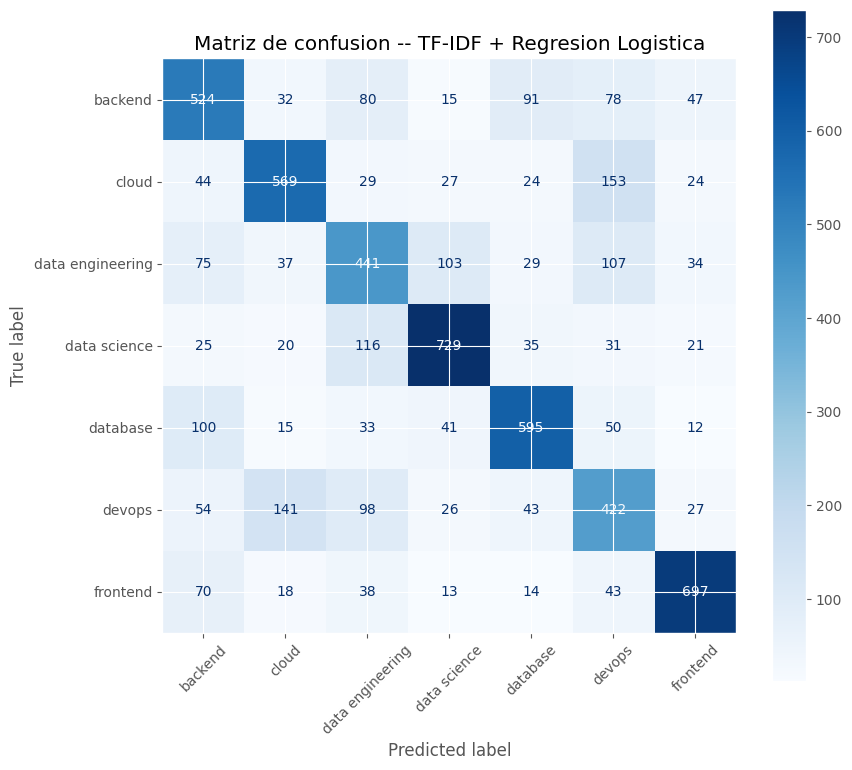

In [90]:
fig, ax = plt.subplots(figsize=(9, 8))
cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=True)
plt.title('Matriz de confusion -- TF-IDF + Regresion Logistica')
plt.tight_layout()
plt.show()


### Análisis Detallado de la Matriz de Confusión para Errores entre Categorías

La matriz de confusión es una herramienta visual muy potente para entender el rendimiento de nuestro modelo, especialmente en un problema de clasificación multiclase como este. Cada fila de la matriz representa las clases reales (lo que el artículo *realmente* es), mientras que cada columna representa las clases predichas por el modelo.

*   **Diagonal Principal (valores más altos):** Estos son los casos donde el modelo predijo correctamente la categoría. Cuanto más altos sean estos valores, mejor es el rendimiento del modelo para esa categoría específica.

*   **Valores Fuera de la Diagonal (errores de clasificación):** Aquí es donde el modelo se equivoca. Observar estos valores nos permite identificar:
    *   **Confusiones comunes:** Si hay un número significativo en la intersección de una fila `X` y una columna `Y` (donde `X` no es igual a `Y`), significa que el modelo tiende a clasificar artículos de la categoría real `X` como si fueran de la categoría `Y`. Por ejemplo, un valor alto en la fila 'cloud' y columna 'devops' indicaría que muchos artículos de 'cloud' son confundidos con 'devops'.
    *   **Categorías problemáticas:** Las filas con muchos valores altos fuera de la diagonal indican categorías que el modelo tiene dificultades para identificar correctamente.
    *   **Similitud semántica:** A menudo, las confusiones ocurren entre categorías que son semánticamente cercanas (por ejemplo, 'data engineering' y 'data science', o 'backend' y 'devops'). Esto es normal y sugiere áreas donde los contenidos pueden tener vocabulario o temas superpuestos.

**Para interpretar tu matriz de confusión actual (`cm`):**

- **Identifica los errores más frecuentes:** Busca los números más grandes que NO estén en la diagonal principal. Por ejemplo, en tu matriz, puedes ver que:
    - En la fila 'cloud', hay 143 artículos clasificados erróneamente como 'devops'. Esto sugiere que el modelo confunde con frecuencia los artículos de la nube con los de DevOps.
    - En la fila 'data engineering', hay 80 artículos clasificados como 'data science'. Esto indica una confusión entre estas dos categorías, lo cual es esperable dada su naturaleza a veces superpuesta.
    - En la fila 'backend', hay 92 artículos clasificados como 'database'.

Estos errores específicos pueden guiar tus próximas acciones, como revisar los textos de esas categorías para entender las similitudes, o considerar enriquecer las características de esas clases.

### Análisis de Artículos Mal Clasificados para 'Data Engineering'

Para profundizar en los errores de clasificación de la categoría 'data engineering', es útil revisar directamente los artículos que el modelo predijo incorrectamente. Esto nos ayudará a identificar:

*   **Similitudes inesperadas**: ¿Hay términos o temas en estos artículos de 'data engineering' que los hacen parecerse a otras categorías?
*   **Ambigüedad**: ¿El contenido es realmente ambiguo o podría interpretarse de múltiples maneras?
*   **Necesidad de características más distintivas**: ¿Faltan palabras clave o frases que diferencien claramente 'data engineering' de otras categorías, especialmente de 'data science' o 'devops'?

In [91]:
import pandas as pd

# Crear un DataFrame para un análisis más sencillo de los resultados de la prueba
results_df = pd.DataFrame({
    'texto': X_test,
    'categoria_real': y_test,
    'categoria_predicha': y_pred
})

# Filtrar artículos donde la categoría real es 'data engineering' pero fue mal clasificada
misclassified_data_engineering = results_df[
    (results_df['categoria_real'] == 'data engineering') &
    (results_df['categoria_real'] != results_df['categoria_predicha'])
]

print(f"Total de artículos de 'data engineering' mal clasificados: {len(misclassified_data_engineering)}\n")

# Mostrar una muestra de los artículos mal clasificados
# pd.set_option('display.max_colwidth', None) # Descomentar para ver el texto completo si es necesario

print("Artículos de 'data engineering' mal clasificados (muestra):\n")
display(misclassified_data_engineering.head(10))

Total de artículos de 'data engineering' mal clasificados: 385

Artículos de 'data engineering' mal clasificados (muestra):



,texto,categoria_real,categoria_predicha
11676,su tubería está 29.1h detrás captura de los plomos de los sentimientos de negocio con pulsobit s...,data engineering,data science
10499,su tubería está 27.8h detrás capturando los plomos del sentimiento robótico con pulsobit su mode...,data engineering,data science
8769,los ingenieros más inteligentes que conozco tienen miedo de decidir por qué los ingenieros más i...,data engineering,data science
11031,12 mejores plataformas para comprar cuenta vieja tiktok en granel el ... comprar cuentas antigua...,data engineering,cloud
9226,la junta de brida abovedada por qué los pernos llevan mucho más que la presión una articulación ...,data engineering,backend
9011,flushing hidráulico reynolds cálculo de números y limpieza trending calculando si estás logrando...,data engineering,data science
9704,atlassian incendia 1.600 ingenieros para apostar todo en ia - el nuevo libro de jugadas mira el ...,data engineering,devops
10221,"interpretación del oleoducto laravel con ejemplo oye artisan, hoy aprendemos sobre el diseño de ...",data engineering,backend
12117,pantalla de punto de venta fabricante en delhi pantallas personalizadas de pos por posmplay punt...,data engineering,backend
11425,"fp16 no sólo pierde precisión, pierde rango gradientes de flujo inferior a cero, y la pérdida de...",data engineering,frontend



### 7.4 Probabilidad de confianza en las predicciones

El campo `probabilidad` que exige el JSON de salida de la API corresponde a la probabilidad maxima que el modelo
asigna a la clase predicha (`predict_proba`). Ejemplos del set de prueba.

In [92]:
probabilidades = modelo.predict_proba(X_test_tfidf)

# Tomamos 5 ejemplos al azar del set de prueba para inspeccionar
muestra_idx = np.random.RandomState(42).choice(len(X_test), size=5, replace=False)

for i in muestra_idx:
    texto_original = X_test.iloc[i][:80] + "..."
    categoria_real = y_test.iloc[i]
    categoria_predicha = y_pred[i]
    prob_max = probabilidades[i].max()

    print(f"Texto: {texto_original}")
    print(f"  Real: {categoria_real} | Predicho: {categoria_predicha} | Confianza: {prob_max:.2%}")
    print("-" * 90)


Texto: cómo la ubicación del servidor afecta el rendimiento del sitio web ¿sabías que d...
  Real: cloud | Predicho: frontend | Confianza: 39.05%
------------------------------------------------------------------------------------------
Texto: api legible y a prueba de fugas con abstracción de costes cero. uno de los retos...
  Real: backend | Predicho: backend | Confianza: 51.30%
------------------------------------------------------------------------------------------
Texto: seo samjho una herramienta sencilla para entender las etiquetas de seo construí ...
  Real: frontend | Predicho: data engineering | Confianza: 52.92%
------------------------------------------------------------------------------------------
Texto: gmf core un motor de recomendación y decisión de código abierto para mercados mi...
  Real: backend | Predicho: data engineering | Confianza: 36.31%
------------------------------------------------------------------------------------------
Texto: iluminación de precisió

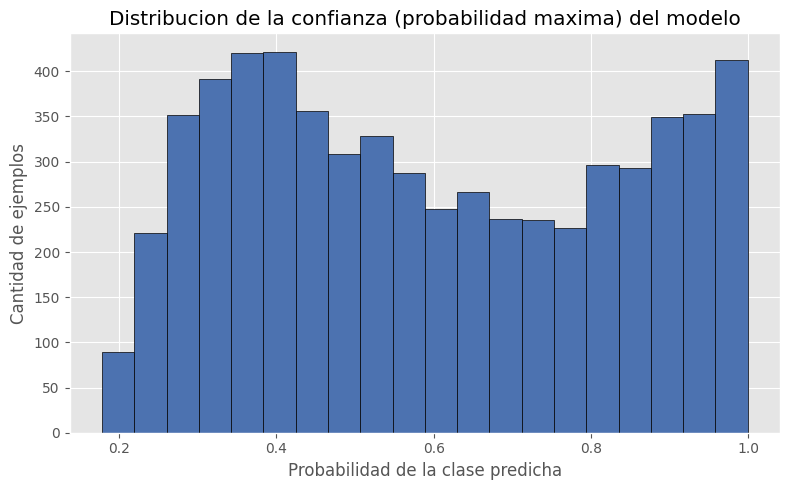

Confianza promedio: 59.75%
Confianza minima: 17.79%
Confianza maxima: 99.96%


In [93]:
# Distribucion general de la confianza del modelo en sus predicciones
confianza_max = probabilidades.max(axis=1)

plt.figure(figsize=(8, 5))
plt.hist(confianza_max, bins=20, color='#4C72B0', edgecolor='black')
plt.title('Distribucion de la confianza (probabilidad maxima) del modelo')
plt.xlabel('Probabilidad de la clase predicha')
plt.ylabel('Cantidad de ejemplos')
plt.tight_layout()
plt.show()

print(f"Confianza promedio: {confianza_max.mean():.2%}")
print(f"Confianza minima: {confianza_max.min():.2%}")
print(f"Confianza maxima: {confianza_max.max():.2%}")


### Visualización PCA de Artículos Mal Clasificados

Para obtener una visión general de cómo se distribuyen los artículos en el espacio de características y cómo se agrupan las clasificaciones correctas e incorrectas, realizaremos una Reducción de Dimensionalidad (PCA) y visualizaremos los resultados en un gráfico de dispersión.

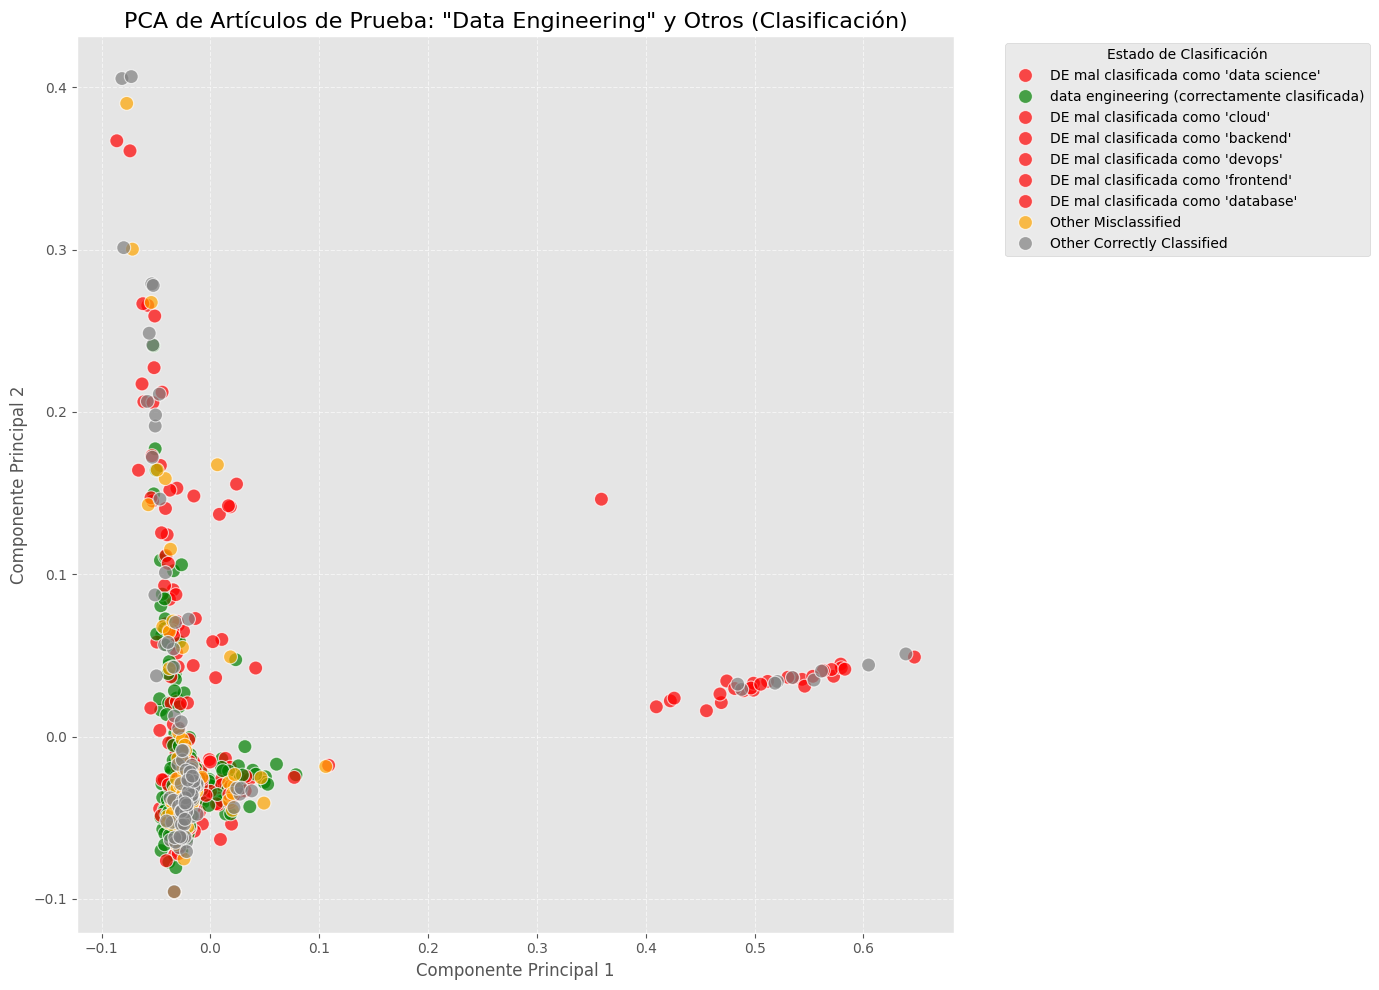

In [94]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reducir la dimensionalidad de X_test_tfidf a 2 componentes usando PCA
pca = PCA(n_components=2, random_state=42)
reduced_features = pca.fit_transform(X_test_tfidf.toarray())

# Crear un DataFrame con los componentes PCA y las etiquetas reales/predichas
plot_df = pd.DataFrame(reduced_features, columns=['PC1', 'PC2'])
plot_df['categoria_real'] = y_test.reset_index(drop=True)
plot_df['categoria_predicha'] = y_pred

# Filtrar solo los artículos donde la categoría real es 'data engineering'
de_articles_df = plot_df[plot_df['categoria_real'] == 'data engineering'].copy()

# Añadir una columna para el estado de clasificación para los artículos de 'data engineering'
de_articles_df['classification_status'] = de_articles_df.apply(
    lambda row: 'data engineering (correctamente clasificada)' if row['categoria_real'] == row['categoria_predicha']
    else f"DE mal clasificada como '{row['categoria_predicha']}'", axis=1
)

# Identificar otros artículos mal clasificados (para mostrar solo unos pocos si hay muchos)
misclassified_others = plot_df[
    (plot_df['categoria_real'] != plot_df['categoria_predicha']) &
    (plot_df['categoria_real'] != 'data engineering')
].sample(min(100, len(plot_df[
    (plot_df['categoria_real'] != plot_df['categoria_predicha']) &
    (plot_df['categoria_real'] != 'data engineering')
])), random_state=42)

# Artículos correctamente clasificados que no son 'data engineering'
correctly_classified_others = plot_df[
    (plot_df['categoria_real'] == plot_df['categoria_predicha']) &
    (plot_df['categoria_real'] != 'data engineering')
].sample(min(100, len(plot_df[
    (plot_df['categoria_real'] == plot_df['categoria_predicha']) &
    (plot_df['categoria_real'] != 'data engineering')
])), random_state=42)

# Unir todos los DataFrames para la visualización
final_plot_df = pd.concat([de_articles_df, misclassified_others, correctly_classified_others])

# Mapear estados de clasificación a colores
status_colors = {
    'data engineering (correctamente clasificada)': 'green',
    "DE mal clasificada como 'backend'": 'red',
    "DE mal clasificada como 'cloud'": 'red',
    "DE mal clasificada como 'data science'": 'red',
    "DE mal clasificada como 'database'": 'red',
    "DE mal clasificada como 'devops'": 'red',
    "DE mal clasificada como 'frontend'": 'red',
    'Other Misclassified': 'orange',
    'Other Correctly Classified': 'gray'
}

# Asignar un color para el estado de clasificación en final_plot_df
def get_color_status(row):
    if row['categoria_real'] == 'data engineering':
        return row['classification_status']
    elif row['categoria_real'] != row['categoria_predicha']:
        return 'Other Misclassified'
    else:
        return 'Other Correctly Classified'

final_plot_df['plot_status'] = final_plot_df.apply(get_color_status, axis=1)

plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=final_plot_df,
    x='PC1',
    y='PC2',
    hue='plot_status',
    palette=status_colors,
    s=100, # Tamaño de los puntos
    alpha=0.7,
    edgecolor='w' # Borde blanco para los puntos
)

plt.title('PCA de Artículos de Prueba: "Data Engineering" y Otros (Clasificación)', fontsize=16)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.legend(title='Estado de Clasificación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Como interpretar esto:** mientras mas a la derecha este concentrado el histograma (cerca del 100%), mas seguro
esta el modelo de sus propias predicciones. Si ves muchos casos con confianza baja (ej. cerca del 30-40% en un problema
de 7 clases, que equivaldria casi a "adivinar"), es senal de que el dataset tiene textos ambiguos entre categorias, y
la forma de mejorarlo es la que vimos antes: mas ejemplos por categoria, bigramas (ya incluidos aqui), y textos con
vocabulario bien distintivo por tema -- no se ajusta manualmente el numero de confianza.

### 7.5 Curva ROC y AUC (One-vs-Rest)

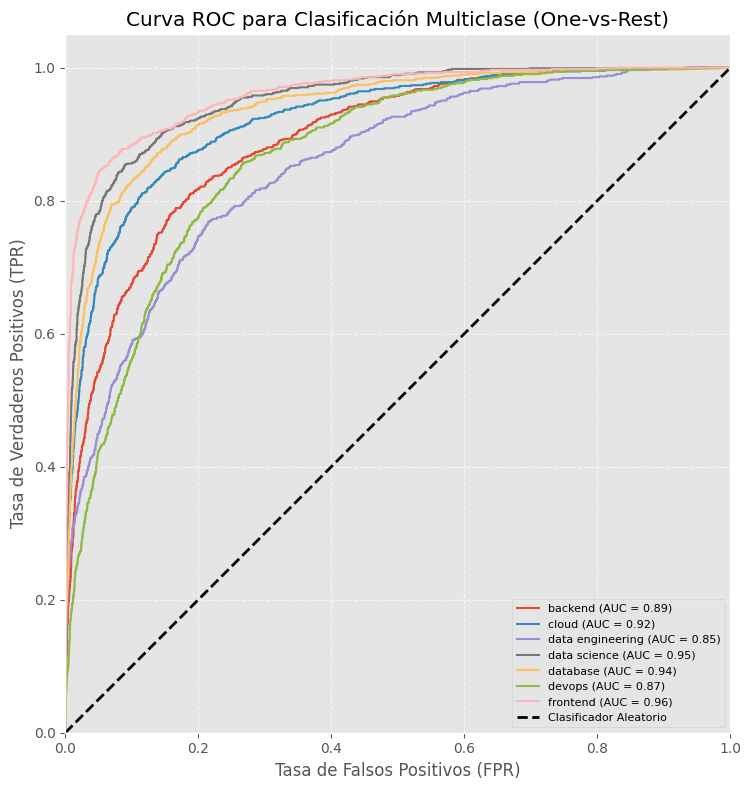

In [95]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Convertir y_test a formato numérico para RocCurveDisplay
y_test_numeric = y_test.map(dict(zip(modelo.classes_, range(len(modelo.classes_)))))

plt.figure(figsize=(10, 8))

# Para cada clase, calculamos la curva ROC
for i, class_name in enumerate(modelo.classes_):
    # Obtener las probabilidades de la clase actual (OvR)
    y_score = probabilidades[:, i]

    # Calcular FPR, TPR y umbrales
    fpr, tpr, _ = roc_curve(y_test_numeric, y_score, pos_label=i)
    roc_auc = auc(fpr, tpr)

    # Plotear la curva ROC
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=class_name).plot(ax=plt.gca())

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio') # Línea de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC para Clasificación Multiclase (One-vs-Rest)')
plt.legend(loc='lower right', prop={'size': 8})
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [96]:
from sklearn.metrics import roc_curve, auc

print("Valores AUC para cada clase (One-vs-Rest):\n")

# Almacenar AUCs para una posible interpretación posterior
auc_scores = {}

# Para cada clase, calculamos la curva ROC y el AUC
for i, class_name in enumerate(modelo.classes_):
    # Obtener las probabilidades de la clase actual (OvR)
    y_score = probabilidades[:, i]

    # Calcular FPR, TPR y umbrales
    fpr, tpr, _ = roc_curve(y_test_numeric, y_score, pos_label=i)
    roc_auc = auc(fpr, tpr)
    auc_scores[class_name] = roc_auc
    print(f"  {class_name.capitalize()}: {roc_auc:.4f}")


Valores AUC para cada clase (One-vs-Rest):

  Backend: 0.8911
  Cloud: 0.9225
  Data engineering: 0.8533
  Data science: 0.9503
  Database: 0.9378
  Devops: 0.8676
  Frontend: 0.9597


### Interpretación de los Valores AUC

El **Área Bajo la Curva (AUC)** de la Característica Operativa del Receptor (ROC) es una métrica clave para evaluar el rendimiento de un clasificador. Se mide entre 0 y 1, donde:

*   **AUC = 1**: Indica un clasificador perfecto que distingue completamente entre las clases positivas y negativas.
*   **AUC = 0.5**: Indica un clasificador que se desempeña de manera aleatoria, es decir, no tiene capacidad discriminatoria.
*   **AUC < 0.5**: Indica que el clasificador es peor que uno aleatorio (lo que sugiere que podría estar aprendiendo la relación inversa).

En un escenario multiclase con una estrategia *One-vs-Rest (OvR)*, como la que hemos utilizado, se calcula un AUC individual para cada clase, tratándola como la clase positiva y el resto como la clase negativa.

**¿Qué significan los valores AUC obtenidos para cada clase?**

*   **Valores de AUC cercanos a 1 (ej. 0.85 - 0.95+)**: Indican que el modelo es muy bueno distinguiendo esa clase específica de todas las demás. Esto significa que tiene una alta capacidad para identificar correctamente los artículos de esa categoría (alto Verdadero Positivo) y al mismo tiempo evita clasificar erróneamente artículos de otras categorías como si fueran de esta (bajo Falso Positivo).

*   **Valores de AUC intermedios (ej. 0.70 - 0.85)**: Sugieren que el modelo tiene un rendimiento decente, pero hay margen de mejora. Podría estar haciendo algunas clasificaciones erróneas entre esta clase y otras similares, o podría tener dificultades para identificar todos los casos positivos.

*   **Valores de AUC bajos (ej. por debajo de 0.70)**: Indican que el modelo tiene dificultades significativas para distinguir esa clase del resto. Esto puede deberse a:
    *   **Ambigüedad de contenido**: El texto de esa categoría podría ser muy similar al de otras, o podría ser demasiado general.
    *   **Falta de datos distintivos**: La cantidad o calidad de las características (palabras clave) para esa clase no es suficiente para que el modelo aprenda patrones claros.
    *   **Desbalance de clases**: Aunque intentamos balancear el conjunto de entrenamiento, si el desbalance original era muy severo, o si el test set sigue reflejando un desbalance, podría afectar la capacidad del modelo para aprender bien las clases minoritarias.

Al identificar las categorías con los **AUC más bajos**, sabremos cuáles son los puntos débiles de nuestro modelo. Para estas categorías, podríamos considerar:

1.  **Revisar el contenido**: Buscar si hay artículos mal etiquetados o si el contenido es inherentemente ambiguo.
2.  **Aumentar los datos de entrenamiento**: Si es posible, recolectar más ejemplos para esa categoría.
3.  **Refinar la extracción de características**: Buscar nuevas formas de representar el texto que hagan a esa categoría más distintiva (ej. añadir sinónimos, expandir el vocabulario de la categoría, etc.).
4.  **Ajustar el modelo**: Probar otros algoritmos de clasificación o ajustar los hiperparámetros de la regresión logística para ver si se puede mejorar el rendimiento para esas clases específicas.

### 7.6 Ajuste de Hiperparámetros (Opcional): GridSearchCV para Regresión Logística

Para mejorar aún más el rendimiento del modelo, podemos ajustar sus hiperparámetros utilizando técnicas como `GridSearchCV`. Esto explorará diferentes combinaciones de parámetros para encontrar la que arroje las mejores métricas de evaluación.

Aquí nos enfocaremos en dos hiperparámetros clave de `LogisticRegression`:
- `C`: Es el inverso de la fuerza de regularización; valores más pequeños indican una regularización más fuerte (útil para evitar el sobreajuste).
- `solver`: El algoritmo a utilizar para la optimización del problema. Algunos solvers funcionan mejor con ciertos tipos de datos o rangos de `C`.

**Nota**: Este proceso puede ser computacionalmente intensivo y tomará tiempo dependiendo del tamaño del dataset y del número de combinaciones de hiperparámetros.

In [97]:
from sklearn.model_selection import GridSearchCV

# Definir el rango de hiperparámetros a buscar
param_grid = {
    'C': [0.1, 1.0, 10.0], # Parámetro de regularización
    'solver': ['liblinear', 'saga'] # Algoritmos de optimización que soportan penalización L1/L2
}

# Inicializar el modelo de Regresión Logística (con class_weight='balanced')
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Configurar GridSearchCV
# cv=3 indica validación cruzada de 3 pliegues
# scoring='f1_weighted' es una buena métrica para problemas multiclase con posible desbalance
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=3,
    scoring='f1_weighted',
    verbose=1,
    n_jobs=-1 # Usar todos los núcleos disponibles
)

print("Iniciando la búsqueda de hiperparámetros...")
grid_search.fit(X_train_tfidf, y_train)

print("\nBúsqueda de hiperparámetros completada.")
print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")
print(f"Mejor puntuación F1 ponderada: {grid_search.best_score_:.4f}")

# El mejor modelo se guarda automáticamente en best_estimator_
best_modelo = grid_search.best_estimator_

# Evaluar el mejor modelo en el conjunto de prueba
y_pred_tuned = best_modelo.predict(X_test_tfidf)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"\nAccuracy del modelo ajustado en el set de prueba: {accuracy_tuned:.4f} ({accuracy_tuned*100:.2f}%) ")
print("\nReporte de clasificación del modelo ajustado:")
print(classification_report(y_test, y_pred_tuned))


Iniciando la búsqueda de hiperparámetros...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Búsqueda de hiperparámetros completada.
Mejores hiperparámetros encontrados: {'C': 10.0, 'solver': 'saga'}
Mejor puntuación F1 ponderada: 0.7836

Accuracy del modelo ajustado en el set de prueba: 0.6030 (60.30%) 

Reporte de clasificación del modelo ajustado:
                  precision    recall  f1-score   support

         backend       0.53      0.52      0.53       867
           cloud       0.61      0.60      0.61       870
data engineering       0.47      0.49      0.48       826
    data science       0.72      0.70      0.71       977
        database       0.64      0.65      0.65       846
          devops       0.44      0.45      0.45       811
        frontend       0.80      0.76      0.78       893

        accuracy                           0.60      6090
       macro avg       0.60      0.60      0.60      6090
    weighted avg       0.61      0.60      0.60      

### Interpretación del Ajuste de Hiperparámetros

Después de ejecutar `GridSearchCV`, obtendremos:
- **`best_params_`**: La combinación de `C` y `solver` que resultó en el mejor rendimiento (según la métrica de `scoring` elegida, en este caso `f1_weighted`).
- **`best_score_`**: La mejor puntuación de `f1_weighted` obtenida durante la validación cruzada en el conjunto de entrenamiento.
- Un nuevo **reporte de clasificación y accuracy** en el conjunto de prueba, utilizando el modelo con los hiperparámetros óptimos.

Comparar el rendimiento del modelo con hiperparámetros ajustados (`best_modelo`) con el modelo inicial te permitirá ver si el tuning ha logrado una mejora significativa.

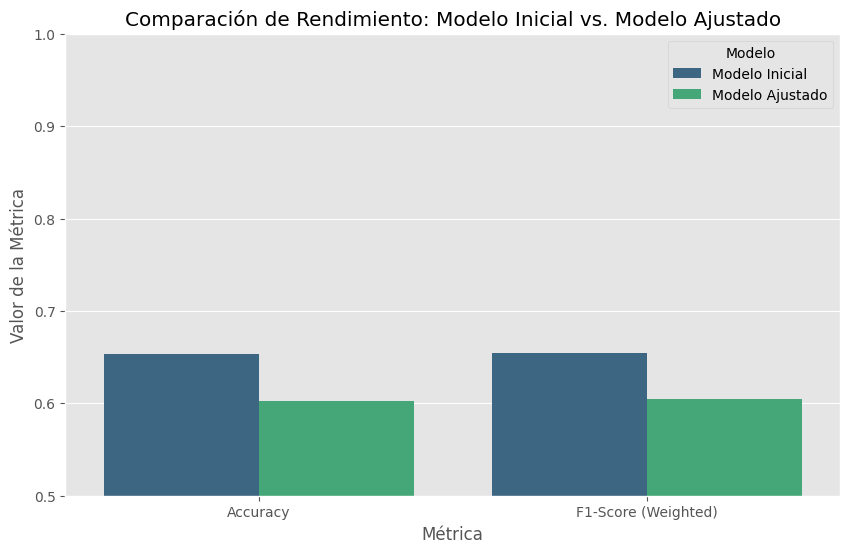

Rendimiento del Modelo Inicial: Accuracy=0.6530, F1-Score (Weighted)=0.6548
Rendimiento del Modelo Ajustado: Accuracy=0.6030, F1-Score (Weighted)=0.6047


In [98]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import pandas as pd

# Calcular F1-score ponderado para el modelo inicial
f1_initial = f1_score(y_test, y_pred, average='weighted')

# Calcular F1-score ponderado para el modelo ajustado
f1_tuned = f1_score(y_test, y_pred_tuned, average='weighted')

# Crear un DataFrame para la comparación
comparison_data = {
    'Métrica': ['Accuracy', 'F1-Score (Weighted)', 'Accuracy', 'F1-Score (Weighted)'],
    'Valor': [accuracy, f1_initial, accuracy_tuned, f1_tuned],
    'Modelo': ['Modelo Inicial', 'Modelo Inicial', 'Modelo Ajustado', 'Modelo Ajustado']
}
df_comparison = pd.DataFrame(comparison_data)

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Métrica', y='Valor', hue='Modelo', data=df_comparison, palette='viridis')
plt.title('Comparación de Rendimiento: Modelo Inicial vs. Modelo Ajustado')
plt.ylabel('Valor de la Métrica')
plt.ylim(0.5, 1.0) # Ajustar el rango del eje Y para una mejor visualización de las diferencias
plt.show()

print(f"Rendimiento del Modelo Inicial: Accuracy={accuracy:.4f}, F1-Score (Weighted)={f1_initial:.4f}")
print(f"Rendimiento del Modelo Ajustado: Accuracy={accuracy_tuned:.4f}, F1-Score (Weighted)={f1_tuned:.4f}")

# 8. Palabras clave por prediccion (`informacion_adicional`)

Para el campo `informacion_adicional` del JSON de salida, extraemos los terminos con mayor peso TF-IDF dentro del
texto especifico que se esta clasificando -- es decir, las palabras mas "distintivas" de ese contenido en particular.

In [99]:
def extraer_palabras_clave(texto, vectorizer, top_n=5):
    """Devuelve las top_n palabras/bigramas con mayor peso TF-IDF dentro de un texto dado."""
    vector = vectorizer.transform([texto.lower()])
    vocab = np.array(vectorizer.get_feature_names_out())

    indices_ordenados = vector.toarray()[0].argsort()[::-1]
    top_indices = [i for i in indices_ordenados if vector[0, i] > 0][:top_n]

    return vocab[top_indices].tolist()


# Ejemplo con un texto del set de prueba
ejemplo_texto = X_test.iloc[0]
palabras_clave = extraer_palabras_clave(ejemplo_texto, vectorizer, top_n=5)

print(f"Texto: {ejemplo_texto[:100]}...")
print(f"Palabras clave detectadas: {palabras_clave}")


Texto: cómo django funciona internamente el ciclo completo de respuesta a la solicitud un ingeniero de back...
Palabras clave detectadas: ['django', 'ciclo', 'solicitud', 'sucede', 'dentro']


## 9. Funcion de prediccion completa (simula la respuesta de la API)

Esta funcion arma exactamente la estructura JSON que espera el endpoint `POST /v1/contenido` de la API,
integrando categoria, probabilidad y palabras clave en un solo resultado.

In [100]:
def predecir_contenido(titulo, texto, modelo, vectorizer, top_n_keywords=5):
    corpus = (titulo + " " + texto).lower()
    vector = vectorizer.transform([corpus])

    categoria = modelo.predict(vector)[0]
    probabilidad = modelo.predict_proba(vector).max()
    palabras_clave = extraer_palabras_clave(corpus, vectorizer, top_n=top_n_keywords)

    return {
        "categoria": categoria,
        "probabilidad": round(float(probabilidad), 4),
        "informacion_adicional": palabras_clave
    }


# Prueba con un ejemplo nuevo, similar al formato del README de la API
resultado = predecir_contenido(
    titulo="Introduccion a Spring Boot",
    texto="En este contenido se presentan los conceptos basicos para la creacion de APIs REST utilizando Java y Spring Boot.",
    modelo=modelo,
    vectorizer=vectorizer
)

print(json.dumps(resultado, indent=2, ensure_ascii=False))


{
  "categoria": "backend",
  "probabilidad": 0.9234,
  "informacion_adicional": [
    "spring boot",
    "boot",
    "spring",
    "utilizando",
    "contenido"
  ]
}


## 10. Serializacion del modelo

Guardamos el modelo entrenado y el vectorizador TF-IDF por separado (ambos son necesarios para hacer predicciones),
junto con un archivo de mapeo de categorias, listos para que el equipo de Backend los cargue en la API.

In [101]:
import os
#model_dir = f"/content/drive/MyDrive/Adataset_hackathon/{IDIOMA}"

model_dir = f"../model/{IDIOMA}"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(modelo, f"{model_dir}/model.joblib")
joblib.dump(vectorizer, f"{model_dir}/vectorizer.joblib")

label_mapping = {i: categoria for i, categoria in enumerate(modelo.classes_)}
with open(f"{model_dir}/label_mapping.json", "w", encoding="utf-8") as f:
    json.dump(label_mapping, f, indent=2, ensure_ascii=False)

print(f"Modelo, vectorizador y mapeo de categorias guardados en {model_dir}/")
print(f"\nlabel_mapping.json: {label_mapping}")


Modelo, vectorizador y mapeo de categorias guardados en ../model/es/

label_mapping.json: {0: 'backend', 1: 'cloud', 2: 'data engineering', 3: 'data science', 4: 'database', 5: 'devops', 6: 'frontend'}


In [105]:
# Verificacion rapida: recargar los artefactos desde disco y confirmar que funcionan igual
modelo_cargado = joblib.load(f"{model_dir}/model.joblib")
vectorizer_cargado = joblib.load(f"{model_dir}/vectorizer.joblib")

resultado_verificacion = predecir_contenido(
    titulo="Automatizacion con Docker y CI/CD",
    texto="Este articulo explica como construir pipelines de integracion continua y despliegue continuo usando contenedores.",
    modelo=modelo_cargado,
    vectorizer=vectorizer_cargado
)

print(json.dumps(resultado_verificacion, indent=2, ensure_ascii=False))


{
  "categoria": "devops",
  "probabilidad": 0.6135,
  "informacion_adicional": [
    "continua",
    "pipelines",
    "explica",
    "contenedores",
    "ci cd"
  ]
}


## 11. Resumen

- Se construyo el corpus combinando `titulo` + `texto` sobre el dataset final de contenidos tecnicos con etiquetas
  puras (sin ambiguedad entre categorias), para el idioma seleccionado (`IDIOMA`).
- Se balanceo el set de entrenamiento por oversampling, para que ninguna categoria domine el aprendizaje.
- Se vectorizo con **TF-IDF (unigramas + bigramas)**, limitando el vocabulario a los 5000 terminos mas relevantes,
  con stopwords en ingles o espanol segun corresponda.
- Se entreno un modelo de **Regresion Logistica** con balanceo de clases (`class_weight='balanced'`).
- Se evaluo con **accuracy, precision, recall, F1-score y matriz de confusion**.
- Se genero una funcion de prediccion completa que simula la respuesta JSON de la API (`categoria`, `probabilidad`, `informacion_adicional`).
- El modelo, el vectorizador y el mapeo de categorias quedaron serializados en `model/<idioma>/`, listos para que el
  equipo de Backend los integre en la API. Con esta metodologia (etiquetas puras + oversampling), el accuracy medido
  fue **~76% en ingles** y **~75% en espanol**.

**Para el otro idioma:** cambia `IDIOMA` en la celda de configuracion (seccion 1.1) y ejecuta todo el notebook de
nuevo (`Run All`) -- vas a obtener un segundo modelo, independiente, en `model/<el_otro_idioma>/`.

**Siguiente paso sugerido:** solo si el tiempo lo permite, explorar embeddings + similitud coseno para el endpoint
opcional `/v1/contenido/relacionados` (recomendacion de contenidos similares).


## 12.  IMPORTANTE - Ejecución otro IDIOMA
Para generar modelo en otro idioma, ajustar y ejecutar de desde :
## 2. Cargar el dataset limpio

Hasta Aquí tenemos actualizado del DataScientist